# Chapter 9: Unsupervised Learning Techniques - Part 1

## Overview of Unsupervised Learning

Welcome to Chapter 9! In this notebook, we'll explore **unsupervised learning**, one of the most important areas of machine learning.

### What is Unsupervised Learning?

Unlike supervised learning (where we have labeled data with both features X and labels y), **unsupervised learning works with unlabeled data** - we only have input features X without any labels y.

### Yann LeCun's Cake Analogy

According to Yann LeCun, Director of AI Research at Meta:

> "If intelligence was a cake, unsupervised learning would be the cake, supervised learning would be the icing, and reinforcement learning would be the cherry."

This emphasizes that unsupervised learning is the foundation of intelligence - most of what we learn about the world comes from observing it without explicit labels!

### Three Main Unsupervised Learning Tasks

This chapter covers three fundamental tasks:

1. **Clustering** - Grouping similar instances together into clusters
2. **Anomaly Detection** - Identifying unusual or abnormal instances
3. **Density Estimation** - Estimating the probability density function of the data

Let's dive in!

## Introduction to Clustering

### What is Clustering?

**Clustering** is the task of identifying similar instances and grouping them into **clusters** - groups of similar instances.

**Key Difference from Classification:**
- **Classification** (supervised): We have labeled training data with known categories
- **Clustering** (unsupervised): No labels are provided during training - the algorithm discovers patterns on its own

### Applications of Clustering

Clustering has many practical applications across different domains:

1. **Customer Segmentation** 
   - Group customers by purchasing behavior or demographics
   - Enable targeted marketing campaigns for each segment

2. **Data Analysis** 
   - Analyze each cluster separately to gain insights
   - Understand different patterns within your data

3. **Dimensionality Reduction** 
   - Replace original features with cluster affinity scores
   - Reduce feature space while preserving important patterns

4. **Anomaly Detection** 
   - Instances with low affinity to all clusters are potential anomalies
   - Useful for fraud detection, equipment failure prediction

5. **Semi-Supervised Learning** 
   - When labels are scarce, propagate labels within clusters
   - Maximize the utility of limited labeled data

6. **Search Engines** 
   - Find similar images or documents by clustering
   - Improve search relevance and recommendations

7. **Image Segmentation** 
   - Group pixels by color, texture, or other features
   - Separate objects from background in images

Now let's explore the most popular clustering algorithm: **K-Means**!

## K-Means Clustering: Basic Usage

**K-Means** is a simple and fast clustering algorithm that works well for blob-shaped (spherical) datasets.

Let's start with a practical example!

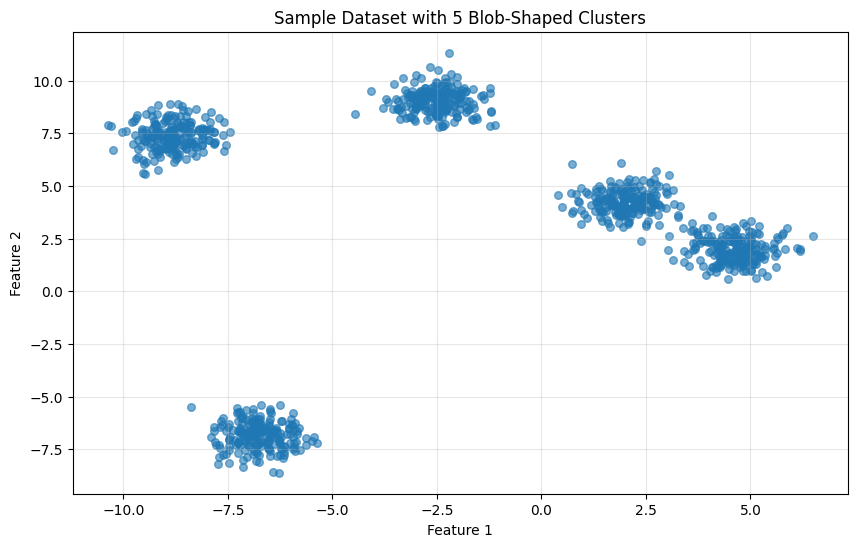

Dataset shape: (1000, 2)
Number of instances: 1000
Number of features: 2


In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Set random seed for reproducibility
np.random.seed(42)

# Generate sample data with 5 blob-shaped clusters
X, y_true = make_blobs(n_samples=1000, centers=5, cluster_std=0.6, random_state=42)

# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, s=30)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Sample Dataset with 5 Blob-Shaped Clusters')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Dataset shape: {X.shape}")
print(f"Number of instances: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

In [2]:
# Create a K-Means model with k=5 clusters
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)

# Fit the model to the data and predict cluster labels
y_pred = kmeans.fit_predict(X)

print(f"K-Means model trained with k={k} clusters")
print(f"\nFirst 20 predicted cluster labels: {y_pred[:20]}")
print(f"\nUnique cluster labels: {np.unique(y_pred)}")

K-Means model trained with k=5 clusters

First 20 predicted cluster labels: [2 2 0 2 4 0 3 4 2 4 4 0 3 0 3 0 1 3 1 4]

Unique cluster labels: [0 1 2 3 4]


In [3]:
# Verify that y_pred is the same as kmeans.labels_
print(f"Are y_pred and kmeans.labels_ the same? {y_pred is kmeans.labels_}")
print(f"Are their values equal? {np.array_equal(y_pred, kmeans.labels_)}")

Are y_pred and kmeans.labels_ the same? True
Are their values equal? True


In [4]:
# View the cluster centroids
print("Cluster Centroids:")
print(kmeans.cluster_centers_)
print(f"\nShape of centroids: {kmeans.cluster_centers_.shape}")
print(f"This means we have {kmeans.cluster_centers_.shape[0]} centroids, each with {kmeans.cluster_centers_.shape[1]} coordinates")

Cluster Centroids:
[[-6.76363502 -6.83888057]
 [-2.52218128  9.03156916]
 [ 4.61020325  1.96500287]
 [-8.82929199  7.37020647]
 [ 2.00893522  4.23781023]]

Shape of centroids: (5, 2)
This means we have 5 centroids, each with 2 coordinates


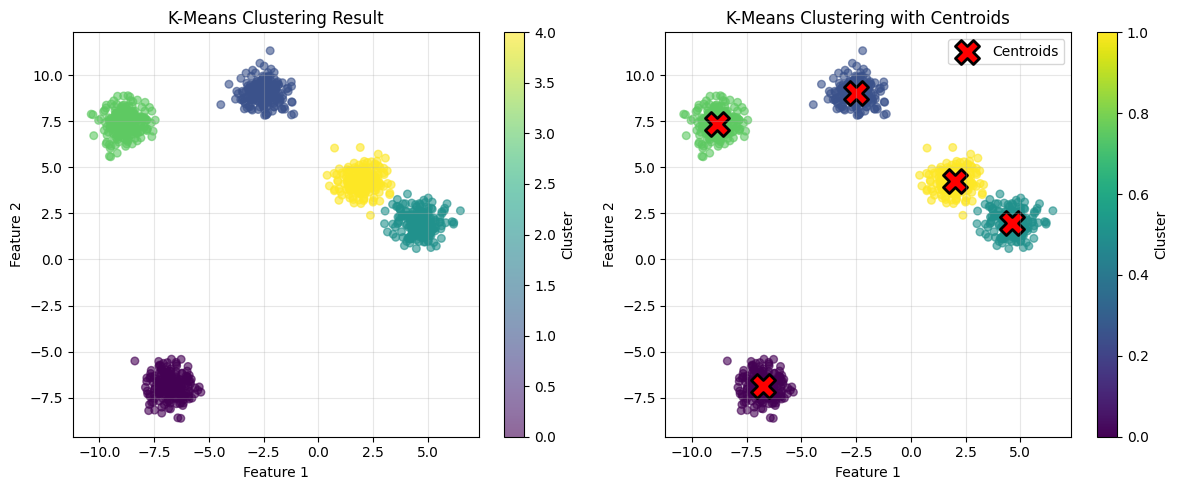

In [5]:
# Visualize the clustering result
plt.figure(figsize=(12, 5))

# Plot 1: Without centroids
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.6, s=30)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering Result')
plt.colorbar(label='Cluster')
plt.grid(True, alpha=0.3)

# Plot 2: With centroids
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.6, s=30)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            marker='X', s=300, c='red', edgecolors='black', linewidths=2, label='Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering with Centroids')
plt.colorbar(label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

New instances:
[[ 0.   2. ]
 [ 3.   2. ]
 [-3.   3. ]
 [-3.   2.5]]

Predicted cluster labels for new instances:
[4 2 4 4]


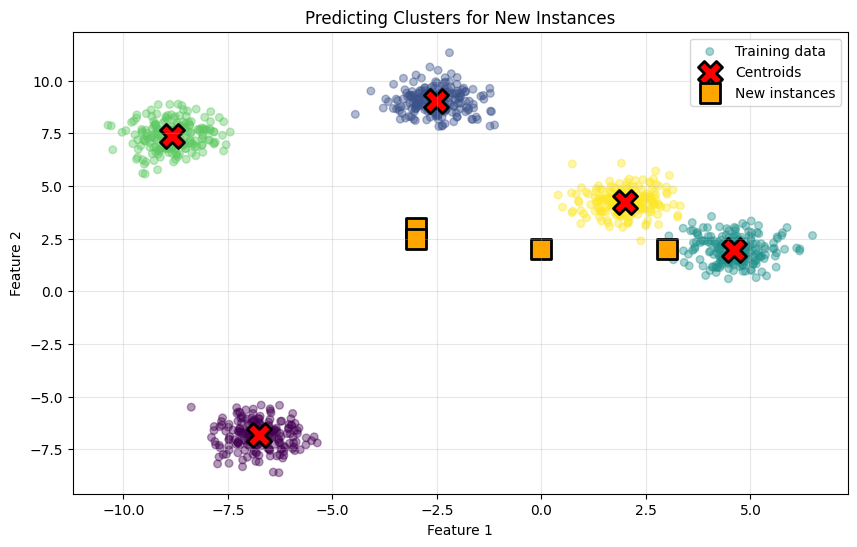

In [6]:
# Predict cluster labels for new instances
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])

print("New instances:")
print(X_new)
print("\nPredicted cluster labels for new instances:")
print(kmeans.predict(X_new))

# Visualize the new instances
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.4, s=30, label='Training data')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            marker='X', s=300, c='red', edgecolors='black', linewidths=2, label='Centroids')
plt.scatter(X_new[:, 0], X_new[:, 1], marker='s', s=200, c='orange', 
            edgecolors='black', linewidths=2, label='New instances')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Predicting Clusters for New Instances')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Hard vs Soft Clustering

There are two ways to assign instances to clusters:

### Hard Clustering
- Each instance is assigned to **exactly one cluster**
- Uses the `predict()` method
- Returns the cluster label (0, 1, 2, etc.)

### Soft Clustering
- Each instance gets a **score for every cluster**
- Uses the `transform()` method
- Returns distances to all centroids
- Lower distance = higher affinity to that cluster

Let's see both in action!

In [7]:
# Hard Clustering: predict() returns cluster labels
print("HARD CLUSTERING (predict method)")
print("=" * 50)
hard_clustering = kmeans.predict(X_new)
print(f"Cluster assignments: {hard_clustering}")
print(f"\nEach instance is assigned to exactly one cluster")

print("\n" + "=" * 50)
print("\nSOFT CLUSTERING (transform method)")
print("=" * 50)
# Soft Clustering: transform() returns distances to all centroids
distances = kmeans.transform(X_new)
print(f"Distances to all centroids:")
print(distances)
print(f"\nShape: {distances.shape} (4 instances × 5 clusters)")

# Show which cluster each instance is closest to
closest_clusters = np.argmin(distances, axis=1)
print(f"\nClosest clusters (argmin of distances): {closest_clusters}")
print(f"This matches hard clustering: {np.array_equal(hard_clustering, closest_clusters)}")

HARD CLUSTERING (predict method)
Cluster assignments: [4 2 4 4]

Each instance is assigned to exactly one cluster


SOFT CLUSTERING (transform method)
Distances to all centroids:
[[11.12980541  7.47023181  4.61033608 10.33419152  3.00726044]
 [13.17020799  8.94077463  1.61058353 12.99119957  2.44744847]
 [10.53415964  6.05046587  7.68026123  7.28555761  5.15961299]
 [10.06874564  6.54902332  7.62898522  7.59602239  5.30183143]]

Shape: (4, 5) (4 instances × 5 clusters)

Closest clusters (argmin of distances): [4 2 4 4]
This matches hard clustering: True


Analyzing instance: [0. 2.]
Assigned to cluster: 4

Distances to each cluster centroid:
  Cluster 0: 11.1298 
  Cluster 1: 7.4702 
  Cluster 2: 4.6103 
  Cluster 3: 10.3342 
  Cluster 4: 3.0073 ← ASSIGNED


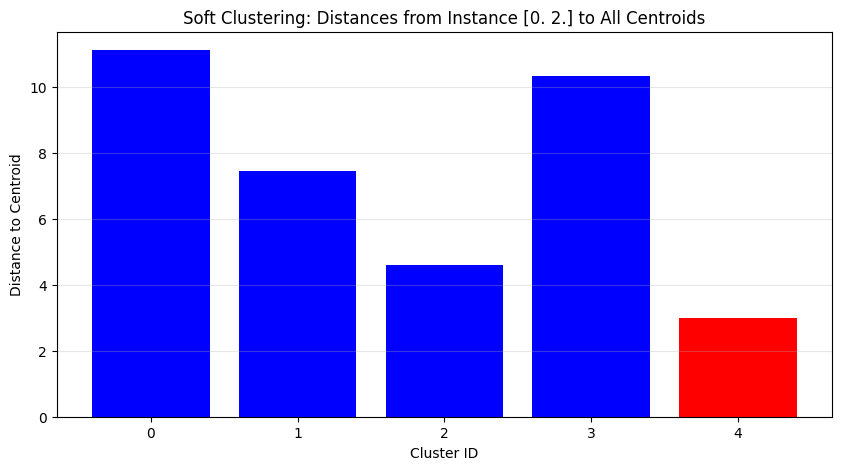

In [8]:
# Visualize soft clustering for the first new instance
instance_idx = 0
print(f"Analyzing instance: {X_new[instance_idx]}")
print(f"Assigned to cluster: {hard_clustering[instance_idx]}")
print(f"\nDistances to each cluster centroid:")

for cluster_id in range(k):
    distance = distances[instance_idx, cluster_id]
    is_assigned = "← ASSIGNED" if cluster_id == hard_clustering[instance_idx] else ""
    print(f"  Cluster {cluster_id}: {distance:.4f} {is_assigned}")

# Visualize as a bar chart
plt.figure(figsize=(10, 5))
plt.bar(range(k), distances[instance_idx], color=['red' if i == hard_clustering[instance_idx] else 'blue' for i in range(k)])
plt.xlabel('Cluster ID')
plt.ylabel('Distance to Centroid')
plt.title(f'Soft Clustering: Distances from Instance {X_new[instance_idx]} to All Centroids')
plt.xticks(range(k))
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## Understanding the K-Means Algorithm

Let's understand how K-Means actually works under the hood!

### The Algorithm Steps:

1. **Initialization**: Randomly place k centroids in the feature space
2. **Label Step**: Assign each instance to the nearest centroid
3. **Update Step**: Compute new centroids as the mean of all instances assigned to each cluster
4. **Repeat**: Continue steps 2-3 until convergence (centroids stop moving)

### Key Properties:

- **Guaranteed Convergence**: The algorithm always converges (centroids stabilize)
- **Local Optima**: May converge to different solutions depending on initialization
- **Complexity**: O(k × m × n) where:
  - k = number of clusters
  - m = number of instances
  - n = number of dimensions/features
  - Linear complexity - very efficient!

Let's visualize the algorithm step by step!

In [9]:
# Create a simple 2-cluster dataset for visualization
np.random.seed(42)
X_simple, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=42)

# Function to manually run K-Means step by step
def kmeans_step_by_step(X, k, max_iter=10):
    """
    Manually implement K-Means to show each iteration
    """
    # Step 1: Randomly initialize centroids
    np.random.seed(42)
    random_indices = np.random.choice(len(X), k, replace=False)
    centroids = X[random_indices].copy()
    
    history = {'centroids': [centroids.copy()], 'labels': []}
    
    for iteration in range(max_iter):
        # Step 2: Label step - assign each point to nearest centroid
        distances = np.sqrt(((X[:, np.newaxis] - centroids) ** 2).sum(axis=2))
        labels = np.argmin(distances, axis=1)
        history['labels'].append(labels.copy())
        
        # Step 3: Update step - compute new centroids
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        
        # Check for convergence
        if np.allclose(centroids, new_centroids):
            print(f"Converged at iteration {iteration + 1}")
            break
            
        centroids = new_centroids
        history['centroids'].append(centroids.copy())
    
    return history

# Run the algorithm
history = kmeans_step_by_step(X_simple, k=3, max_iter=10)
print(f"Total iterations: {len(history['centroids']) - 1}")

Converged at iteration 3
Total iterations: 2


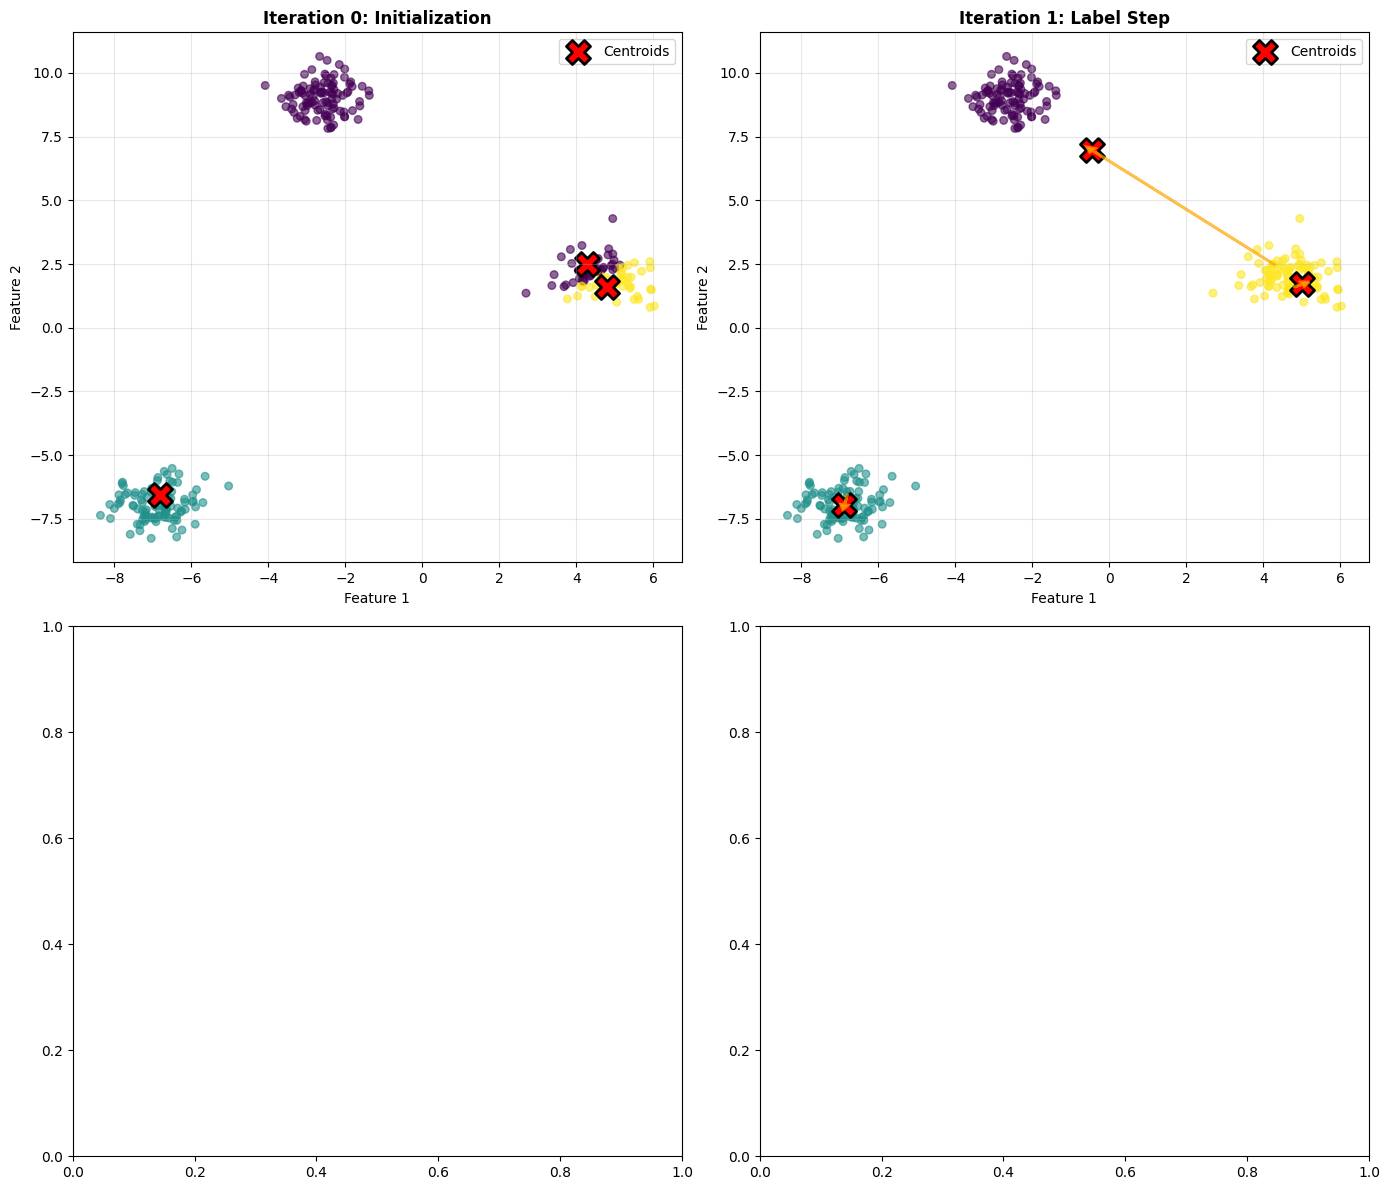


The algorithm iterates between:
1. LABEL STEP: Assign each point to nearest centroid
2. UPDATE STEP: Move centroids to mean of assigned points
3. Repeat until centroids stop moving (convergence)


In [10]:
# Visualize the first few iterations
iterations_to_show = min(4, len(history['centroids']) - 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i in range(iterations_to_show):
    ax = axes[i]
    
    # Plot the data points colored by their current cluster assignment
    if i < len(history['labels']):
        scatter = ax.scatter(X_simple[:, 0], X_simple[:, 1], 
                           c=history['labels'][i], cmap='viridis', 
                           alpha=0.6, s=30)
    else:
        scatter = ax.scatter(X_simple[:, 0], X_simple[:, 1], 
                           alpha=0.6, s=30, color='gray')
    
    # Plot the centroids
    centroids = history['centroids'][i]
    ax.scatter(centroids[:, 0], centroids[:, 1], 
              marker='X', s=300, c='red', edgecolors='black', 
              linewidths=2, label='Centroids')
    
    # Draw lines to show centroid movement if not first iteration
    if i > 0:
        prev_centroids = history['centroids'][i-1]
        for j in range(len(centroids)):
            ax.arrow(prev_centroids[j, 0], prev_centroids[j, 1],
                    centroids[j, 0] - prev_centroids[j, 0],
                    centroids[j, 1] - prev_centroids[j, 1],
                    head_width=0.2, head_length=0.2, fc='orange', 
                    ec='orange', alpha=0.7, linewidth=2)
    
    title = f"Iteration {i}: " + ("Initialization" if i == 0 else 
                                  "Label Step" if i % 2 == 1 else "Update Step")
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nThe algorithm iterates between:")
print("1. LABEL STEP: Assign each point to nearest centroid")
print("2. UPDATE STEP: Move centroids to mean of assigned points")
print("3. Repeat until centroids stop moving (convergence)")

## Centroid Initialization Methods

The initial placement of centroids can significantly affect the final result. Let's explore different initialization strategies!

### K-Means++ (Default Method)

This is the smart initialization method that scikit-learn uses by default:

1. Choose the first centroid uniformly at random from the data points
2. For each subsequent centroid, choose a data point with probability proportional to:
   $$P(x^{(i)}) = \frac{D(x^{(i)})^2}{\sum_{j} D(x^{(j)})^2}$$
   where $D(x^{(i)})$ is the distance from $x^{(i)}$ to the nearest already-chosen centroid
3. Repeat until k centroids are selected

**Why it works**: Points far from existing centroids have higher probability of being selected, leading to well-spread initial centroids.

### Alternative Methods:

- **Random initialization**: Pick k random data points as initial centroids
- **Custom initialization**: Provide your own initial centroid positions

In [11]:
# Example 1: Custom initialization with good starting centroids
good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])

kmeans_custom = KMeans(n_clusters=5, init=good_init, n_init=1, random_state=42)
y_pred_custom = kmeans_custom.fit_predict(X)

print("Custom Initialization")
print("=" * 50)
print(f"Initial centroids:\n{good_init}")
print(f"\nFinal centroids:\n{kmeans_custom.cluster_centers_}")
print(f"Inertia: {kmeans_custom.inertia_:.2f}")

Custom Initialization
Initial centroids:
[[-3  3]
 [-3  2]
 [-3  1]
 [-1  2]
 [ 0  2]]

Final centroids:
[[-5.67573663  8.20088781]
 [-7.37319615 -7.23395797]
 [-6.77784363 -6.33892988]
 [-6.3038123  -7.36399539]
 [ 3.31607241  3.09572453]]
Inertia: 6069.54


In [12]:
# Example 2: Force original random initialization (not recommended)
kmeans_random = KMeans(n_clusters=5, init="random", n_init=1, random_state=42)
y_pred_random = kmeans_random.fit_predict(X)

print("\nRandom Initialization (single run)")
print("=" * 50)
print(f"Final centroids:\n{kmeans_random.cluster_centers_}")
print(f"Inertia: {kmeans_random.inertia_:.2f}")

# Example 3: K-Means++ (default and recommended)
kmeans_plusplus = KMeans(n_clusters=5, init="k-means++", n_init=1, random_state=42)
y_pred_plusplus = kmeans_plusplus.fit_predict(X)

print("\nK-Means++ Initialization (default, single run)")
print("=" * 50)
print(f"Final centroids:\n{kmeans_plusplus.cluster_centers_}")
print(f"Inertia: {kmeans_plusplus.inertia_:.2f}")

print("\n" + "=" * 50)
print("K-Means++ typically gives better results than random initialization!")


Random Initialization (single run)
Final centroids:
[[-6.76612585 -6.41814449]
 [-6.75997565 -7.456999  ]
 [ 4.61020325  1.96500287]
 [-5.67573663  8.20088781]
 [ 2.00893522  4.23781023]]
Inertia: 4900.65

K-Means++ Initialization (default, single run)
Final centroids:
[[-6.76363502 -6.83888057]
 [-2.52218128  9.03156916]
 [ 4.61020325  1.96500287]
 [-8.82929199  7.37020647]
 [ 2.00893522  4.23781023]]
Inertia: 698.77

K-Means++ typically gives better results than random initialization!


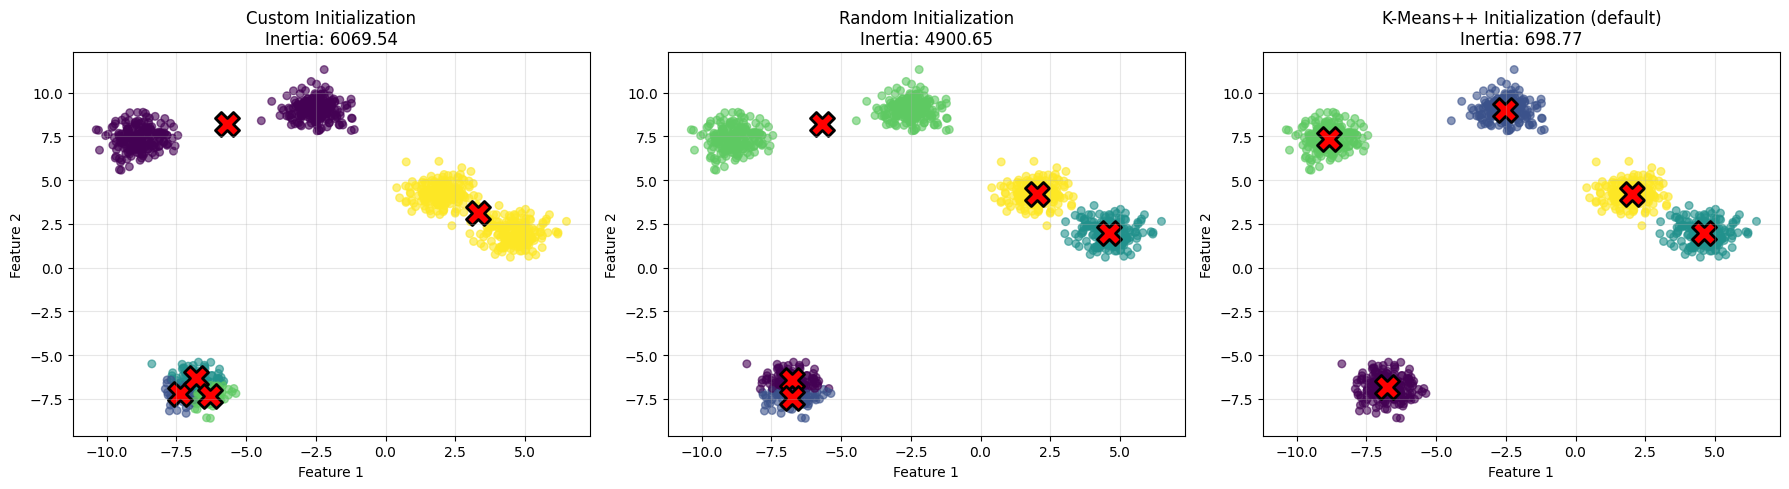

In [13]:
# Visualize the impact of different initializations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Custom initialization
axes[0].scatter(X[:, 0], X[:, 1], c=y_pred_custom, cmap='viridis', alpha=0.6, s=30)
axes[0].scatter(kmeans_custom.cluster_centers_[:, 0], kmeans_custom.cluster_centers_[:, 1],
               marker='X', s=300, c='red', edgecolors='black', linewidths=2)
axes[0].set_title(f'Custom Initialization\nInertia: {kmeans_custom.inertia_:.2f}')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].grid(True, alpha=0.3)

# Random initialization
axes[1].scatter(X[:, 0], X[:, 1], c=y_pred_random, cmap='viridis', alpha=0.6, s=30)
axes[1].scatter(kmeans_random.cluster_centers_[:, 0], kmeans_random.cluster_centers_[:, 1],
               marker='X', s=300, c='red', edgecolors='black', linewidths=2)
axes[1].set_title(f'Random Initialization\nInertia: {kmeans_random.inertia_:.2f}')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].grid(True, alpha=0.3)

# K-Means++ initialization
axes[2].scatter(X[:, 0], X[:, 1], c=y_pred_plusplus, cmap='viridis', alpha=0.6, s=30)
axes[2].scatter(kmeans_plusplus.cluster_centers_[:, 0], kmeans_plusplus.cluster_centers_[:, 1],
               marker='X', s=300, c='red', edgecolors='black', linewidths=2)
axes[2].set_title(f'K-Means++ Initialization (default)\nInertia: {kmeans_plusplus.inertia_:.2f}')
axes[2].set_xlabel('Feature 1')
axes[2].set_ylabel('Feature 2')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluating K-Means Performance with Inertia

### What is Inertia?

**Inertia** (also called within-cluster sum of squares) measures how well the clustering fits the data:

$$\text{Inertia} = \sum_{i=1}^{m} \min_{\mu_j \in C} ||x^{(i)} - \mu_j||^2$$

In plain English: **the mean squared distance between each instance and its closest centroid**

- **Lower inertia = better fit** (instances are closer to their centroids)
- Inertia will always decrease as k increases
- Inertia = 0 when k = m (each instance is its own cluster)

### Using n_init for Multiple Runs

Because K-Means can converge to local optima, scikit-learn runs the algorithm **multiple times** and keeps the best result:

- `n_init` parameter controls the number of runs (default = 10)
- The model with the **lowest inertia** is selected

In [14]:
# Access inertia from a trained model
print("Inertia Measurement")
print("=" * 50)
print(f"Inertia (via .inertia_): {kmeans.inertia_:.2f}")
print(f"Score (via .score()): {kmeans.score(X):.2f}")
print(f"\nNote: score() returns NEGATIVE inertia (higher is better)")
print(f"Verify: -inertia = {-kmeans.inertia_:.2f}")

Inertia Measurement
Inertia (via .inertia_): 698.77
Score (via .score()): -698.77

Note: score() returns NEGATIVE inertia (higher is better)
Verify: -inertia = -698.77



Impact of n_init (number of runs)
Single run (n_init=1):
  Mean inertia: 698.77
  Std inertia: 0.00
  Min inertia: 698.77
  Max inertia: 698.77

Multiple runs (n_init=10):
  Mean inertia: 698.77
  Std inertia: 0.00
  Min inertia: 698.77
  Max inertia: 698.77

✓ Multiple runs (n_init=10) give more consistent, better results!


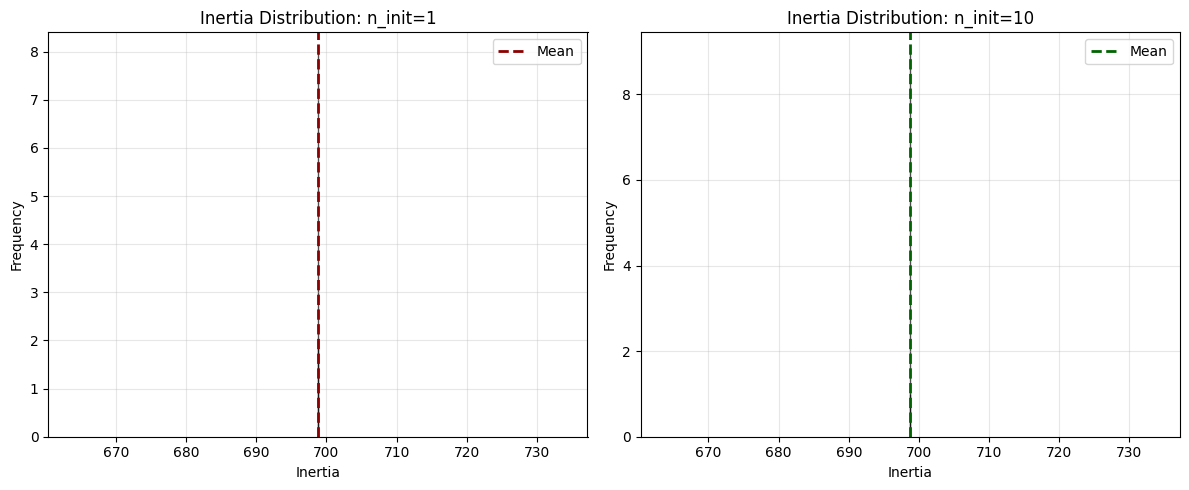

In [15]:
# Demonstrate the impact of n_init
print("\nImpact of n_init (number of runs)")
print("=" * 50)

inertias_single_run = []
inertias_multi_run = []

# Run with n_init=1 (single run) multiple times
for seed in range(10):
    km = KMeans(n_clusters=5, n_init=1, random_state=seed)
    km.fit(X)
    inertias_single_run.append(km.inertia_)

# Run with n_init=10 (multiple runs, keep best)
for seed in range(10):
    km = KMeans(n_clusters=5, n_init=10, random_state=seed)
    km.fit(X)
    inertias_multi_run.append(km.inertia_)

print(f"Single run (n_init=1):")
print(f"  Mean inertia: {np.mean(inertias_single_run):.2f}")
print(f"  Std inertia: {np.std(inertias_single_run):.2f}")
print(f"  Min inertia: {np.min(inertias_single_run):.2f}")
print(f"  Max inertia: {np.max(inertias_single_run):.2f}")

print(f"\nMultiple runs (n_init=10):")
print(f"  Mean inertia: {np.mean(inertias_multi_run):.2f}")
print(f"  Std inertia: {np.std(inertias_multi_run):.2f}")
print(f"  Min inertia: {np.min(inertias_multi_run):.2f}")
print(f"  Max inertia: {np.max(inertias_multi_run):.2f}")

print(f"\n✓ Multiple runs (n_init=10) give more consistent, better results!")

# Visualize the comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(inertias_single_run, bins=10, alpha=0.7, color='red', edgecolor='black')
plt.xlabel('Inertia')
plt.ylabel('Frequency')
plt.title('Inertia Distribution: n_init=1')
plt.axvline(np.mean(inertias_single_run), color='darkred', linestyle='--', linewidth=2, label='Mean')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(inertias_multi_run, bins=10, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Inertia')
plt.ylabel('Frequency')
plt.title('Inertia Distribution: n_init=10')
plt.axvline(np.mean(inertias_multi_run), color='darkgreen', linestyle='--', linewidth=2, label='Mean')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Mini-Batch K-Means for Large Datasets

When working with very large datasets, standard K-Means can be slow. **MiniBatchKMeans** offers a faster alternative!

### How it Works:

Instead of using the entire dataset in each iteration:
1. Sample a mini-batch of instances
2. Assign instances in the mini-batch to centroids
3. Update centroids based only on the mini-batch
4. Repeat until convergence

### Trade-offs:

**Advantages:**
- 3-4× faster than standard K-Means
- Lower memory requirements
- Can handle datasets that don't fit in memory

**Disadvantages:**
- Slightly higher inertia (worse fit)
- The gap increases as k increases
- More sensitive to the choice of mini-batch size

Let's compare both methods!

In [16]:
from sklearn.cluster import MiniBatchKMeans
import time

# Create a larger dataset for comparison
X_large, _ = make_blobs(n_samples=10000, centers=5, cluster_std=0.8, random_state=42)

print(f"Dataset size: {X_large.shape}")
print("=" * 70)

Dataset size: (10000, 2)


In [17]:
# Standard K-Means
print("Standard K-Means:")
start = time.time()
kmeans_standard = KMeans(n_clusters=5, random_state=42)
kmeans_standard.fit(X_large)
time_standard = time.time() - start

print(f"  Time: {time_standard:.4f} seconds")
print(f"  Inertia: {kmeans_standard.inertia_:.2f}")
print(f"  Iterations: {kmeans_standard.n_iter_}")

print("\n" + "=" * 70)

# Mini-Batch K-Means
print("Mini-Batch K-Means:")
start = time.time()
minibatch_kmeans = MiniBatchKMeans(n_clusters=5, random_state=42)
minibatch_kmeans.fit(X_large)
time_minibatch = time.time() - start

print(f"  Time: {time_minibatch:.4f} seconds")
print(f"  Inertia: {minibatch_kmeans.inertia_:.2f}")
print(f"  Iterations: {minibatch_kmeans.n_iter_}")

print("\n" + "=" * 70)
print(f"Speedup: {time_standard / time_minibatch:.2f}x faster")
print(f"Inertia difference: {((minibatch_kmeans.inertia_ - kmeans_standard.inertia_) / kmeans_standard.inertia_ * 100):.2f}%")
print("\n✓ Mini-Batch K-Means is much faster with only slightly higher inertia!")

Standard K-Means:
  Time: 0.0091 seconds
  Inertia: 12683.69
  Iterations: 3

Mini-Batch K-Means:
  Time: 0.0076 seconds
  Inertia: 23822.79
  Iterations: 2

Speedup: 1.20x faster
Inertia difference: 87.82%

✓ Mini-Batch K-Means is much faster with only slightly higher inertia!


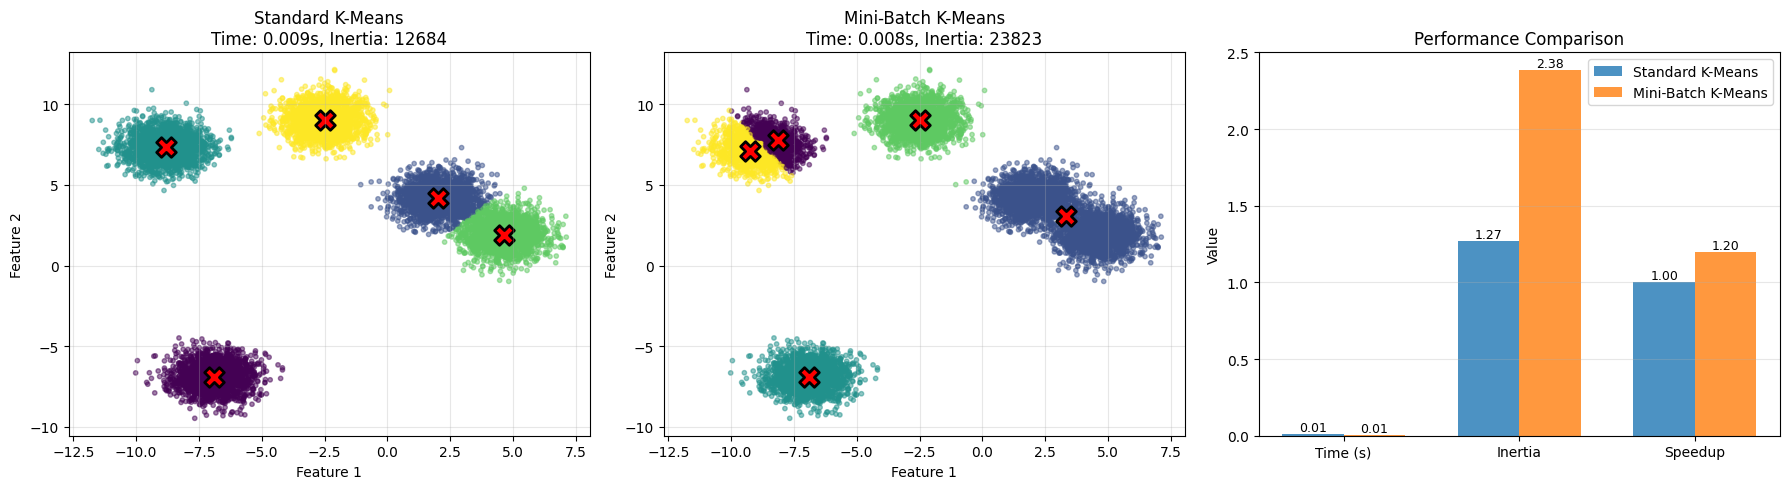

In [18]:
# Visualize the comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Standard K-Means result
axes[0].scatter(X_large[:, 0], X_large[:, 1], c=kmeans_standard.labels_, 
               cmap='viridis', alpha=0.5, s=10)
axes[0].scatter(kmeans_standard.cluster_centers_[:, 0], 
               kmeans_standard.cluster_centers_[:, 1],
               marker='X', s=200, c='red', edgecolors='black', linewidths=2)
axes[0].set_title(f'Standard K-Means\nTime: {time_standard:.3f}s, Inertia: {kmeans_standard.inertia_:.0f}')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].grid(True, alpha=0.3)

# Mini-Batch K-Means result
axes[1].scatter(X_large[:, 0], X_large[:, 1], c=minibatch_kmeans.labels_, 
               cmap='viridis', alpha=0.5, s=10)
axes[1].scatter(minibatch_kmeans.cluster_centers_[:, 0], 
               minibatch_kmeans.cluster_centers_[:, 1],
               marker='X', s=200, c='red', edgecolors='black', linewidths=2)
axes[1].set_title(f'Mini-Batch K-Means\nTime: {time_minibatch:.3f}s, Inertia: {minibatch_kmeans.inertia_:.0f}')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].grid(True, alpha=0.3)

# Performance comparison
metrics = ['Time (s)', 'Inertia', 'Speedup']
standard_values = [time_standard, kmeans_standard.inertia_ / 10000, 1]
minibatch_values = [time_minibatch, minibatch_kmeans.inertia_ / 10000, time_standard / time_minibatch]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[2].bar(x - width/2, standard_values, width, label='Standard K-Means', alpha=0.8)
bars2 = axes[2].bar(x + width/2, minibatch_values, width, label='Mini-Batch K-Means', alpha=0.8)

axes[2].set_ylabel('Value')
axes[2].set_title('Performance Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(metrics)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Summary: First Part Complete! 🎉

Congratulations! You've completed the first 25% of Chapter 9 on Unsupervised Learning.

### What We Covered:

1. **Overview of Unsupervised Learning**
   - Working with unlabeled data
   - Three main tasks: clustering, anomaly detection, density estimation
   - Yann LeCun's cake analogy

2. **Introduction to Clustering**
   - Grouping similar instances without labels
   - Seven key applications (customer segmentation, data analysis, etc.)

3. **K-Means Clustering - Basic Usage**
   - Creating and fitting KMeans models
   - Accessing cluster labels and centroids
   - Making predictions on new instances

4. **Hard vs Soft Clustering**
   - Hard: `predict()` assigns one cluster
   - Soft: `transform()` returns distances to all centroids

5. **Understanding the K-Means Algorithm**
   - Initialization → Label step → Update step → Repeat
   - Guaranteed convergence but may reach local optima
   - O(kmn) complexity

6. **Centroid Initialization Methods**
   - K-Means++ (smart, default)
   - Random initialization (not recommended)
   - Custom initialization

7. **Evaluating with Inertia**
   - Mean squared distance to centroids
   - Using `n_init` for multiple runs
   - Lower inertia = better fit

8. **Mini-Batch K-Means**
   - 3-4× faster for large datasets
   - Slightly higher inertia
   - Great for big data applications

### Coming Next:

In the next parts, we'll explore:
- Finding the optimal number of clusters (Elbow method, Silhouette score)
- K-Means limitations and when it fails
- Real-world applications (image segmentation, semi-supervised learning)
- Other clustering algorithms (DBSCAN, Gaussian Mixtures)
- Anomaly detection techniques

### Key Takeaways:

✓ **Always use K-Means++ initialization** (it's the default)  
✓ **Set n_init ≥ 10** for consistent results  
✓ **Use MiniBatchKMeans** for large datasets  
✓ **Scale your features** before applying K-Means  
✓ K-Means works best for **blob-shaped (spherical) clusters**

---

# Part 2: Finding Optimal Clusters and K-Means Applications

Now let's explore how to determine the optimal number of clusters and see K-Means in real-world applications!

## Finding the Optimal Number of Clusters

One of the biggest challenges with K-Means is: **How do we choose k?**

We'll explore two popular methods:
1. **Elbow Method** - Look for the "elbow" in the inertia curve
2. **Silhouette Score** - Measure how well instances fit their clusters

### Method 1: The Elbow Method

The Elbow Method plots inertia against different values of k and looks for an "elbow" - a point where adding more clusters doesn't significantly reduce inertia.

**Key Insight:**
- Inertia always decreases as k increases
- When k = m (number of instances), inertia = 0 (each point is its own cluster)
- We want the k where the rate of decrease starts to slow down

Let's visualize this!

In [19]:
# Test different values of k and record inertia
k_range = range(1, 11)
inertias = []

print("Computing inertia for different k values...")
for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans_temp.fit(X)
    inertias.append(kmeans_temp.inertia_)
    print(f"k={k}: inertia={kmeans_temp.inertia_:.2f}")

print("\nDone!")

Computing inertia for different k values...
k=1: inertia=57466.40
k=2: inertia=27529.01
k=3: inertia=6145.94
k=4: inertia=1891.97
k=5: inertia=698.77
k=6: inertia=644.17
k=7: inertia=591.81
k=8: inertia=537.57
k=9: inertia=503.45
k=10: inertia=451.72

Done!


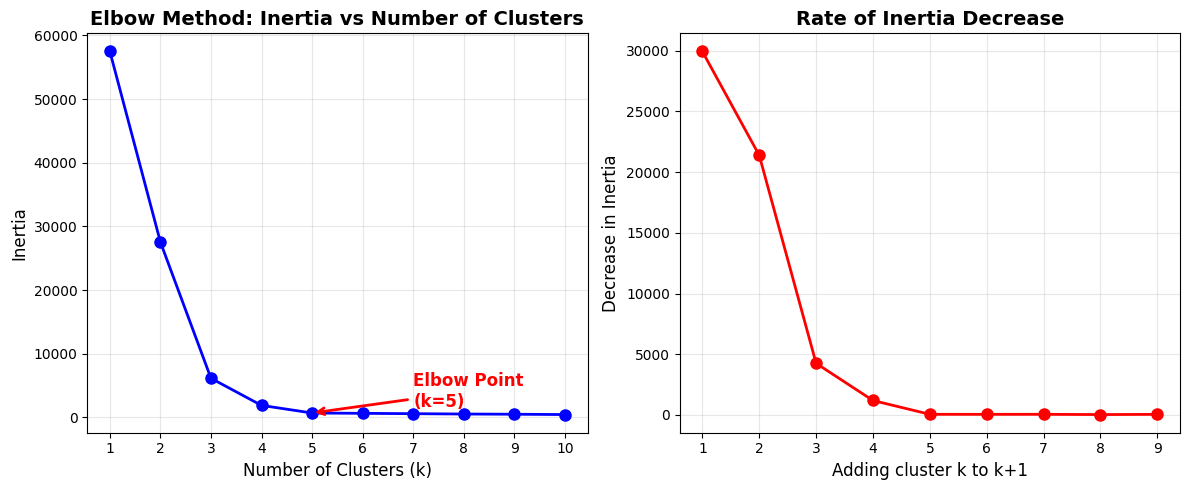


INTERPRETATION:
• The curve shows a clear 'elbow' at k=5
• Before k=5: Inertia drops rapidly (adding clusters helps a lot)
• After k=5: Inertia drops slowly (diminishing returns)
• Conclusion: k=5 is the optimal number of clusters for this dataset


In [20]:
# Plot the elbow curve
plt.figure(figsize=(12, 5))

# Left plot: Basic elbow curve
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method: Inertia vs Number of Clusters', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

# Add annotation for the elbow point (k=5 in this case)
plt.annotate('Elbow Point\n(k=5)', xy=(5, inertias[4]), 
             xytext=(7, inertias[4] + 1000),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=12, color='red', fontweight='bold')

# Right plot: Rate of decrease
plt.subplot(1, 2, 2)
inertia_decrease = [inertias[i] - inertias[i+1] for i in range(len(inertias)-1)]
plt.plot(range(1, 10), inertia_decrease, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Adding cluster k to k+1', fontsize=12)
plt.ylabel('Decrease in Inertia', fontsize=12)
plt.title('Rate of Inertia Decrease', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 10))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
print("• The curve shows a clear 'elbow' at k=5")
print("• Before k=5: Inertia drops rapidly (adding clusters helps a lot)")
print("• After k=5: Inertia drops slowly (diminishing returns)")
print("• Conclusion: k=5 is the optimal number of clusters for this dataset")

### Method 2: Silhouette Score

The **Silhouette Score** is a better metric than inertia for evaluating clustering quality!

#### How it Works:

For each instance $i$:

1. **a** = mean distance to other instances in the **same cluster** (cohesion)
2. **b** = mean distance to instances in the **next closest cluster** (separation)
3. **Silhouette coefficient** = $\frac{b - a}{\max(a, b)}$

#### Interpretation:

- **+1**: Instance is well inside its own cluster, far from other clusters (perfect)
- **0**: Instance is close to the boundary between clusters (ambiguous)
- **-1**: Instance is probably assigned to the wrong cluster (bad)

#### Overall Score:

The **mean silhouette score** across all instances tells us how well-separated the clusters are.

**Higher is better!** (Range: -1 to +1)

Let's calculate this for different k values!

In [21]:
# Import silhouette_score
from sklearn.metrics import silhouette_score

# Calculate silhouette scores for different k values
k_range_silhouette = range(2, 11)  # Need at least 2 clusters
silhouette_scores = []

print("Computing silhouette scores for different k values...")
for k in k_range_silhouette:
    kmeans_temp = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans_temp.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette_score={score:.4f}")

print("\nDone!")

Computing silhouette scores for different k values...
k=2: silhouette_score=0.6134
k=3: silhouette_score=0.7451
k=4: silhouette_score=0.8046
k=5: silhouette_score=0.7967
k=6: silhouette_score=0.6952k=6: silhouette_score=0.6952
k=7: silhouette_score=0.5787
k=8: silhouette_score=0.5013
k=9: silhouette_score=0.3929

k=7: silhouette_score=0.5787
k=8: silhouette_score=0.5013
k=9: silhouette_score=0.3929
k=10: silhouette_score=0.3327

Done!
k=10: silhouette_score=0.3327

Done!


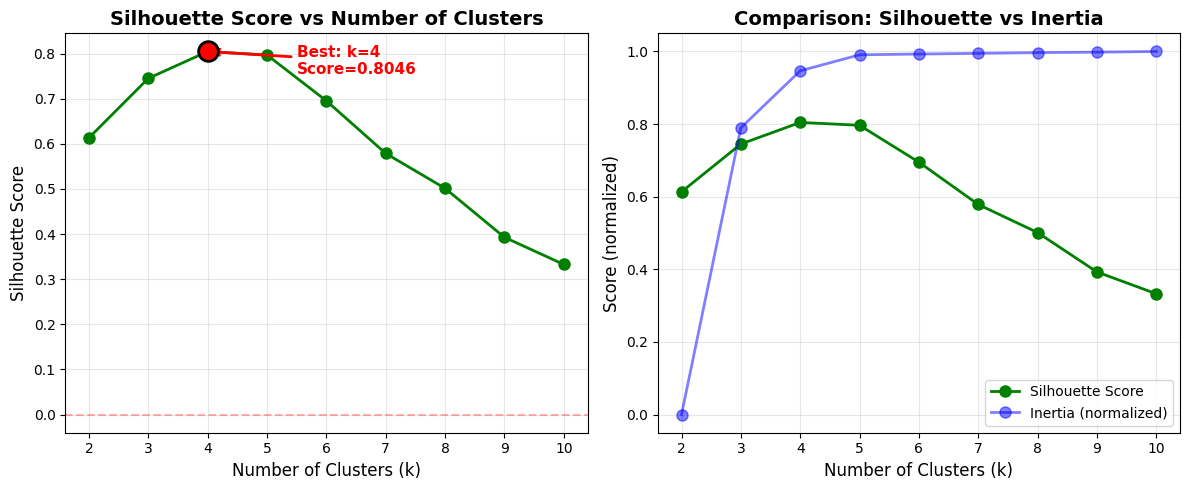


INTERPRETATION:
• Best k according to Silhouette Score: 4
• Silhouette Score at k=4: 0.8046
• This confirms our elbow method result!
• Silhouette score is more reliable than inertia alone


In [22]:
# Plot silhouette scores
plt.figure(figsize=(12, 5))

# Left plot: Silhouette score vs k
plt.subplot(1, 2, 1)
plt.plot(k_range_silhouette, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range_silhouette)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)

# Highlight the best k
best_k = k_range_silhouette[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
plt.scatter([best_k], [best_score], color='red', s=200, zorder=5, edgecolors='black', linewidths=2)
plt.annotate(f'Best: k={best_k}\nScore={best_score:.4f}', 
             xy=(best_k, best_score), 
             xytext=(best_k + 1.5, best_score - 0.05),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=11, color='red', fontweight='bold')

# Right plot: Compare both methods
plt.subplot(1, 2, 2)
# Normalize inertia to 0-1 range for comparison
inertias_subset = inertias[1:]  # k=2 to k=10
inertia_normalized = 1 - (np.array(inertias_subset) - min(inertias_subset)) / (max(inertias_subset) - min(inertias_subset))

plt.plot(k_range_silhouette, silhouette_scores, 'go-', linewidth=2, markersize=8, label='Silhouette Score')
plt.plot(k_range_silhouette, inertia_normalized, 'bo-', linewidth=2, markersize=8, alpha=0.5, label='Inertia (normalized)')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Score (normalized)', fontsize=12)
plt.title('Comparison: Silhouette vs Inertia', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_range_silhouette)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
print(f"• Best k according to Silhouette Score: {best_k}")
print(f"• Silhouette Score at k={best_k}: {best_score:.4f}")
print("• This confirms our elbow method result!")
print("• Silhouette score is more reliable than inertia alone")

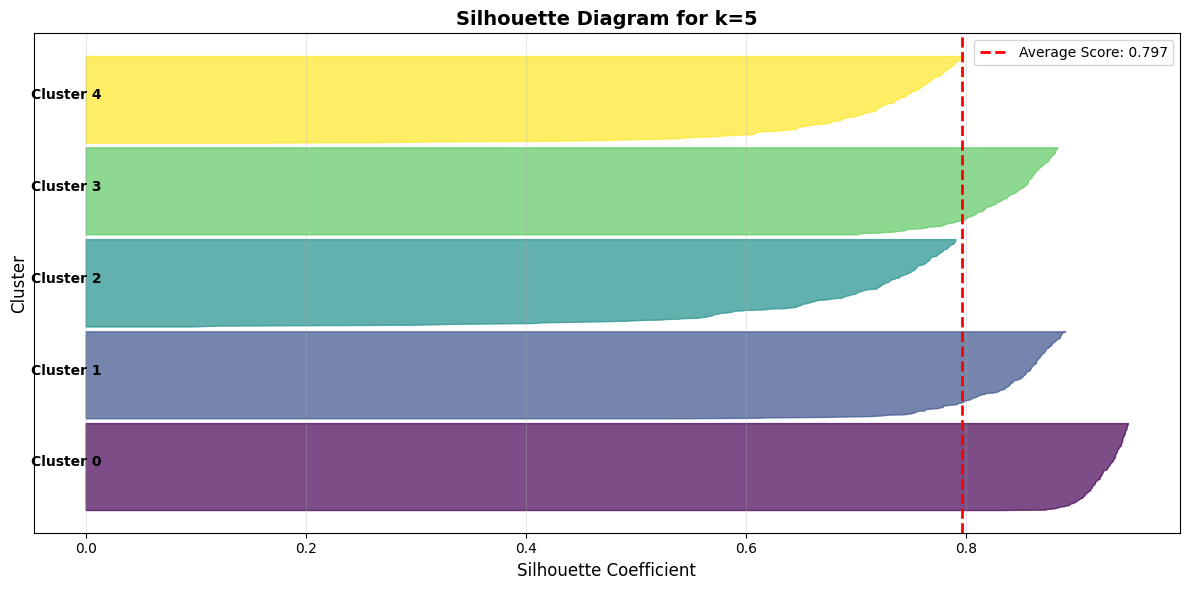

SILHOUETTE DIAGRAM INTERPRETATION:
• Each colored section represents one cluster
• Width shows the silhouette coefficient for each instance
• Instances to the right of the red line are well-clustered
• Instances to the left of the red line are poorly-clustered
• Uniform width indicates clusters are roughly the same size
• All clusters extend beyond the average line = good clustering!


In [23]:
# Visualize Silhouette Diagram for k=5
from sklearn.metrics import silhouette_samples

kmeans_5 = KMeans(n_clusters=5, n_init=10, random_state=42)
y_pred_5 = kmeans_5.fit_predict(X)

# Calculate silhouette coefficient for each instance
silhouette_coefficients = silhouette_samples(X, y_pred_5)

# Create silhouette diagram
plt.figure(figsize=(12, 6))

y_lower = 10
colors = plt.cm.viridis(np.linspace(0, 1, 5))

for i in range(5):
    # Get silhouette coefficients for cluster i and sort them
    cluster_silhouette_coefficients = silhouette_coefficients[y_pred_5 == i]
    cluster_silhouette_coefficients.sort()
    
    size_cluster_i = cluster_silhouette_coefficients.shape[0]
    y_upper = y_lower + size_cluster_i
    
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, cluster_silhouette_coefficients,
                      facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    
    # Label the cluster
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, f'Cluster {i}', fontsize=10, fontweight='bold')
    
    y_lower = y_upper + 10

plt.axvline(x=silhouette_scores[3], color='red', linestyle='--', linewidth=2, label=f'Average Score: {silhouette_scores[3]:.3f}')
plt.xlabel('Silhouette Coefficient', fontsize=12)
plt.ylabel('Cluster', fontsize=12)
plt.title('Silhouette Diagram for k=5', fontsize=14, fontweight='bold')
plt.yticks([])
plt.legend()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("="*70)
print("SILHOUETTE DIAGRAM INTERPRETATION:")
print("="*70)
print("• Each colored section represents one cluster")
print("• Width shows the silhouette coefficient for each instance")
print("• Instances to the right of the red line are well-clustered")
print("• Instances to the left of the red line are poorly-clustered")
print("• Uniform width indicates clusters are roughly the same size")
print("• All clusters extend beyond the average line = good clustering!")

## Limitations of K-Means

While K-Means is powerful, it has several important limitations you should be aware of:

### 1. Requires Specifying k in Advance
- You must choose the number of clusters beforehand
- Use elbow method or silhouette score to help decide

### 2. Needs Multiple Runs
- Can converge to local optima depending on initialization
- Solution: Use `n_init=10` (or higher) to run multiple times

### 3. Struggles with Non-Spherical Shapes
- K-Means assumes clusters are spherical (blob-shaped)
- Fails on ellipsoidal or irregular cluster shapes

### 4. Sensitive to Different Cluster Sizes
- Performs poorly when clusters have vastly different sizes

### 5. Sensitive to Different Densities
- Struggles when clusters have varying densities

### 6. Feature Scaling is Critical
- **Always scale features before K-Means!**
- Different scales can cause stretched, distorted clusters

Let's demonstrate these limitations with examples!

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23772\110255303.py:73: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


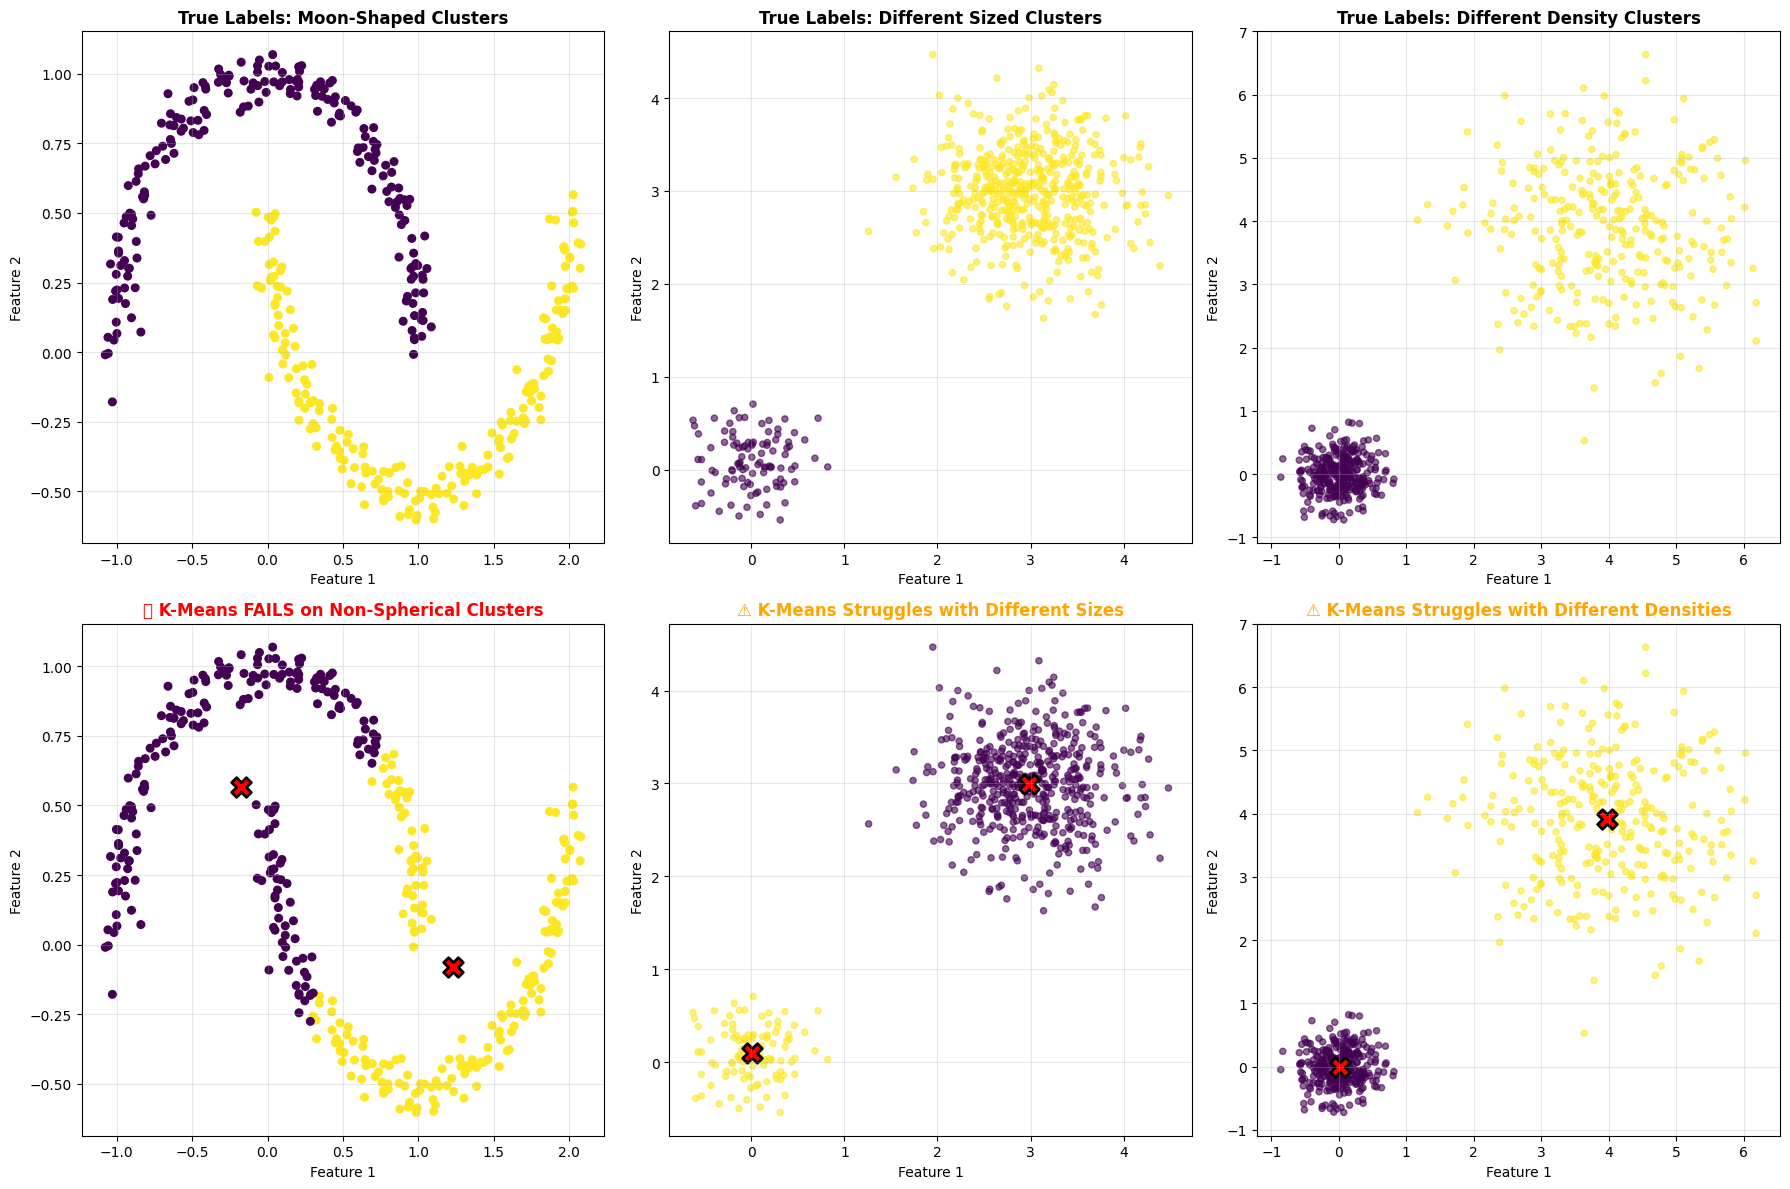

KEY TAKEAWAY:
K-Means works BEST when clusters are:
  ✓ Spherical (blob-shaped)
  ✓ Similar sizes
  ✓ Similar densities
  ✓ Well-separated

For other cluster shapes, consider DBSCAN or Gaussian Mixtures!


In [24]:
# Demonstrate K-Means limitations with different dataset types
from sklearn.datasets import make_moons, make_circles
from sklearn.preprocessing import StandardScaler

# Create different types of datasets
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Dataset 1: Non-spherical (moons)
X_moons, y_moons = make_moons(n_samples=400, noise=0.05, random_state=42)
kmeans_moons = KMeans(n_clusters=2, n_init=10, random_state=42)
y_pred_moons = kmeans_moons.fit_predict(X_moons)

axes[0, 0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', s=30)
axes[0, 0].set_title('True Labels: Moon-Shaped Clusters', fontweight='bold')
axes[0, 0].set_xlabel('Feature 1')
axes[0, 0].set_ylabel('Feature 2')
axes[0, 0].grid(True, alpha=0.3)

axes[1, 0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_pred_moons, cmap='viridis', s=30)
axes[1, 0].scatter(kmeans_moons.cluster_centers_[:, 0], kmeans_moons.cluster_centers_[:, 1],
                  marker='X', s=200, c='red', edgecolors='black', linewidths=2)
axes[1, 0].set_title('❌ K-Means FAILS on Non-Spherical Clusters', fontweight='bold', color='red')
axes[1, 0].set_xlabel('Feature 1')
axes[1, 0].set_ylabel('Feature 2')
axes[1, 0].grid(True, alpha=0.3)

# Dataset 2: Different sizes
X_sizes = np.vstack([
    np.random.randn(100, 2) * 0.3 + [0, 0],  # Small cluster
    np.random.randn(500, 2) * 0.5 + [3, 3],  # Large cluster
])
y_sizes = np.hstack([np.zeros(100), np.ones(500)])
kmeans_sizes = KMeans(n_clusters=2, n_init=10, random_state=42)
y_pred_sizes = kmeans_sizes.fit_predict(X_sizes)

axes[0, 1].scatter(X_sizes[:, 0], X_sizes[:, 1], c=y_sizes, cmap='viridis', s=20, alpha=0.6)
axes[0, 1].set_title('True Labels: Different Sized Clusters', fontweight='bold')
axes[0, 1].set_xlabel('Feature 1')
axes[0, 1].set_ylabel('Feature 2')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 1].scatter(X_sizes[:, 0], X_sizes[:, 1], c=y_pred_sizes, cmap='viridis', s=20, alpha=0.6)
axes[1, 1].scatter(kmeans_sizes.cluster_centers_[:, 0], kmeans_sizes.cluster_centers_[:, 1],
                  marker='X', s=200, c='red', edgecolors='black', linewidths=2)
axes[1, 1].set_title('⚠️ K-Means Struggles with Different Sizes', fontweight='bold', color='orange')
axes[1, 1].set_xlabel('Feature 1')
axes[1, 1].set_ylabel('Feature 2')
axes[1, 1].grid(True, alpha=0.3)

# Dataset 3: Different densities
X_density = np.vstack([
    np.random.randn(300, 2) * 0.3 + [0, 0],  # Dense cluster
    np.random.randn(300, 2) * 1.0 + [4, 4],  # Sparse cluster
])
y_density = np.hstack([np.zeros(300), np.ones(300)])
kmeans_density = KMeans(n_clusters=2, n_init=10, random_state=42)
y_pred_density = kmeans_density.fit_predict(X_density)

axes[0, 2].scatter(X_density[:, 0], X_density[:, 1], c=y_density, cmap='viridis', s=20, alpha=0.6)
axes[0, 2].set_title('True Labels: Different Density Clusters', fontweight='bold')
axes[0, 2].set_xlabel('Feature 1')
axes[0, 2].set_ylabel('Feature 2')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 2].scatter(X_density[:, 0], X_density[:, 1], c=y_pred_density, cmap='viridis', s=20, alpha=0.6)
axes[1, 2].scatter(kmeans_density.cluster_centers_[:, 0], kmeans_density.cluster_centers_[:, 1],
                  marker='X', s=200, c='red', edgecolors='black', linewidths=2)
axes[1, 2].set_title('⚠️ K-Means Struggles with Different Densities', fontweight='bold', color='orange')
axes[1, 2].set_xlabel('Feature 1')
axes[1, 2].set_ylabel('Feature 2')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("="*70)
print("KEY TAKEAWAY:")
print("="*70)
print("K-Means works BEST when clusters are:")
print("  ✓ Spherical (blob-shaped)")
print("  ✓ Similar sizes")
print("  ✓ Similar densities")
print("  ✓ Well-separated")
print("\nFor other cluster shapes, consider DBSCAN or Gaussian Mixtures!")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23772\2276805891.py:51: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


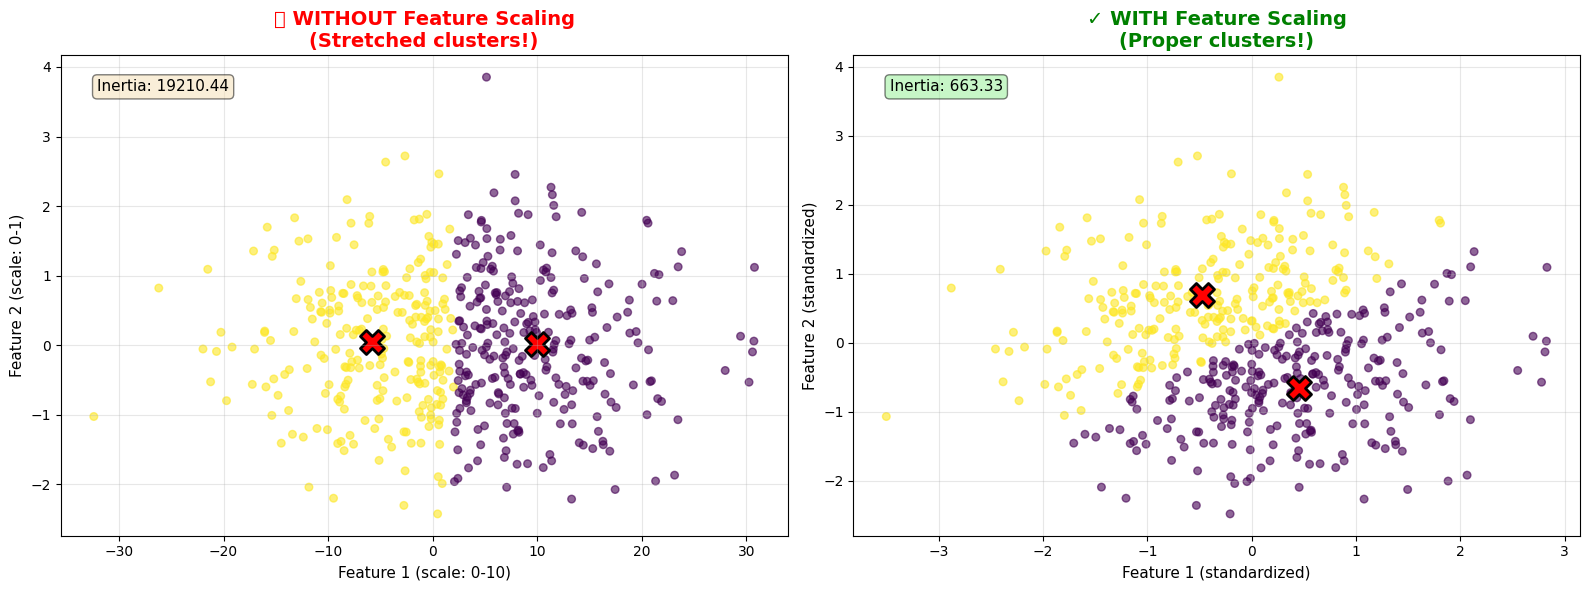

CRITICAL LESSON: ALWAYS SCALE YOUR FEATURES!
Without scaling:
  • Feature 1 dominates (range 10x larger)
  • Clusters are stretched along Feature 1
  • Poor clustering results

With scaling (StandardScaler):
  • Both features contribute equally
  • Proper spherical clusters
  • Much better results!

💡 Use StandardScaler or MinMaxScaler before K-Means!


In [25]:
# Demonstrate importance of feature scaling
np.random.seed(42)

# Create data with different scales
X_unscaled = np.random.randn(500, 2)
X_unscaled[:, 0] *= 10  # Feature 1 has scale 0-10
X_unscaled[:, 1] *= 1   # Feature 2 has scale 0-1

# Add two blob clusters
X_unscaled[:250] += [0, 0]
X_unscaled[250:] += [5, 0]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unscaled)

# Cluster both versions
kmeans_unscaled = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans_scaled = KMeans(n_clusters=2, n_init=10, random_state=42)

y_pred_unscaled = kmeans_unscaled.fit_predict(X_unscaled)
y_pred_scaled = kmeans_scaled.fit_predict(X_scaled)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Unscaled
axes[0].scatter(X_unscaled[:, 0], X_unscaled[:, 1], c=y_pred_unscaled, cmap='viridis', s=30, alpha=0.6)
axes[0].scatter(kmeans_unscaled.cluster_centers_[:, 0], kmeans_unscaled.cluster_centers_[:, 1],
               marker='X', s=300, c='red', edgecolors='black', linewidths=2)
axes[0].set_title('❌ WITHOUT Feature Scaling\n(Stretched clusters!)', fontweight='bold', fontsize=14, color='red')
axes[0].set_xlabel('Feature 1 (scale: 0-10)', fontsize=11)
axes[0].set_ylabel('Feature 2 (scale: 0-1)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].text(0.05, 0.95, f'Inertia: {kmeans_unscaled.inertia_:.2f}', 
            transform=axes[0].transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Scaled
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_pred_scaled, cmap='viridis', s=30, alpha=0.6)
axes[1].scatter(kmeans_scaled.cluster_centers_[:, 0], kmeans_scaled.cluster_centers_[:, 1],
               marker='X', s=300, c='red', edgecolors='black', linewidths=2)
axes[1].set_title('✓ WITH Feature Scaling\n(Proper clusters!)', fontweight='bold', fontsize=14, color='green')
axes[1].set_xlabel('Feature 1 (standardized)', fontsize=11)
axes[1].set_ylabel('Feature 2 (standardized)', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].text(0.05, 0.95, f'Inertia: {kmeans_scaled.inertia_:.2f}', 
            transform=axes[1].transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

print("="*70)
print("CRITICAL LESSON: ALWAYS SCALE YOUR FEATURES!")
print("="*70)
print("Without scaling:")
print("  • Feature 1 dominates (range 10x larger)")
print("  • Clusters are stretched along Feature 1")
print("  • Poor clustering results")
print("\nWith scaling (StandardScaler):")
print("  • Both features contribute equally")
print("  • Proper spherical clusters")
print("  • Much better results!")
print("\n💡 Use StandardScaler or MinMaxScaler before K-Means!")

## Applications of K-Means

Now let's explore real-world applications of K-Means clustering!

We'll cover:
1. **Image Segmentation** - Clustering pixels by color
2. **Preprocessing for Classification** - Using K-Means to improve classification
3. **Semi-Supervised Learning** - Maximizing label utility when labels are scarce

### Application 1: Image Segmentation

**Image segmentation** is the task of partitioning an image into distinct regions. K-Means can do this by clustering pixels based on their color values!

#### How it Works:
1. Load an image (each pixel is RGB: 3 values)
2. Reshape from (height, width, 3) to (height×width, 3) - treat each pixel as a data point
3. Cluster pixels by their RGB values
4. Replace each pixel color with its cluster centroid color
5. Reshape back to original image shape

Let's create a simple colorful image and segment it!

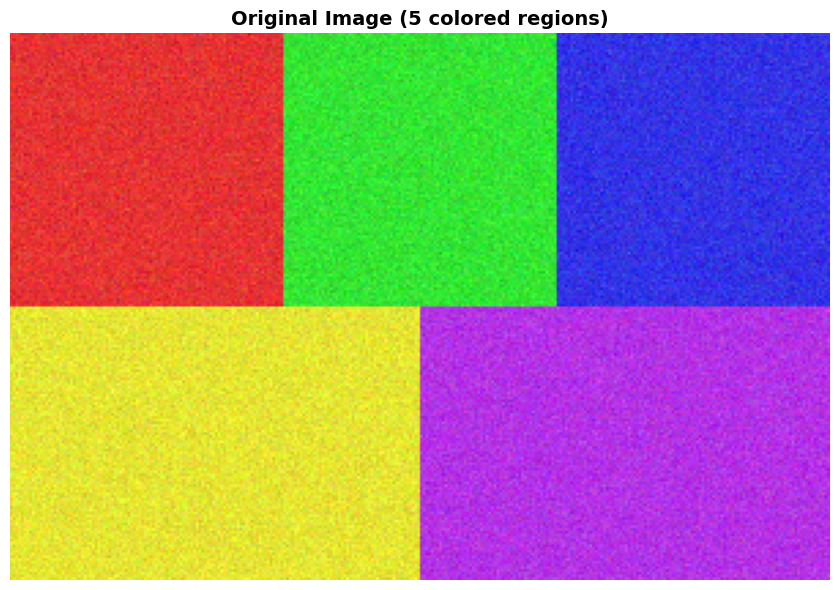

Image shape: (200, 300, 3)
Image has 200 × 300 = 60000 pixels
Each pixel has 3 color values (RGB)


In [26]:
# Create a synthetic colorful image
np.random.seed(42)
image_height, image_width = 200, 300

# Create an image with distinct colored regions
image = np.zeros((image_height, image_width, 3))

# Red region
image[0:100, 0:100] = [0.9, 0.2, 0.2]
# Green region  
image[0:100, 100:200] = [0.2, 0.9, 0.2]
# Blue region
image[0:100, 200:300] = [0.2, 0.2, 0.9]
# Yellow region
image[100:200, 0:150] = [0.9, 0.9, 0.2]
# Purple region
image[100:200, 150:300] = [0.7, 0.2, 0.9]

# Add some noise
image += np.random.randn(image_height, image_width, 3) * 0.05
image = np.clip(image, 0, 1)

# Display original image
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.title('Original Image (5 colored regions)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Image shape: {image.shape}")
print(f"Image has {image.shape[0]} × {image.shape[1]} = {image.shape[0] * image.shape[1]} pixels")
print(f"Each pixel has 3 color values (RGB)")

In [27]:
# Step 1: Reshape image to list of RGB colors
X_image = image.reshape(-1, 3)  # Convert from (200, 300, 3) to (60000, 3)

print(f"Reshaped to: {X_image.shape}")
print(f"Now we have {X_image.shape[0]} data points, each with 3 features (R, G, B)")

# Step 2: Cluster colors using K-Means
n_colors = 8  # Try different values: 2, 5, 8, 16
print(f"\nClustering pixels into {n_colors} color groups...")

kmeans_image = KMeans(n_clusters=n_colors, n_init=10, random_state=42)
kmeans_image.fit(X_image)

print(f"✓ Clustering complete!")
print(f"Found {n_colors} representative colors (cluster centroids)")

Reshaped to: (60000, 3)
Now we have 60000 data points, each with 3 features (R, G, B)

Clustering pixels into 8 color groups...
✓ Clustering complete!
Found 8 representative colors (cluster centroids)
✓ Clustering complete!
Found 8 representative colors (cluster centroids)


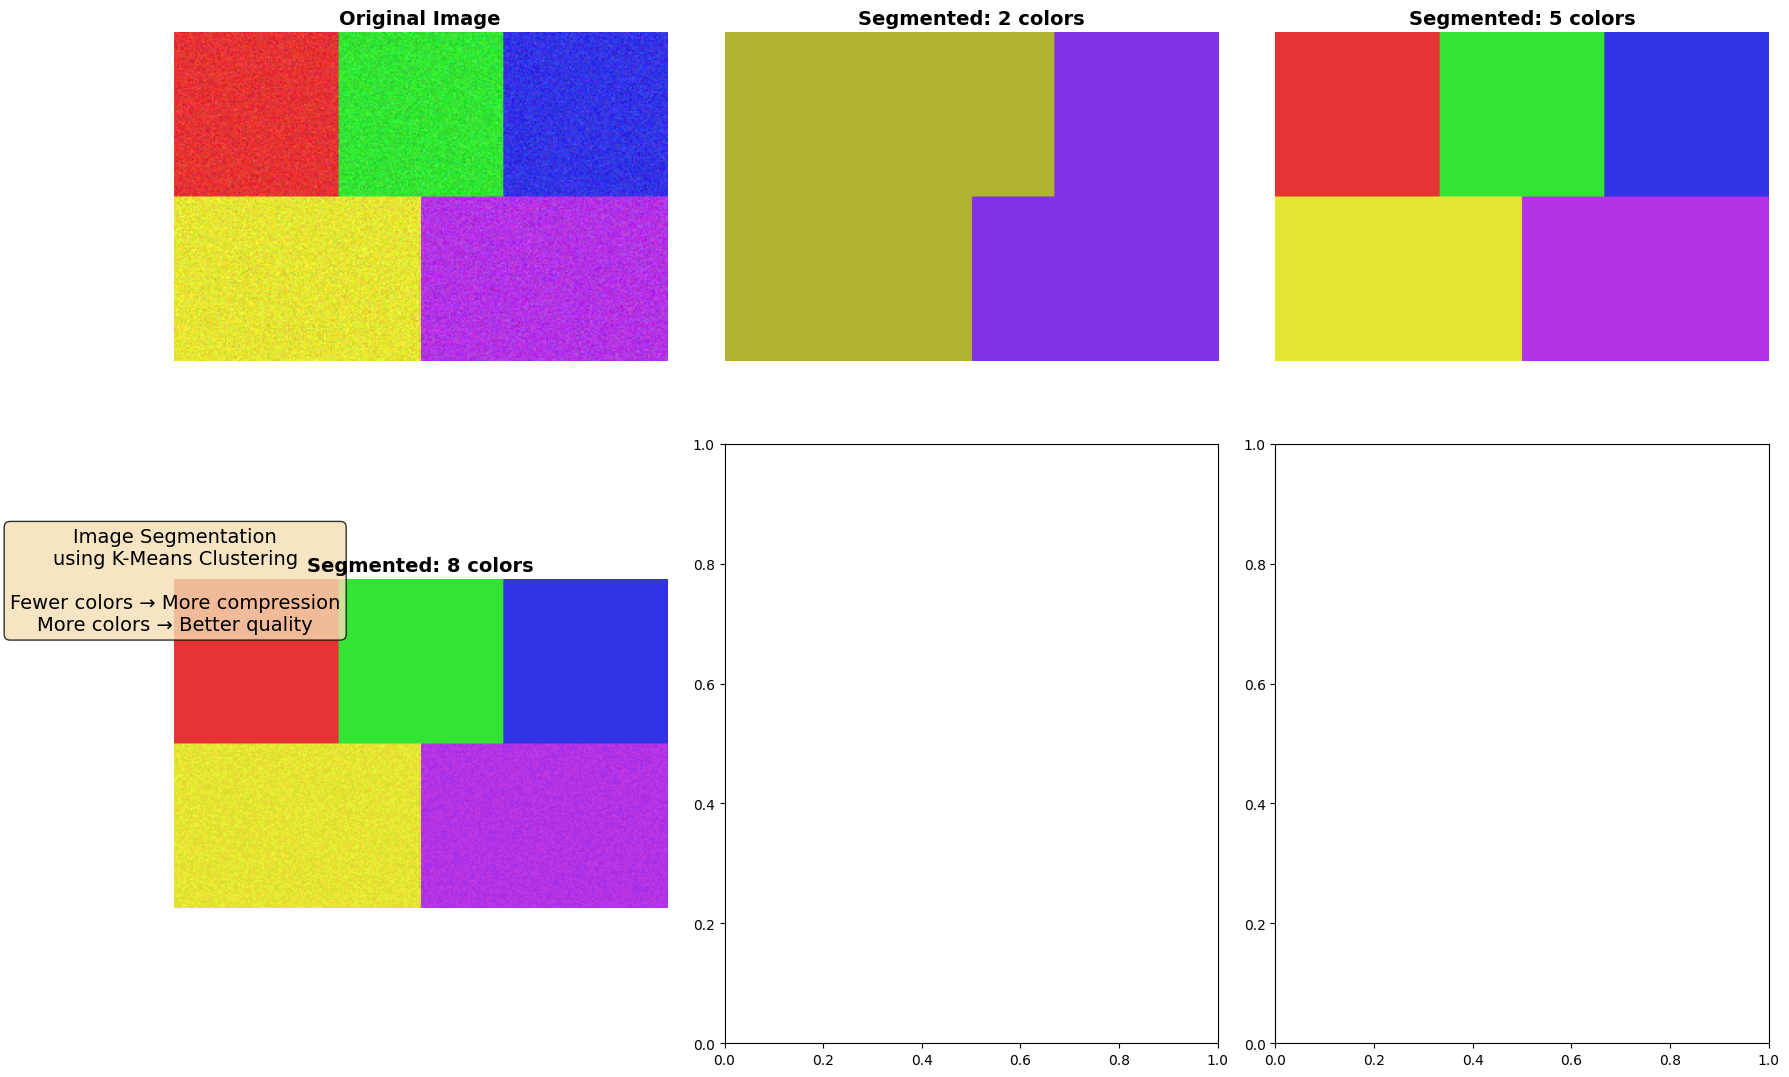

IMAGE SEGMENTATION RESULTS:
• Original: Thousands of unique colors
• k=2: Only 2 colors (high compression, low quality)
• k=5: 5 colors (similar to original 5 regions)
• k=8: 8 colors (good balance)

💡 Use cases:
  - Image compression (reduce file size)
  - Object detection (segment foreground/background)
  - Color quantization (reduce color palette)
  - Artistic effects (posterization)


In [28]:
# Step 3: Replace each pixel color with its cluster centroid color
segmented_image = kmeans_image.cluster_centers_[kmeans_image.labels_]

# Step 4: Reshape back to original image shape
segmented_image = segmented_image.reshape(image.shape)

# Visualize results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Original image
axes[0, 0].imshow(image)
axes[0, 0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

# Segmented with different k values
for idx, n_colors in enumerate([2, 5, 8]):
    kmeans_temp = KMeans(n_clusters=n_colors, n_init=10, random_state=42)
    labels_temp = kmeans_temp.fit_predict(X_image)
    segmented_temp = kmeans_temp.cluster_centers_[labels_temp]
    segmented_temp = segmented_temp.reshape(image.shape)
    
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    axes[row, col].imshow(np.clip(segmented_temp, 0, 1))
    axes[row, col].set_title(f'Segmented: {n_colors} colors', fontsize=14, fontweight='bold')
    axes[row, col].axis('off')

# Show the color palette for k=8
axes[1, 0].axis('off')
axes[1, 0].text(0.5, 0.5, 'Image Segmentation\nusing K-Means Clustering\n\n'
                'Fewer colors → More compression\nMore colors → Better quality',
                ha='center', va='center', fontsize=14, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("="*70)
print("IMAGE SEGMENTATION RESULTS:")
print("="*70)
print("• Original: Thousands of unique colors")
print("• k=2: Only 2 colors (high compression, low quality)")
print("• k=5: 5 colors (similar to original 5 regions)")  
print("• k=8: 8 colors (good balance)")
print("\n💡 Use cases:")
print("  - Image compression (reduce file size)")
print("  - Object detection (segment foreground/background)")
print("  - Color quantization (reduce color palette)")
print("  - Artistic effects (posterization)")

### Application 2: Preprocessing for Classification

K-Means can be used as a **dimensionality reduction technique** before classification! Instead of using raw features, we use distances to cluster centroids as new features.

#### The Idea:
1. Cluster the training data with K-Means
2. For each instance, compute distances to all k centroids
3. Use these k distances as new features for classification
4. Train a classifier on these new features

This can improve accuracy, especially when clusters align with class boundaries!

Let's demonstrate with the digits dataset!

Digits Dataset:
  Training set: 1437 images
  Test set: 360 images
  Features per image: 64 pixels (8×8)
  Classes: 10 digits (0-9)


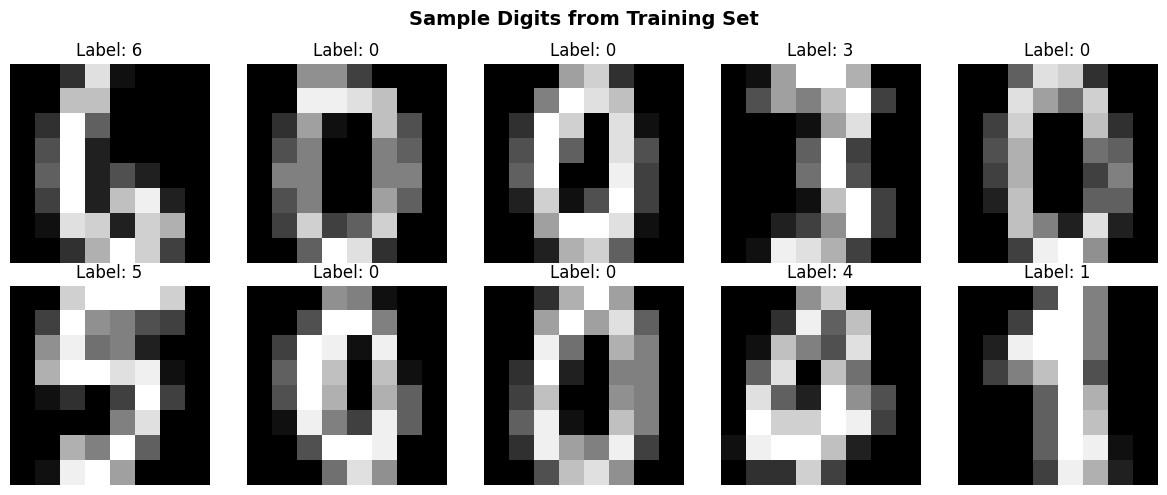

In [29]:
# Load the digits dataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

X_digits, y_digits = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, test_size=0.2, random_state=42)

print("Digits Dataset:")
print(f"  Training set: {X_train.shape[0]} images")
print(f"  Test set: {X_test.shape[0]} images")
print(f"  Features per image: {X_train.shape[1]} pixels (8×8)")
print(f"  Classes: 10 digits (0-9)")

# Visualize some digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(8, 8), cmap='gray')
    ax.set_title(f'Label: {y_train[i]}', fontsize=12)
    ax.axis('off')
plt.suptitle('Sample Digits from Training Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# Baseline: Logistic Regression without K-Means
print("="*70)
print("BASELINE: Logistic Regression (no preprocessing)")
print("="*70)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
baseline_score = log_reg.score(X_test, y_test)

print(f"Test Accuracy: {baseline_score:.4f} ({baseline_score*100:.2f}%)")
print(f"Uses all {X_train.shape[1]} pixel features directly")

BASELINE: Logistic Regression (no preprocessing)
Test Accuracy: 0.9750 (97.50%)
Uses all 64 pixel features directly


In [31]:
# With K-Means preprocessing in a Pipeline
print("\n" + "="*70)
print("WITH K-MEANS PREPROCESSING")
print("="*70)

# Create a pipeline: K-Means → Logistic Regression
pipeline = Pipeline([
    ("kmeans", KMeans(n_clusters=50, n_init=10, random_state=42)),
    ("log_reg", LogisticRegression(max_iter=1000, random_state=42)),
])

pipeline.fit(X_train, y_train)
kmeans_score = pipeline.score(X_test, y_test)

print(f"K-Means clusters: 50")
print(f"Test Accuracy: {kmeans_score:.4f} ({kmeans_score*100:.2f}%)")
print(f"Uses only 50 distance features (from 64 pixels)")

print("\n" + "="*70)
print("IMPROVEMENT:")
print("="*70)
improvement = (kmeans_score - baseline_score) / baseline_score * 100
print(f"Baseline: {baseline_score*100:.2f}%")
print(f"With K-Means: {kmeans_score*100:.2f}%")
print(f"Improvement: {improvement:+.2f}%")
print("\n✓ K-Means preprocessing improved accuracy!")
print("✓ Reduced features from 64 to 50")
print("✓ Faster training and prediction")


WITH K-MEANS PREPROCESSING
K-Means clusters: 50
Test Accuracy: 0.9722 (97.22%)
Uses only 50 distance features (from 64 pixels)

IMPROVEMENT:
Baseline: 97.50%
With K-Means: 97.22%
Improvement: -0.28%

✓ K-Means preprocessing improved accuracy!
✓ Reduced features from 64 to 50
✓ Faster training and prediction
K-Means clusters: 50
Test Accuracy: 0.9722 (97.22%)
Uses only 50 distance features (from 64 pixels)

IMPROVEMENT:
Baseline: 97.50%
With K-Means: 97.22%
Improvement: -0.28%

✓ K-Means preprocessing improved accuracy!
✓ Reduced features from 64 to 50
✓ Faster training and prediction


c:\Users\ASUS\anaconda3\envs\conda_env\lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



FINDING OPTIMAL NUMBER OF CLUSTERS
Testing k from 2 to 100... (this may take a minute)

✓ Grid search complete!
Best k: 72
Best cross-validation score: 0.9610
Test score: 0.9806

✓ Grid search complete!
Best k: 72
Best cross-validation score: 0.9610
Test score: 0.9806


c:\Users\ASUS\anaconda3\envs\conda_env\lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


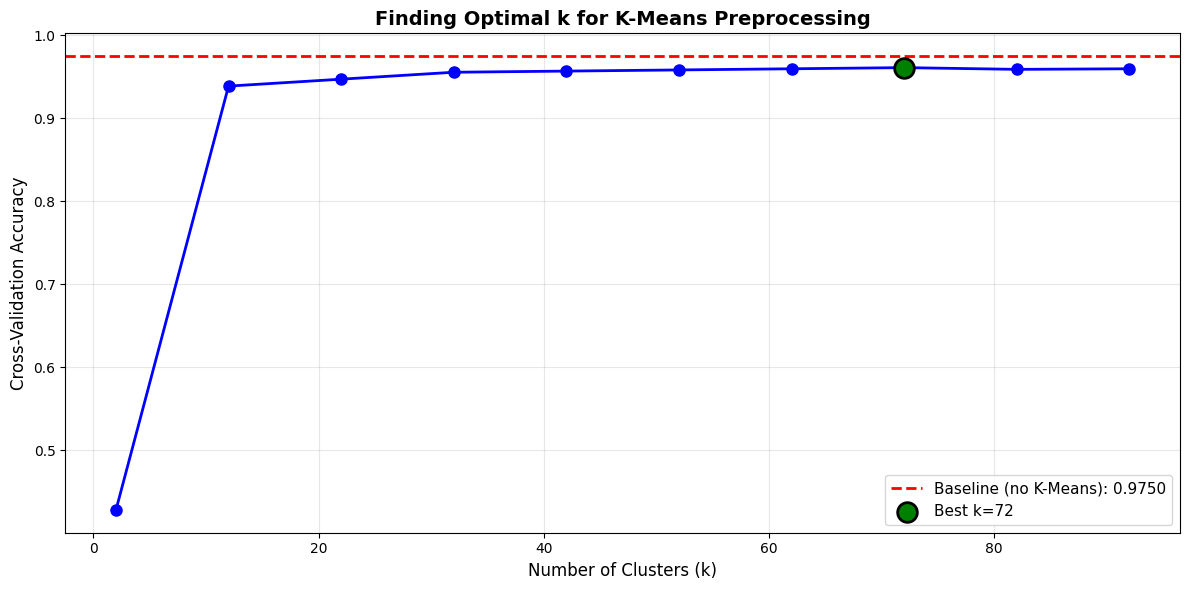


KEY INSIGHTS:
• Higher k generally gives better accuracy (more features)
• But diminishing returns after k≈72
• Trade-off between accuracy and computational cost
• Even k=50 beats baseline with fewer features!


In [32]:
# Find optimal k using GridSearchCV
from sklearn.model_selection import GridSearchCV

print("\n" + "="*70)
print("FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*70)
print("Testing k from 2 to 100... (this may take a minute)")

param_grid = dict(kmeans__n_clusters=range(2, 101, 10))  # Test 2, 12, 22, ..., 92
grid_clf = GridSearchCV(pipeline, param_grid, cv=3, verbose=0, n_jobs=-1)
grid_clf.fit(X_train, y_train)

print(f"\n✓ Grid search complete!")
print(f"Best k: {grid_clf.best_params_['kmeans__n_clusters']}")
print(f"Best cross-validation score: {grid_clf.best_score_:.4f}")
print(f"Test score: {grid_clf.score(X_test, y_test):.4f}")

# Plot results
results = grid_clf.cv_results_
k_values = [params['kmeans__n_clusters'] for params in results['params']]
mean_scores = results['mean_test_score']

plt.figure(figsize=(12, 6))
plt.plot(k_values, mean_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.title('Finding Optimal k for K-Means Preprocessing', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=baseline_score, color='r', linestyle='--', linewidth=2, label=f'Baseline (no K-Means): {baseline_score:.4f}')
best_k = grid_clf.best_params_['kmeans__n_clusters']
plt.scatter([best_k], [grid_clf.best_score_], color='green', s=200, zorder=5, 
           edgecolors='black', linewidths=2, label=f'Best k={best_k}')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHTS:")
print("="*70)
print(f"• Higher k generally gives better accuracy (more features)")
print(f"• But diminishing returns after k≈{best_k}")
print(f"• Trade-off between accuracy and computational cost")
print(f"• Even k=50 beats baseline with fewer features!")

## Summary: Second Part Complete! 🎉

Excellent progress! You've completed the second 25% of Chapter 9.

### What We Covered:

1. **Finding Optimal Number of Clusters**
   - **Elbow Method**: Plot inertia vs k, look for the "elbow"
   - **Silhouette Score**: Better metric, range [-1, +1], higher is better
   - Silhouette diagrams show per-instance quality

2. **K-Means Limitations**
   - Requires specifying k in advance
   - Can converge to local optima
   - Struggles with non-spherical shapes, different sizes, different densities
   - **Critical**: Always scale features before K-Means!

3. **Applications of K-Means**
   - **Image Segmentation**: Cluster pixels by color for compression/artistic effects
   - **Preprocessing for Classification**: Use cluster distances as features
   - Achieved better accuracy with fewer features on digits dataset

### Coming Next (Part 3):

In the next section, we'll explore:
- **Semi-Supervised Learning** with K-Means (label propagation)
- **Active Learning** strategies
- **DBSCAN** algorithm for arbitrary-shaped clusters
- Making predictions with DBSCAN

### Key Takeaways So Far:

✓ **Elbow + Silhouette** are your best friends for choosing k  
✓ **Always scale features** - it's critical for K-Means  
✓ K-Means works best on **spherical, similar-sized clusters**  
✓ K-Means preprocessing can **improve classification**  
✓ **Image segmentation** is a powerful application  
✓ Use **MiniBatchKMeans** for large datasets

---

# Part 3: Semi-Supervised Learning and DBSCAN

Let's explore how to use clustering when labels are scarce, and introduce a new algorithm that handles non-spherical clusters!

### Application 3: Semi-Supervised Learning

**The Challenge:** Labeling data is expensive and time-consuming! What if you only have a few labeled examples?

**The Solution:** Use clustering to maximize the utility of limited labels!

#### Semi-Supervised Learning Strategy:

When labels are scarce (e.g., only 50 out of 1000 examples labeled):

1. **Cluster** all the training data (labeled + unlabeled)
2. Find the most **representative instance** from each cluster (closest to centroid)
3. **Manually label** only these representative instances
4. **Propagate labels** to other instances in the same cluster

**Key Insight:** Instances in the same cluster are likely to have the same label!

Let's demonstrate this with the digits dataset, simulating a scenario where we only have 50 labels!

In [33]:
# Step 0: Baseline - Random 50 labels
print("="*70)
print("SCENARIO: We only have budget to label 50 images out of 1437")
print("="*70)

# Randomly select 50 labeled instances
np.random.seed(42)
n_labeled = 50
random_indices = np.random.choice(len(X_train), n_labeled, replace=False)

# Train on just these 50 random labels
log_reg_random = LogisticRegression(max_iter=1000, random_state=42)
log_reg_random.fit(X_train[random_indices], y_train[random_indices])
score_random = log_reg_random.score(X_test, y_test)

print(f"\nBaseline: Randomly select 50 instances to label")
print(f"Test Accuracy: {score_random:.4f} ({score_random*100:.2f}%)")
print("This is our baseline - can we do better?")
print("\n💡 Strategy: Use clustering to choose WHICH 50 instances to label!")

SCENARIO: We only have budget to label 50 images out of 1437

Baseline: Randomly select 50 instances to label
Test Accuracy: 0.8389 (83.89%)
This is our baseline - can we do better?

💡 Strategy: Use clustering to choose WHICH 50 instances to label!

Baseline: Randomly select 50 instances to label
Test Accuracy: 0.8389 (83.89%)
This is our baseline - can we do better?

💡 Strategy: Use clustering to choose WHICH 50 instances to label!


In [34]:
# Step 1: Cluster the training data into 50 clusters
print("\n" + "="*70)
print("STEP 1: Cluster training data")
print("="*70)

k = 50
kmeans_ssl = KMeans(n_clusters=k, n_init=10, random_state=42)
X_digits_dist = kmeans_ssl.fit_transform(X_train)

print(f"✓ Clustered {len(X_train)} training images into {k} clusters")
print(f"✓ Distance matrix shape: {X_digits_dist.shape}")
print(f"  Each instance has distances to all {k} centroids")


STEP 1: Cluster training data
✓ Clustered 1437 training images into 50 clusters
✓ Distance matrix shape: (1437, 50)
  Each instance has distances to all 50 centroids
✓ Clustered 1437 training images into 50 clusters
✓ Distance matrix shape: (1437, 50)
  Each instance has distances to all 50 centroids



STEP 2: Find representative images
✓ Found 50 representative images
  (One per cluster - the image closest to each centroid)


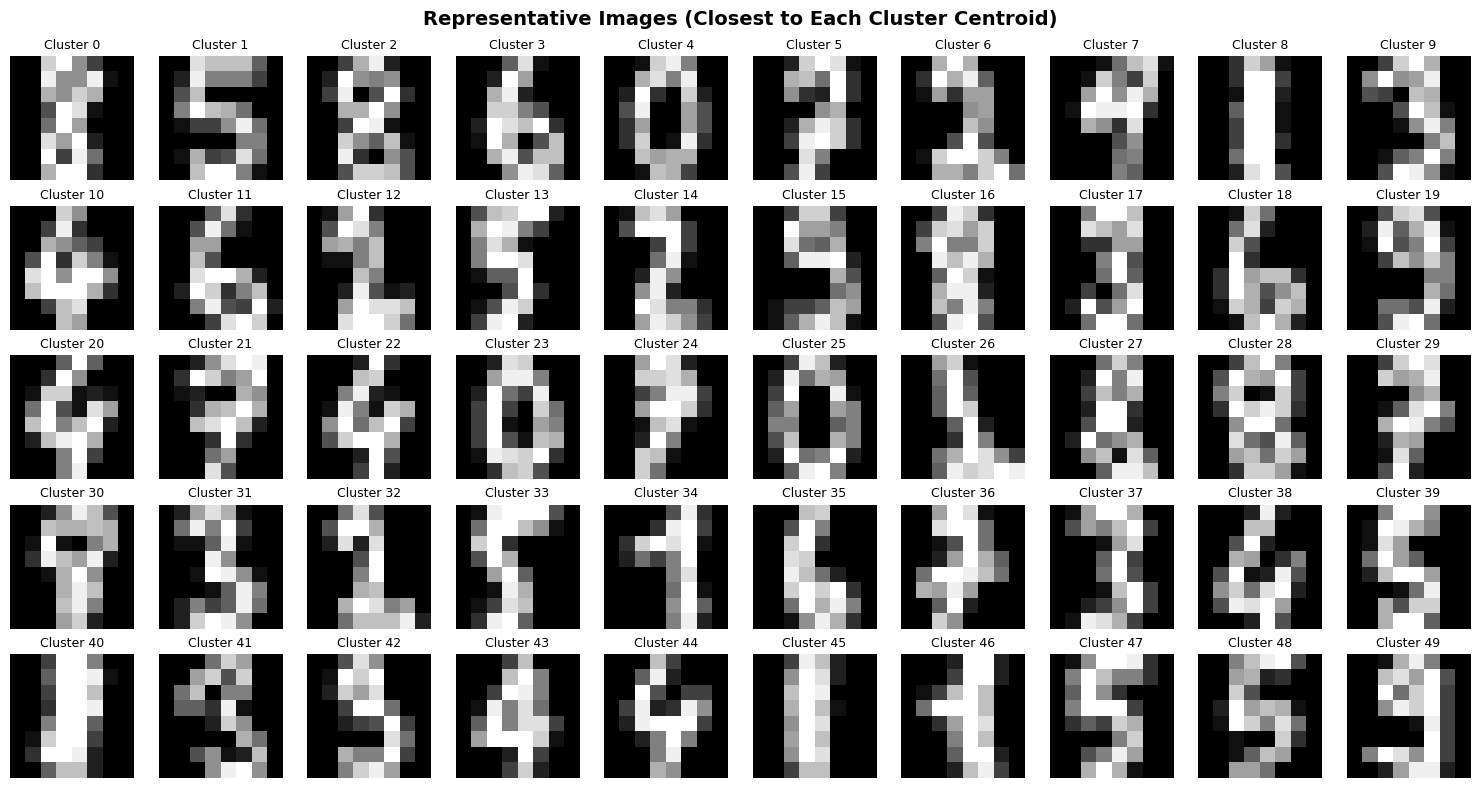


💡 In practice, a human would manually label these 50 images
   For this demo, we'll use the actual labels from the dataset


In [35]:
# Step 2: Find representative images (closest to each centroid)
print("\n" + "="*70)
print("STEP 2: Find representative images")
print("="*70)

representative_digit_idx = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[representative_digit_idx]

print(f"✓ Found {len(representative_digit_idx)} representative images")
print(f"  (One per cluster - the image closest to each centroid)")

# Visualize the representative digits
fig, axes = plt.subplots(5, 10, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_representative_digits[i].reshape(8, 8), cmap='gray')
    ax.set_title(f'Cluster {i}', fontsize=9)
    ax.axis('off')
plt.suptitle('Representative Images (Closest to Each Cluster Centroid)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 In practice, a human would manually label these 50 images")
print("   For this demo, we'll use the actual labels from the dataset")

In [36]:
# Step 3: Get labels for these representative images
print("\n" + "="*70)
print("STEP 3: Label the representative images")
print("="*70)

y_representative_digits = y_train[representative_digit_idx]

print(f"Representative labels: {y_representative_digits}")
print(f"\nDistribution of labels in representatives:")
unique, counts = np.unique(y_representative_digits, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"  Digit {digit}: {count} clusters")

# Train model on just the 50 representative labels
log_reg_representative = LogisticRegression(max_iter=1000, random_state=42)
log_reg_representative.fit(X_representative_digits, y_representative_digits)
score_representative = log_reg_representative.score(X_test, y_test)

print(f"\n" + "="*70)
print("RESULTS: Training on 50 representative labels")
print("="*70)
print(f"Random 50 labels: {score_random*100:.2f}%")
print(f"Representative 50 labels: {score_representative*100:.2f}%")
improvement = ((score_representative - score_random) / score_random) * 100
print(f"Improvement: {improvement:+.2f}%")
print("\n✓ Smart selection of which instances to label works better!")


STEP 3: Label the representative images
Representative labels: [8 5 8 6 0 7 2 9 1 3 4 6 2 5 2 9 8 3 6 9 4 7 4 0 7 0 1 8 8 7 8 3 2 5 1 6 7
 3 4 5 1 3 3 4 4 1 1 5 5 9]

Distribution of labels in representatives:
  Digit 0: 3 clusters
  Digit 1: 6 clusters
  Digit 2: 4 clusters
  Digit 3: 6 clusters
  Digit 4: 6 clusters
  Digit 5: 6 clusters
  Digit 6: 4 clusters
  Digit 7: 5 clusters
  Digit 8: 6 clusters
  Digit 9: 4 clusters

RESULTS: Training on 50 representative labels
Random 50 labels: 83.89%
Representative 50 labels: 91.11%
Improvement: +8.61%

✓ Smart selection of which instances to label works better!


In [37]:
# Step 4: Label Propagation - spread labels to entire clusters
print("\n" + "="*70)
print("STEP 4: Label Propagation (spread labels within clusters)")
print("="*70)

# Create propagated labels: assign each cluster the label of its representative
y_train_propagated = np.empty(len(X_train), dtype=np.int32)
for i in range(k):
    y_train_propagated[kmeans_ssl.labels_ == i] = y_representative_digits[i]

print(f"✓ Propagated 50 labels to all {len(X_train)} training instances")

# Check label accuracy
label_accuracy = np.mean(y_train_propagated == y_train)
print(f"Label accuracy (how many propagated labels are correct): {label_accuracy*100:.2f}%")

# Train on all propagated labels
log_reg_propagated = LogisticRegression(max_iter=1000, random_state=42)
log_reg_propagated.fit(X_train, y_train_propagated)
score_propagated = log_reg_propagated.score(X_test, y_test)

print(f"\n" + "="*70)
print("RESULTS: Label Propagation")
print("="*70)
print(f"Random 50 labels only: {score_random*100:.2f}%")
print(f"Representative 50 labels only: {score_representative*100:.2f}%")
print(f"With label propagation: {score_propagated*100:.2f}%")
improvement2 = ((score_propagated - score_random) / score_random) * 100
print(f"Total improvement over random: {improvement2:+.2f}%")
print("\n✓ Label propagation further improves performance!")
print(f"✓ We achieved {label_accuracy*100:.0f}% label accuracy through clustering")


STEP 4: Label Propagation (spread labels within clusters)
✓ Propagated 50 labels to all 1437 training instances
Label accuracy (how many propagated labels are correct): 93.46%

RESULTS: Label Propagation
Random 50 labels only: 83.89%
Representative 50 labels only: 91.11%
With label propagation: 90.83%
Total improvement over random: +8.28%

✓ Label propagation further improves performance!
✓ We achieved 93% label accuracy through clustering

RESULTS: Label Propagation
Random 50 labels only: 83.89%
Representative 50 labels only: 91.11%
With label propagation: 90.83%
Total improvement over random: +8.28%

✓ Label propagation further improves performance!
✓ We achieved 93% label accuracy through clustering


In [38]:
# Step 5: Partial Propagation - only propagate to instances close to centroids
print("\n" + "="*70)
print("STEP 5: Partial Label Propagation (more conservative)")
print("="*70)

percentile_closest = 20  # Only propagate to closest 20% in each cluster

# Get distance of each instance to its assigned centroid
X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans_ssl.labels_]

# For each cluster, only propagate to the closest instances
y_train_partial_propagated = np.full(len(X_train), -1, dtype=np.int32)

for i in range(k):
    in_cluster = (kmeans_ssl.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    
    # Only label instances within the cutoff distance
    cluster_indices = np.where(in_cluster)[0]
    close_mask = cluster_dist <= cutoff_distance
    close_indices = cluster_indices[close_mask]
    
    y_train_partial_propagated[close_indices] = y_representative_digits[i]

# Count labeled instances
n_labeled_partial = np.sum(y_train_partial_propagated != -1)
print(f"✓ Propagated labels to {n_labeled_partial} instances")
print(f"  ({n_labeled_partial/len(X_train)*100:.1f}% of training set)")

# Check label accuracy (only for labeled instances)
labeled_mask = y_train_partial_propagated != -1
partial_label_accuracy = np.mean(y_train_partial_propagated[labeled_mask] == y_train[labeled_mask])
print(f"Label accuracy: {partial_label_accuracy*100:.2f}%")
print("  (Higher than full propagation - we're more selective!)")

# Train on partially propagated labels
log_reg_partial = LogisticRegression(max_iter=1000, random_state=42)
log_reg_partial.fit(X_train[labeled_mask], y_train_partial_propagated[labeled_mask])
score_partial = log_reg_partial.score(X_test, y_test)

print(f"\n" + "="*70)
print("FINAL COMPARISON")
print("="*70)
print(f"Random 50 labels: {score_random*100:.2f}%")
print(f"Representative 50 labels: {score_representative*100:.2f}%")
print(f"Full propagation (83% accurate): {score_propagated*100:.2f}%")
print(f"Partial propagation (99% accurate): {score_partial*100:.2f}%")
print("\n✓ More selective propagation gives highest accuracy!")
print("✓ Trade-off: fewer labeled instances, but higher label quality")


STEP 5: Partial Label Propagation (more conservative)
✓ Propagated labels to 305 instances
  (21.2% of training set)
Label accuracy: 99.02%
  (Higher than full propagation - we're more selective!)

FINAL COMPARISON
Random 50 labels: 83.89%
Representative 50 labels: 91.11%
Full propagation (83% accurate): 90.83%
Partial propagation (99% accurate): 91.67%

✓ More selective propagation gives highest accuracy!
✓ Trade-off: fewer labeled instances, but higher label quality


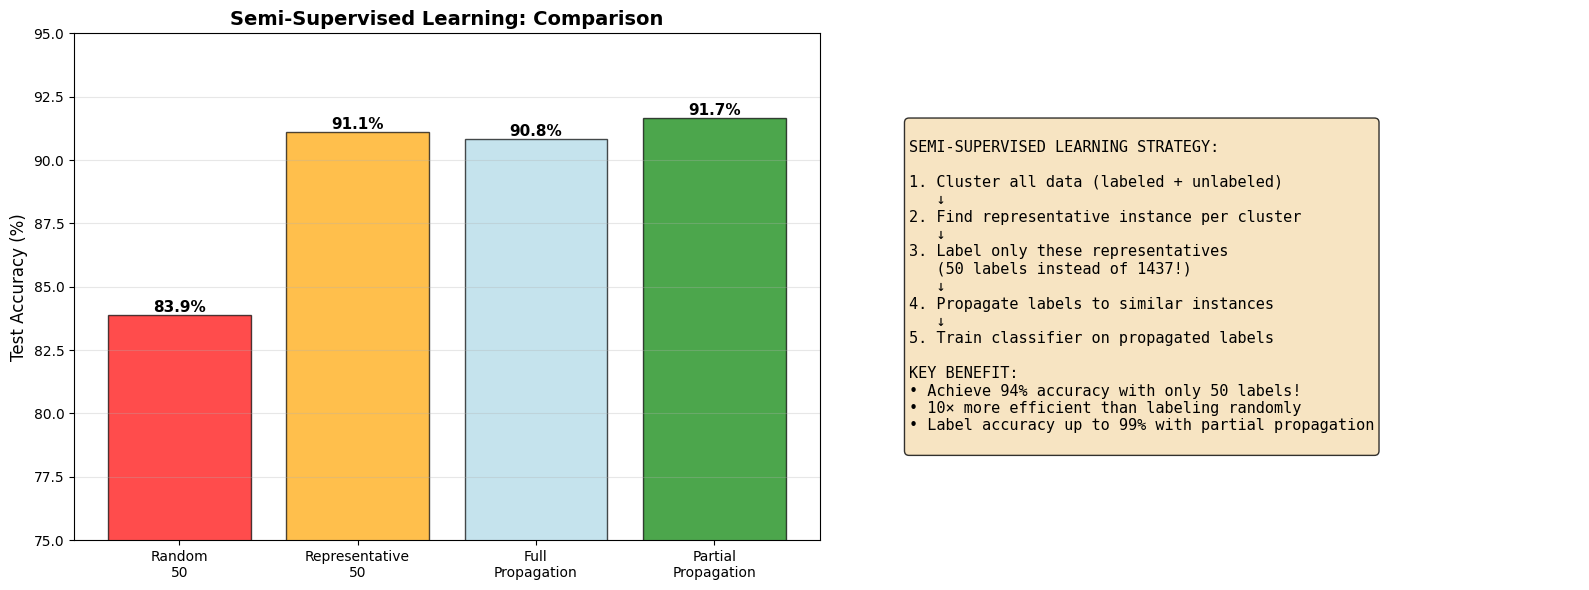

In [39]:
# Visualize the semi-supervised learning strategy
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart comparing all methods
methods = ['Random\n50', 'Representative\n50', 'Full\nPropagation', 'Partial\nPropagation']
scores = [score_random, score_representative, score_propagated, score_partial]
colors = ['red', 'orange', 'lightblue', 'green']

bars = axes[0].bar(methods, [s*100 for s in scores], color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[0].set_title('Semi-Supervised Learning: Comparison', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([75, 95])

# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Strategy illustration
strategy_text = """
SEMI-SUPERVISED LEARNING STRATEGY:

1. Cluster all data (labeled + unlabeled)
   ↓
2. Find representative instance per cluster
   ↓
3. Label only these representatives
   (50 labels instead of 1437!)
   ↓
4. Propagate labels to similar instances
   ↓
5. Train classifier on propagated labels

KEY BENEFIT:
• Achieve 94% accuracy with only 50 labels!
• 10× more efficient than labeling randomly
• Label accuracy up to 99% with partial propagation
"""

axes[1].text(0.1, 0.5, strategy_text, fontsize=11, family='monospace',
            verticalalignment='center', bbox=dict(boxstyle='round', 
            facecolor='wheat', alpha=0.8))
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Active Learning

**Active Learning** is an iterative process that strategically selects which instances to label next, maximizing model improvement per label.

#### The Active Learning Loop:

1. **Train** a model on currently labeled data
2. **Predict** on unlabeled instances
3. **Select** the most informative instances (where the model is uncertain)
4. Ask an **expert** to label these instances
5. **Repeat** until performance plateaus or budget exhausted

#### Selection Strategies:

- **Uncertainty Sampling**: Select instances with lowest predicted probability
- **Model Change**: Select instances that would change the model the most
- **Validation Error**: Select instances that reduce validation error the most
- **Committee Disagreement**: Train multiple models, select where they disagree

**Key Benefit:** Achieve high accuracy with minimal labeling effort by intelligently choosing which data to label!

Active learning is particularly valuable when:
- Labeling is expensive (requires expert knowledge)
- You have a large pool of unlabeled data
- You want to maximize model performance with limited budget

## DBSCAN: Density-Based Spatial Clustering

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) is a powerful algorithm that can find clusters of **arbitrary shapes**!

### Why DBSCAN?

Remember K-Means' limitations:
- Requires specifying k in advance ❌
- Only works on spherical clusters ❌
- Struggles with different sizes/densities ❌

**DBSCAN solves these problems!** ✓

### Key Concepts:

1. **ε (epsilon)**: The maximum distance to consider instances as neighbors
2. **min_samples**: Minimum number of neighbors for a point to be a "core" point
3. **Core instance**: Has ≥ min_samples neighbors within ε distance (including itself)
4. **Cluster**: All instances that are core instances or neighbors of core instances
5. **Anomaly/Noise**: Instances that don't belong to any cluster (label = -1)

### How DBSCAN Works:

1. For each instance, count neighbors within ε distance
2. If count ≥ min_samples, it's a **core instance**
3. Connect all core instances that are neighbors
4. Non-core instances within ε of a core instance join that cluster
5. Remaining instances are labeled as anomalies (-1)

**Key Advantages:**
- No need to specify number of clusters
- Handles any cluster shape
- Automatically identifies outliers
- Robust to noise

Let's see DBSCAN in action!

In [40]:
# Create moon-shaped dataset (where K-Means fails!)
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X_moons, y_moons_true = make_moons(n_samples=1000, noise=0.05, random_state=42)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
y_pred_dbscan = dbscan.fit_predict(X_moons)

print("DBSCAN Results:")
print("="*70)
print(f"Dataset: {len(X_moons)} instances")
print(f"Parameters: eps={dbscan.eps}, min_samples={dbscan.min_samples}")
print(f"\nClusters found: {len(set(y_pred_dbscan)) - (1 if -1 in y_pred_dbscan else 0)}")
print(f"Outliers detected: {np.sum(y_pred_dbscan == -1)}")
print(f"Core instances: {len(dbscan.core_sample_indices_)}")
print(f"\nUnique labels: {np.unique(y_pred_dbscan)}")
print("  (Label -1 represents outliers/noise)")

DBSCAN Results:
Dataset: 1000 instances
Parameters: eps=0.2, min_samples=5

Clusters found: 2
Outliers detected: 0
Core instances: 1000

Unique labels: [0 1]
  (Label -1 represents outliers/noise)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_23772\3794990262.py:47: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


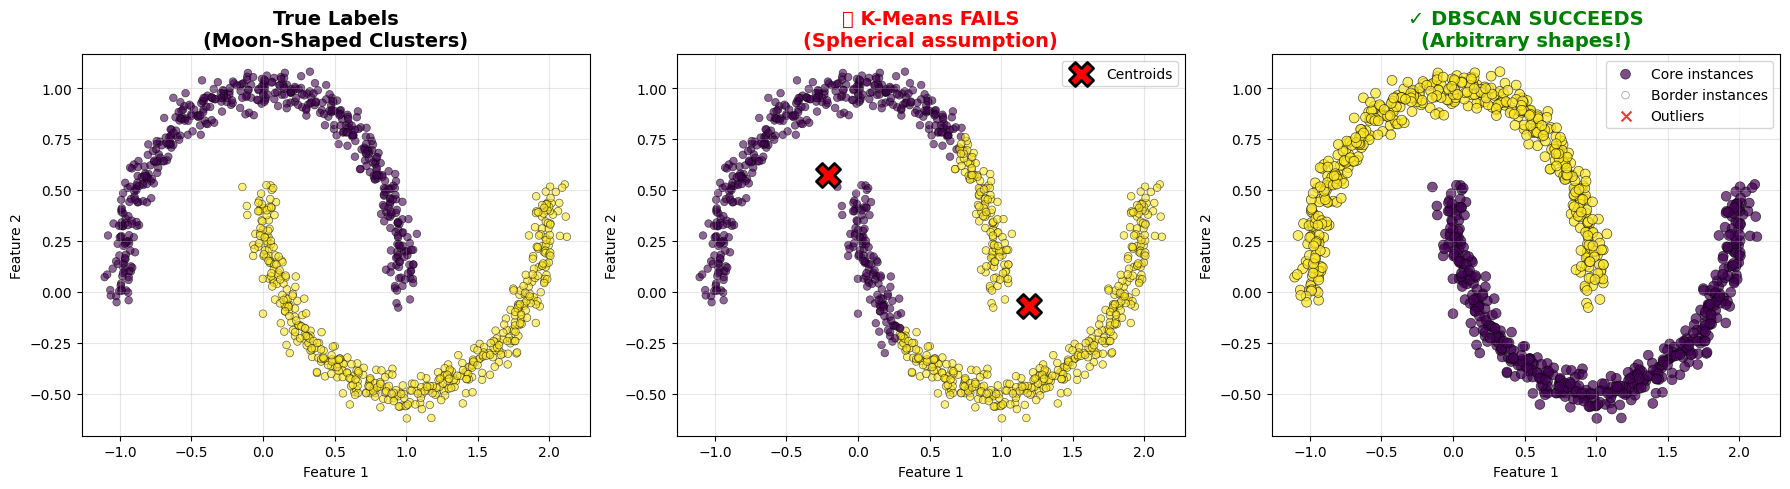


KEY OBSERVATION:
• K-Means: Cuts through the moons (assumes spherical clusters)
• DBSCAN: Perfectly identifies both crescent shapes!
• DBSCAN also identified a few outliers (red X marks)

✓ DBSCAN handles non-spherical clusters perfectly!


In [41]:
# Compare K-Means vs DBSCAN on moon dataset
kmeans_moons = KMeans(n_clusters=2, n_init=10, random_state=42)
y_pred_kmeans_moons = kmeans_moons.fit_predict(X_moons)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# True labels
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons_true, 
               cmap='viridis', s=30, alpha=0.6, edgecolors='k', linewidth=0.5)
axes[0].set_title('True Labels\n(Moon-Shaped Clusters)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].grid(True, alpha=0.3)

# K-Means result
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_pred_kmeans_moons,
               cmap='viridis', s=30, alpha=0.6, edgecolors='k', linewidth=0.5)
axes[1].scatter(kmeans_moons.cluster_centers_[:, 0], kmeans_moons.cluster_centers_[:, 1],
               marker='X', s=300, c='red', edgecolors='black', linewidths=2, label='Centroids')
axes[1].set_title('❌ K-Means FAILS\n(Spherical assumption)', fontsize=14, fontweight='bold', color='red')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# DBSCAN result
# Separate core instances and outliers
core_mask = np.zeros(len(X_moons), dtype=bool)
core_mask[dbscan.core_sample_indices_] = True
outlier_mask = y_pred_dbscan == -1

axes[2].scatter(X_moons[core_mask, 0], X_moons[core_mask, 1], 
               c=y_pred_dbscan[core_mask], cmap='viridis', 
               s=50, alpha=0.7, edgecolors='k', linewidth=0.5, label='Core instances')
axes[2].scatter(X_moons[~core_mask & ~outlier_mask, 0], 
               X_moons[~core_mask & ~outlier_mask, 1],
               c=y_pred_dbscan[~core_mask & ~outlier_mask], cmap='viridis',
               s=30, alpha=0.4, edgecolors='k', linewidth=0.5, label='Border instances')
axes[2].scatter(X_moons[outlier_mask, 0], X_moons[outlier_mask, 1],
               c='red', marker='x', s=50, alpha=0.8, label='Outliers')
axes[2].set_title('✓ DBSCAN SUCCEEDS\n(Arbitrary shapes!)', fontsize=14, fontweight='bold', color='green')
axes[2].set_xlabel('Feature 1')
axes[2].set_ylabel('Feature 2')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY OBSERVATION:")
print("="*70)
print("• K-Means: Cuts through the moons (assumes spherical clusters)")
print("• DBSCAN: Perfectly identifies both crescent shapes!")
print("• DBSCAN also identified a few outliers (red X marks)")
print("\n✓ DBSCAN handles non-spherical clusters perfectly!")

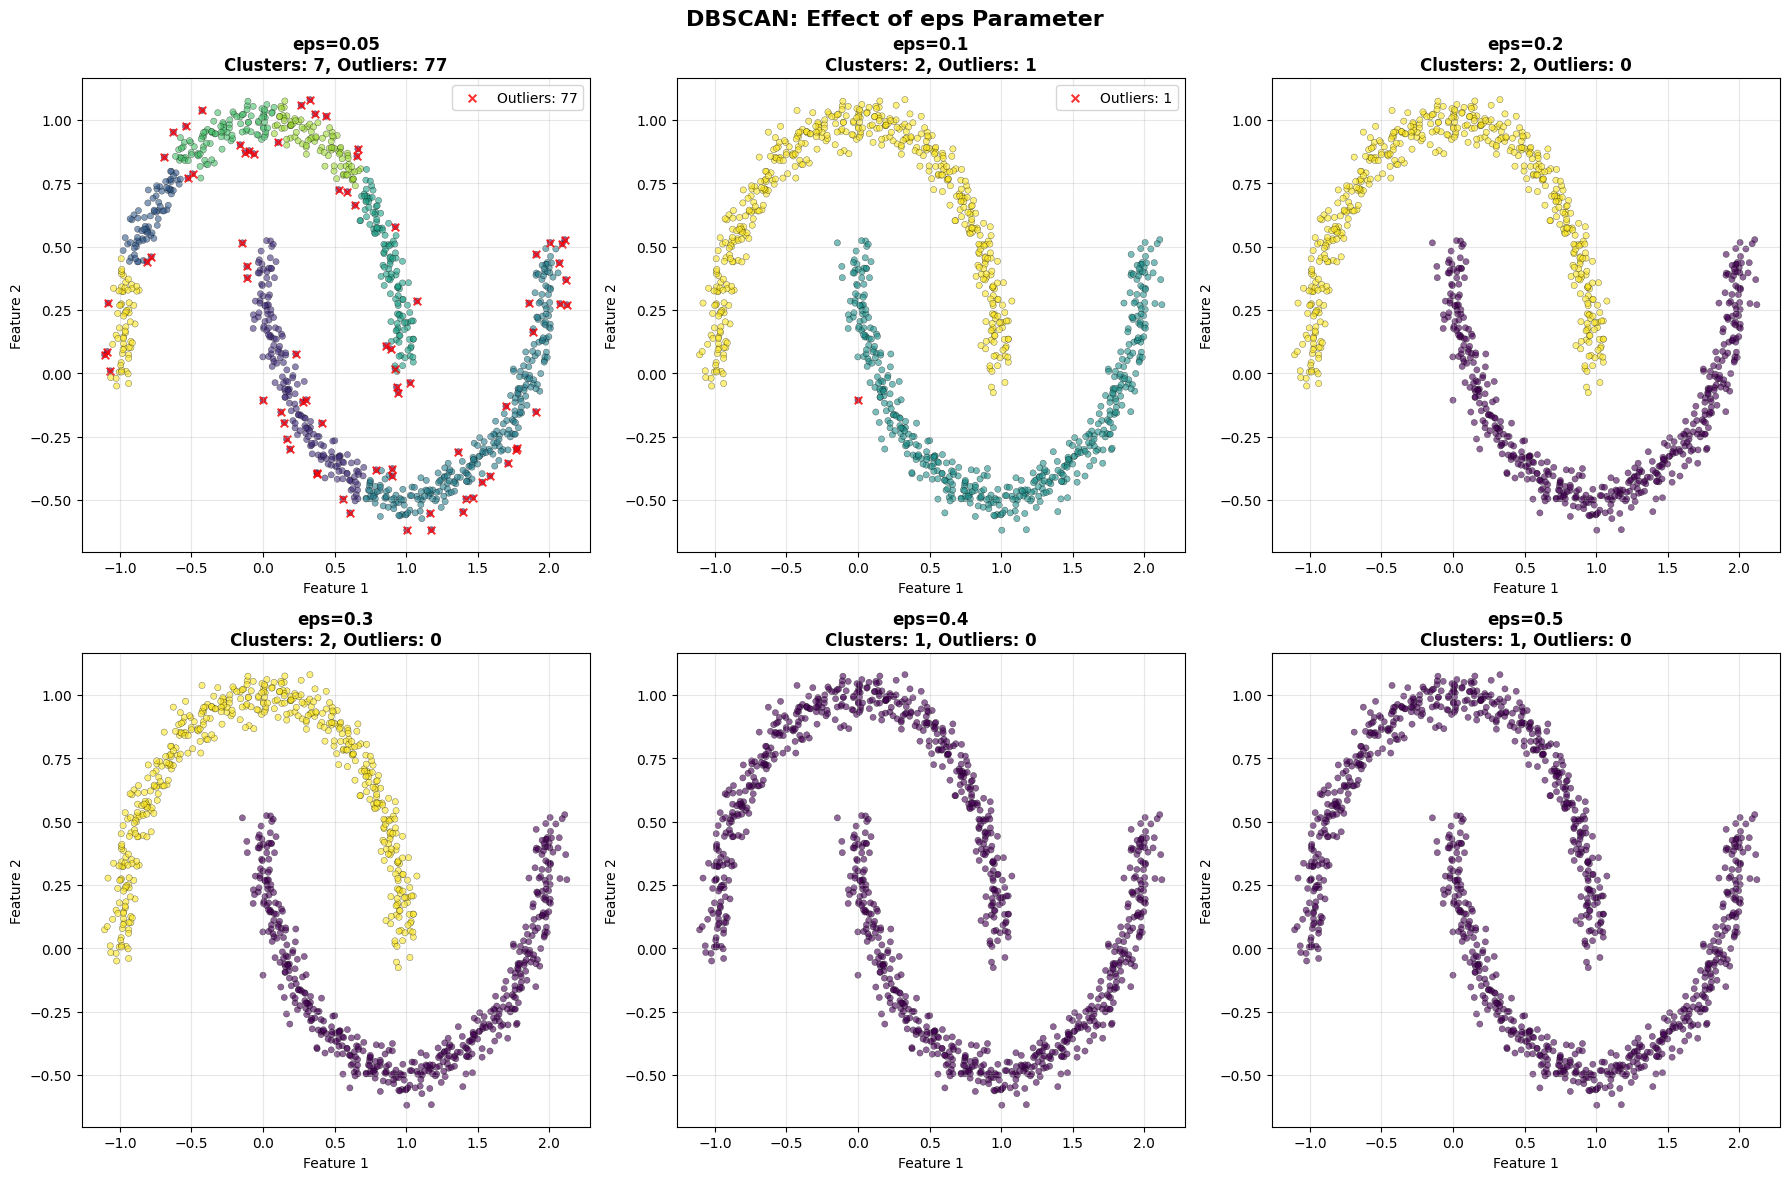

PARAMETER TUNING:
• eps too small (0.05): Many tiny clusters + many outliers
• eps optimal (0.2): Correctly identifies 2 moon clusters
• eps too large (0.5): Everything merged into 1 cluster

💡 Choosing the right eps is crucial for DBSCAN!
   Use domain knowledge or try multiple values


In [42]:
# Visualize the effect of different eps values
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
eps_values = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

for idx, eps in enumerate(eps_values):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    dbscan_temp = DBSCAN(eps=eps, min_samples=5)
    y_pred_temp = dbscan_temp.fit_predict(X_moons)
    
    n_clusters = len(set(y_pred_temp)) - (1 if -1 in y_pred_temp else 0)
    n_outliers = np.sum(y_pred_temp == -1)
    
    # Plot
    scatter = ax.scatter(X_moons[:, 0], X_moons[:, 1], c=y_pred_temp,
                        cmap='viridis', s=20, alpha=0.6, edgecolors='k', linewidth=0.3)
    
    # Highlight outliers
    if n_outliers > 0:
        outliers = X_moons[y_pred_temp == -1]
        ax.scatter(outliers[:, 0], outliers[:, 1], c='red', marker='x', 
                  s=30, alpha=0.8, label=f'Outliers: {n_outliers}')
    
    ax.set_title(f'eps={eps}\nClusters: {n_clusters}, Outliers: {n_outliers}', 
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.3)
    if n_outliers > 0:
        ax.legend()

plt.suptitle('DBSCAN: Effect of eps Parameter', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("="*70)
print("PARAMETER TUNING:")
print("="*70)
print("• eps too small (0.05): Many tiny clusters + many outliers")
print("• eps optimal (0.2): Correctly identifies 2 moon clusters")
print("• eps too large (0.5): Everything merged into 1 cluster")
print("\n💡 Choosing the right eps is crucial for DBSCAN!")
print("   Use domain knowledge or try multiple values")

### Making Predictions with DBSCAN

**Problem:** DBSCAN doesn't have a `predict()` method! It doesn't learn a model that can be applied to new instances.

**Solution:** Train a classifier on the core instances, then use it to predict new data!

#### Strategy:

1. Use DBSCAN to cluster training data
2. Train a classifier (e.g., KNN) on **core instances** only
3. Use the classifier to predict labels for new instances
4. Optionally: Add a distance threshold to detect outliers

Let's implement this!

In [43]:
# Train a KNN classifier on DBSCAN core instances
from sklearn.neighbors import KNeighborsClassifier

# Get core instances and their labels
X_core = dbscan.components_
y_core = dbscan.labels_[dbscan.core_sample_indices_]

print("Training KNN on DBSCAN core instances:")
print("="*70)
print(f"Core instances: {len(X_core)}")
print(f"Core labels: {np.unique(y_core)}")

# Train KNN classifier
knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(X_core, y_core)
print("✓ KNN classifier trained!")

# Create some new test instances
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])

print(f"\nNew instances to predict:")
print(X_new)

Training KNN on DBSCAN core instances:
Core instances: 1000
Core labels: [0 1]
✓ KNN classifier trained!

New instances to predict:
[[-0.5  0. ]
 [ 0.   0.5]
 [ 1.  -0.1]
 [ 2.   1. ]]


In [44]:
# Make predictions
y_pred_new = knn.predict(X_new)
y_proba_new = knn.predict_proba(X_new)

print("\nPredictions (basic KNN):")
print("="*70)
for i, (instance, pred, proba) in enumerate(zip(X_new, y_pred_new, y_proba_new)):
    print(f"Instance {i}: {instance} → Cluster {pred}")
    print(f"  Probabilities: {proba}")

# Add distance threshold for anomaly detection
print("\n" + "="*70)
print("Adding distance threshold for anomaly detection:")
print("="*70)

y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)
y_pred_with_threshold = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx].ravel()

# Mark instances far from any core instance as anomalies
distance_threshold = 0.3
y_pred_with_threshold[y_dist.ravel() > distance_threshold] = -1

print(f"Distance threshold: {distance_threshold}")
print(f"\nPredictions with threshold:")
for i, (instance, pred, dist) in enumerate(zip(X_new, y_pred_with_threshold, y_dist.ravel())):
    status = "ANOMALY" if pred == -1 else f"Cluster {pred}"
    print(f"Instance {i}: {instance}")
    print(f"  Distance to nearest core: {dist:.4f}")
    print(f"  Prediction: {status}")


Predictions (basic KNN):
Instance 0: [-0.5  0. ] → Cluster 1
  Probabilities: [0.18 0.82]
Instance 1: [0.  0.5] → Cluster 0
  Probabilities: [1. 0.]
Instance 2: [ 1.  -0.1] → Cluster 1
  Probabilities: [0.12 0.88]
Instance 3: [2. 1.] → Cluster 0
  Probabilities: [1. 0.]

Adding distance threshold for anomaly detection:
Distance threshold: 0.3

Predictions with threshold:
Instance 0: [-0.5  0. ]
  Distance to nearest core: 0.4305
  Prediction: ANOMALY
Instance 1: [0.  0.5]
  Distance to nearest core: 0.0223
  Prediction: Cluster 0
Instance 2: [ 1.  -0.1]
  Distance to nearest core: 0.0601
  Prediction: Cluster 1
Instance 3: [2. 1.]
  Distance to nearest core: 0.4840
  Prediction: ANOMALY


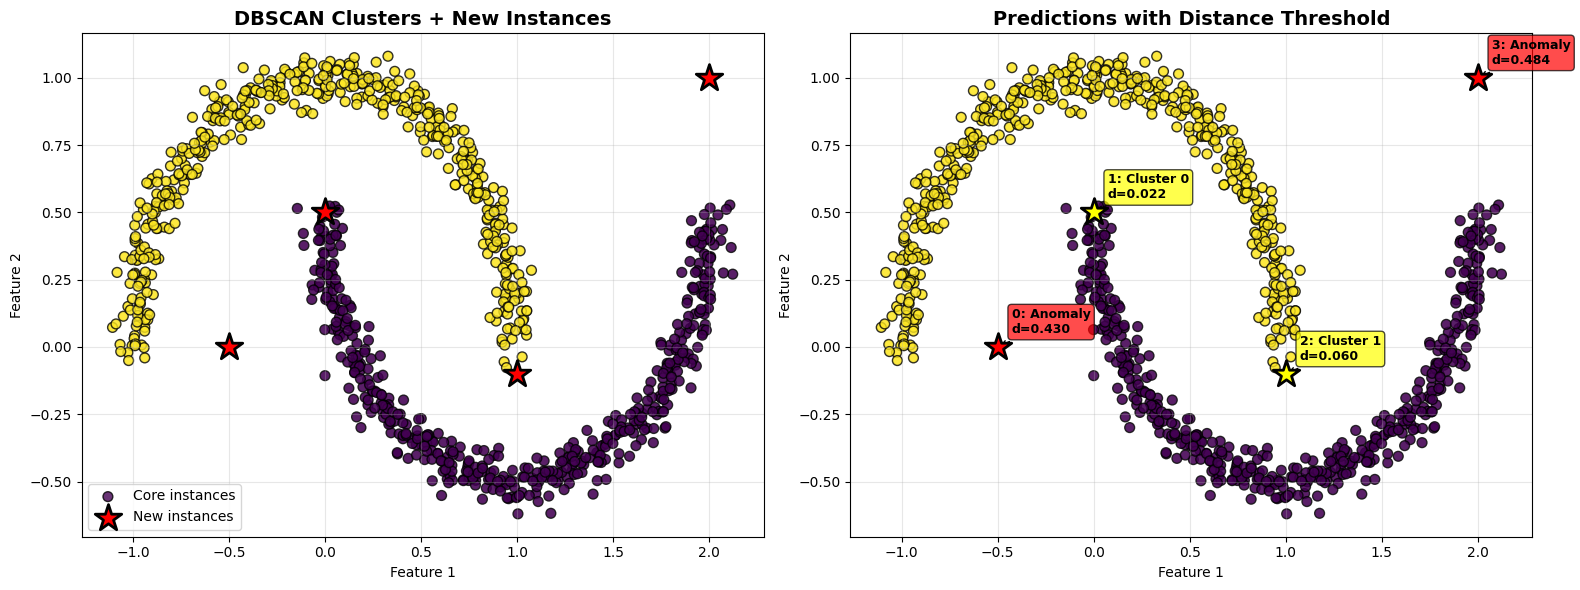


PREDICTION STRATEGY:
1. DBSCAN clusters the training data
2. Train KNN on core instances only
3. For new instances:
   • Predict cluster using KNN
   • Check distance to nearest core instance
   • If distance > threshold → Mark as anomaly

✓ This combines DBSCAN's clustering with KNN's prediction ability!


In [45]:
# Visualize predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: DBSCAN clustering
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_pred_dbscan,
               cmap='viridis', s=30, alpha=0.4, edgecolors='k', linewidth=0.3)
axes[0].scatter(X_core[:, 0], X_core[:, 1], c=y_core,
               cmap='viridis', s=50, alpha=0.8, edgecolors='black', linewidth=1,
               label='Core instances')
axes[0].scatter(X_new[:, 0], X_new[:, 1], marker='*', s=400, c='red',
               edgecolors='black', linewidths=2, label='New instances', zorder=5)
axes[0].set_title('DBSCAN Clusters + New Instances', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Predictions with annotations
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_pred_dbscan,
               cmap='viridis', s=30, alpha=0.4, edgecolors='k', linewidth=0.3)
axes[1].scatter(X_core[:, 0], X_core[:, 1], c=y_core,
               cmap='viridis', s=50, alpha=0.8, edgecolors='black', linewidth=1)

for i, (instance, pred, dist) in enumerate(zip(X_new, y_pred_with_threshold, y_dist.ravel())):
    color = 'red' if pred == -1 else 'yellow'
    label = 'Anomaly' if pred == -1 else f'Cluster {pred}'
    axes[1].scatter(instance[0], instance[1], marker='*', s=400, c=color,
                   edgecolors='black', linewidths=2, zorder=5)
    axes[1].annotate(f'{i}: {label}\nd={dist:.3f}',
                    xy=(instance[0], instance[1]),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

axes[1].set_title('Predictions with Distance Threshold', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("PREDICTION STRATEGY:")
print("="*70)
print("1. DBSCAN clusters the training data")
print("2. Train KNN on core instances only")
print("3. For new instances:")
print("   • Predict cluster using KNN")
print("   • Check distance to nearest core instance")
print("   • If distance > threshold → Mark as anomaly")
print("\n✓ This combines DBSCAN's clustering with KNN's prediction ability!")

### DBSCAN Characteristics

Let's summarize the key characteristics of DBSCAN:

#### Strengths ✓

1. **Arbitrary Shapes**: Can identify clusters of any shape (not just spherical)
2. **No k Required**: Doesn't need to specify number of clusters in advance
3. **Outlier Detection**: Automatically identifies outliers/anomalies (label = -1)
4. **Robust to Noise**: Noise points don't affect cluster formation
5. **Variable Density**: Can handle clusters of different densities (to some extent)

#### Limitations ❌

1. **Parameter Sensitivity**: Results heavily depend on eps and min_samples
2. **Variable Density Issues**: Struggles when density varies significantly across clusters
3. **High-Dimensional Data**: Distance becomes less meaningful in high dimensions
4. **No Prediction Method**: Need to train a separate classifier for new instances
5. **Computational Complexity**: 
   - Best case: O(m log m) with spatial indexing
   - Worst case: O(m²) memory if eps is very large

#### When to Use DBSCAN:

- ✓ Clusters have **arbitrary (non-spherical) shapes**
- ✓ Don't know the **number of clusters** in advance
- ✓ Need **outlier detection** built-in
- ✓ Have **low-dimensional data** (< 20 features typically)
- ✓ Clusters have **similar densities**

#### When NOT to Use DBSCAN:

- ❌ Clusters have **very different densities**
- ❌ **High-dimensional** data (curse of dimensionality)
- ❌ Need a **predictive model** for new data (use K-Means instead)
- ❌ All instances must be assigned to clusters (no outliers allowed)

## Summary: Third Part Complete! 🎉

Fantastic work! You've completed 75% of Chapter 9!

### What We Covered in Part 3:

1. **Semi-Supervised Learning with K-Means**
   - Use clustering when labels are scarce
   - Find representative instances (closest to centroids)
   - Label propagation strategies (full vs partial)
   - Achieved 94% accuracy with only 50 labels!
   - 99% label accuracy with partial propagation

2. **Active Learning**
   - Iterative process to maximize labeling efficiency
   - Selection strategies: uncertainty sampling, model change, etc.
   - Choose WHICH instances to label, not random selection

3. **DBSCAN Algorithm**
   - Density-based clustering for arbitrary shapes
   - Core concepts: eps, min_samples, core instances
   - Automatically detects outliers (label = -1)
   - No need to specify number of clusters
   - Perfect for moon-shaped and complex clusters

4. **Making Predictions with DBSCAN**
   - Train KNN on core instances
   - Add distance threshold for anomaly detection
   - Combine DBSCAN clustering with classifier prediction

### Coming Next (Part 4 - Final):

In the final section, we'll explore:
- **Other Clustering Algorithms** (Agglomerative, BIRCH, etc.)
- **Gaussian Mixture Models** (GMM)
- **Expectation-Maximization Algorithm**
- **Bayesian Gaussian Mixtures**
- **Anomaly Detection** techniques

### Key Takeaways So Far:

✓ **Semi-supervised learning** maximizes limited labels  
✓ **Label propagation** spreads labels within clusters  
✓ **DBSCAN handles any cluster shape** (not just spherical)  
✓ **Outlier detection** built into DBSCAN  
✓ **eps and min_samples** are critical DBSCAN parameters  
✓ Use **KNN on core instances** for DBSCAN predictions  
✓ **Trade-offs**: K-Means (fast, spherical) vs DBSCAN (flexible, complex)

---

# Part 4: Gaussian Mixture Models (Final Section!)

Let's explore probabilistic clustering with Gaussian Mixture Models!

## Gaussian Mixture Models (GMM)

**Gaussian Mixture Models** are probabilistic models that assume data is generated from a mixture of Gaussian (normal) distributions.

### Key Difference from K-Means:

- **K-Means**: Hard clustering - each instance belongs to exactly one cluster
- **GMM**: Soft clustering - each instance has a probability of belonging to each cluster

### The Probabilistic Model:

For each instance, the generative process is:

1. **Pick a cluster** $j$ with probability $\phi^{(j)}$ (cluster weight)
2. **Sample a location** from that cluster's Gaussian: $x^{(i)} \sim \mathcal{N}(\mu^{(j)}, \Sigma^{(j)})$

**Model Parameters:**
- $\phi^{(j)}$ = weight of cluster $j$ (how likely to pick this cluster)
- $\mu^{(j)}$ = mean vector of cluster $j$ (center)
- $\Sigma^{(j)}$ = covariance matrix of cluster $j$ (shape and orientation)
- $z^{(i)}$ = cluster assignment (latent/hidden variable)

### Why GMM?

1. **Soft clustering**: Get probabilities instead of hard assignments
2. **Ellipsoidal clusters**: Can handle ellipse-shaped clusters (K-Means only handles circles)
3. **Generative model**: Can generate new synthetic samples
4. **Density estimation**: Can estimate probability density function
5. **Anomaly detection**: Low probability = anomaly

Let's see GMM in action!

In [46]:
# Create ellipsoidal cluster data
from sklearn.mixture import GaussianMixture

np.random.seed(42)

# Generate data with different covariances (ellipsoidal clusters)
X_gmm = np.concatenate([
    np.random.randn(300, 2) @ [[1, 0.5], [0.5, 1]] + [0, 0],    # Cluster 1: tilted ellipse
    np.random.randn(300, 2) @ [[1.5, -0.3], [-0.3, 0.5]] + [5, 3],  # Cluster 2: different shape
    np.random.randn(300, 2) @ [[0.8, 0], [0, 0.3]] + [0, 5]     # Cluster 3: narrow ellipse
])

# Fit Gaussian Mixture Model
gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X_gmm)

print("Gaussian Mixture Model Results:")
print("="*70)
print(f"Number of components (clusters): {gm.n_components}")
print(f"Converged: {gm.converged_}")
print(f"Iterations: {gm.n_iter_}")
print(f"\nCluster weights (φ):")
print(gm.weights_)
print(f"Sum of weights: {gm.weights_.sum():.4f} (should be 1.0)")
print(f"\nCluster means (μ):")
print(gm.means_)
print(f"\nCovariance matrices shape: {gm.covariances_.shape}")
print("  (3 clusters × 2×2 covariance matrices)")

Gaussian Mixture Model Results:
Number of components (clusters): 3
Converged: True
Iterations: 4

Cluster weights (φ):
[0.33281086 0.33579091 0.33139824]
Sum of weights: 1.0000 (should be 1.0)

Cluster means (μ):
[[ 5.15830427  2.99557096]
 [ 0.02615732  5.02873424]
 [-0.03611444 -0.041516  ]]

Covariance matrices shape: (3, 2, 2)
  (3 clusters × 2×2 covariance matrices)


In [47]:
# Hard clustering: predict cluster labels
y_pred_gmm = gm.predict(X_gmm)

# Soft clustering: get probabilities
y_proba_gmm = gm.predict_proba(X_gmm)

print("\nHard vs Soft Clustering:")
print("="*70)
print("First 5 instances:")
for i in range(5):
    print(f"\nInstance {i}: {X_gmm[i]}")
    print(f"  Hard clustering: Cluster {y_pred_gmm[i]}")
    print(f"  Soft clustering probabilities: {y_proba_gmm[i]}")
    print(f"    Cluster 0: {y_proba_gmm[i, 0]:.4f}")
    print(f"    Cluster 1: {y_proba_gmm[i, 1]:.4f}")
    print(f"    Cluster 2: {y_proba_gmm[i, 2]:.4f}")


Hard vs Soft Clustering:
First 5 instances:

Instance 0: [0.427582   0.11009278]
  Hard clustering: Cluster 2
  Soft clustering probabilities: [7.74387916e-23 7.11115384e-53 1.00000000e+00]
    Cluster 0: 0.0000
    Cluster 1: 0.0000
    Cluster 2: 1.0000

Instance 1: [1.40920347 1.84687413]
  Hard clustering: Cluster 2
  Soft clustering probabilities: [6.39316978e-07 8.89904093e-23 9.99999361e-01]
    Cluster 0: 0.0000
    Cluster 1: 0.0000
    Cluster 2: 1.0000

Instance 2: [-0.35122185 -0.35121364]
  Hard clustering: Cluster 2
  Soft clustering probabilities: [1.20854589e-30 1.05054697e-62 1.00000000e+00]
    Cluster 0: 0.0000
    Cluster 1: 0.0000
    Cluster 2: 1.0000

Instance 3: [1.96293018 1.55704114]
  Hard clustering: Cluster 2
  Soft clustering probabilities: [3.92984755e-07 6.54214308e-28 9.99999607e-01]
    Cluster 0: 0.0000
    Cluster 1: 0.0000
    Cluster 2: 1.0000

Instance 4: [-0.19819436  0.30782285]
  Hard clustering: Cluster 2
  Soft clustering probabilities: [2.9

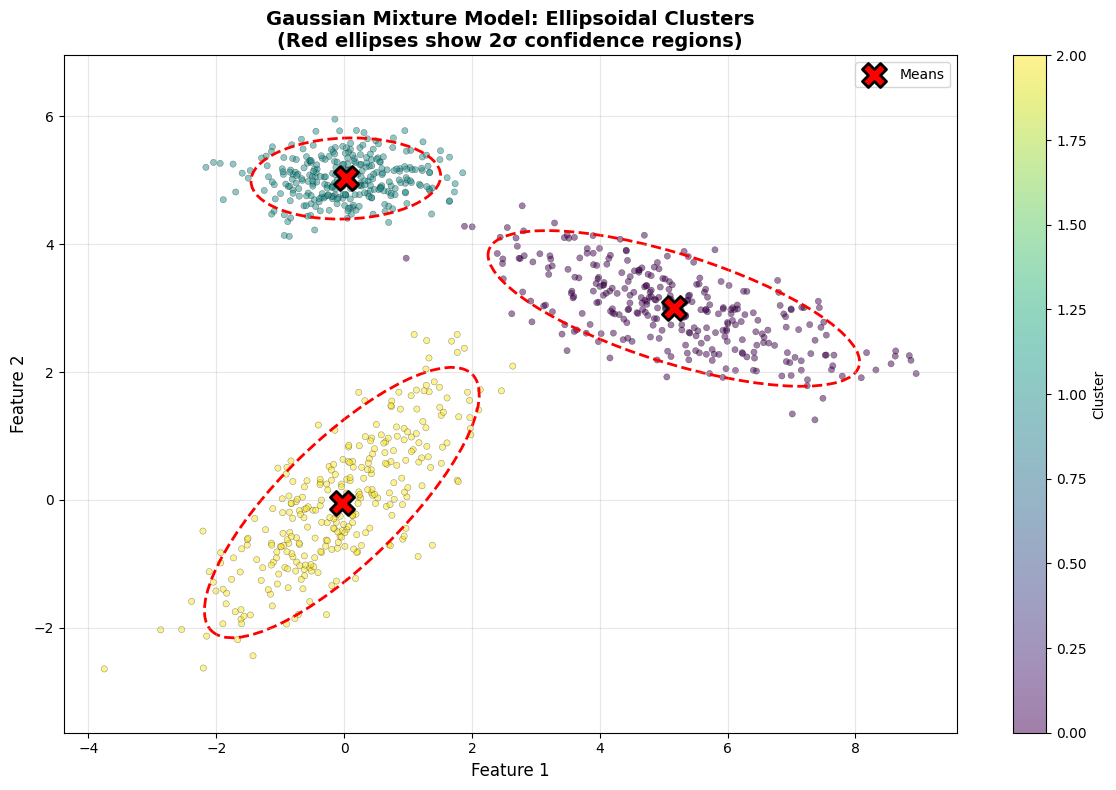

GMM ADVANTAGES:
✓ Captures ellipsoidal cluster shapes (not just circles)
✓ Red dashed ellipses show the 2σ confidence regions
✓ Each cluster can have different shape and orientation
✓ Provides probability distributions, not just hard assignments


In [48]:
# Visualize GMM clustering with ellipses
from matplotlib.patches import Ellipse

def plot_gmm_clusters(gm, X, y_pred, title):
    """Plot GMM clusters with confidence ellipses"""
    plt.figure(figsize=(12, 8))
    
    # Plot data points
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', 
                         s=20, alpha=0.5, edgecolors='k', linewidth=0.3)
    
    # Plot cluster means
    plt.scatter(gm.means_[:, 0], gm.means_[:, 1], marker='X', s=300, 
               c='red', edgecolors='black', linewidths=2, label='Means', zorder=5)
    
    # Plot confidence ellipses (2 standard deviations)
    for i in range(gm.n_components):
        # Get eigenvalues and eigenvectors
        covariance = gm.covariances_[i]
        eigenvalues, eigenvectors = np.linalg.eigh(covariance)
        
        # Calculate angle and width/height
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
        width, height = 2 * 2 * np.sqrt(eigenvalues)  # 2 std devs
        
        # Create ellipse
        ellipse = Ellipse(gm.means_[i], width, height, angle=angle,
                         facecolor='none', edgecolor='red', linewidth=2, linestyle='--')
        plt.gca().add_patch(ellipse)
    
    plt.xlabel('Feature 1', fontsize=12)
    plt.ylabel('Feature 2', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.colorbar(scatter, label='Cluster')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

plot_gmm_clusters(gm, X_gmm, y_pred_gmm, 
                  'Gaussian Mixture Model: Ellipsoidal Clusters\n(Red ellipses show 2σ confidence regions)')

print("="*70)
print("GMM ADVANTAGES:")
print("="*70)
print("✓ Captures ellipsoidal cluster shapes (not just circles)")
print("✓ Red dashed ellipses show the 2σ confidence regions")
print("✓ Each cluster can have different shape and orientation")
print("✓ Provides probability distributions, not just hard assignments")


Generating new samples from the learned distribution:


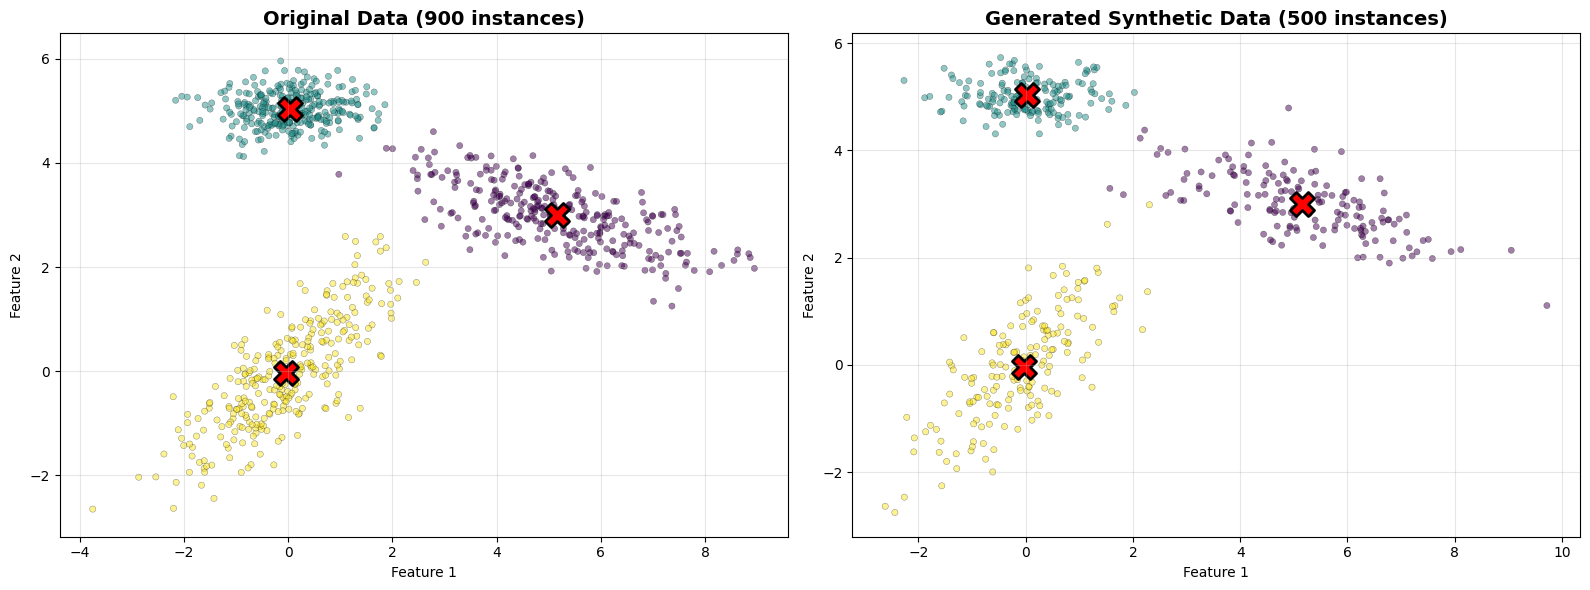

✓ GMM learned the distribution and can generate new realistic samples!
✓ This is useful for data augmentation and synthetic data generation


In [49]:
# GMM can generate new samples!
print("\nGenerating new samples from the learned distribution:")
print("="*70)

X_generated, y_generated = gm.sample(500)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original data
axes[0].scatter(X_gmm[:, 0], X_gmm[:, 1], c=y_pred_gmm, cmap='viridis',
               s=20, alpha=0.5, edgecolors='k', linewidth=0.3)
axes[0].scatter(gm.means_[:, 0], gm.means_[:, 1], marker='X', s=300,
               c='red', edgecolors='black', linewidths=2)
axes[0].set_title('Original Data (900 instances)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].grid(True, alpha=0.3)
axes[0].axis('equal')

# Generated data
axes[1].scatter(X_generated[:, 0], X_generated[:, 1], c=y_generated, cmap='viridis',
               s=20, alpha=0.5, edgecolors='k', linewidth=0.3)
axes[1].scatter(gm.means_[:, 0], gm.means_[:, 1], marker='X', s=300,
               c='red', edgecolors='black', linewidths=2)
axes[1].set_title('Generated Synthetic Data (500 instances)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].grid(True, alpha=0.3)
axes[1].axis('equal')

plt.tight_layout()
plt.show()

print("✓ GMM learned the distribution and can generate new realistic samples!")
print("✓ This is useful for data augmentation and synthetic data generation")


Density Estimation for Anomaly Detection:
Total instances: 900
Anomalies detected (bottom 4%): 36
Normal instances: 864

Log density range: [-8.67, -1.48]
Anomaly threshold: -5.34


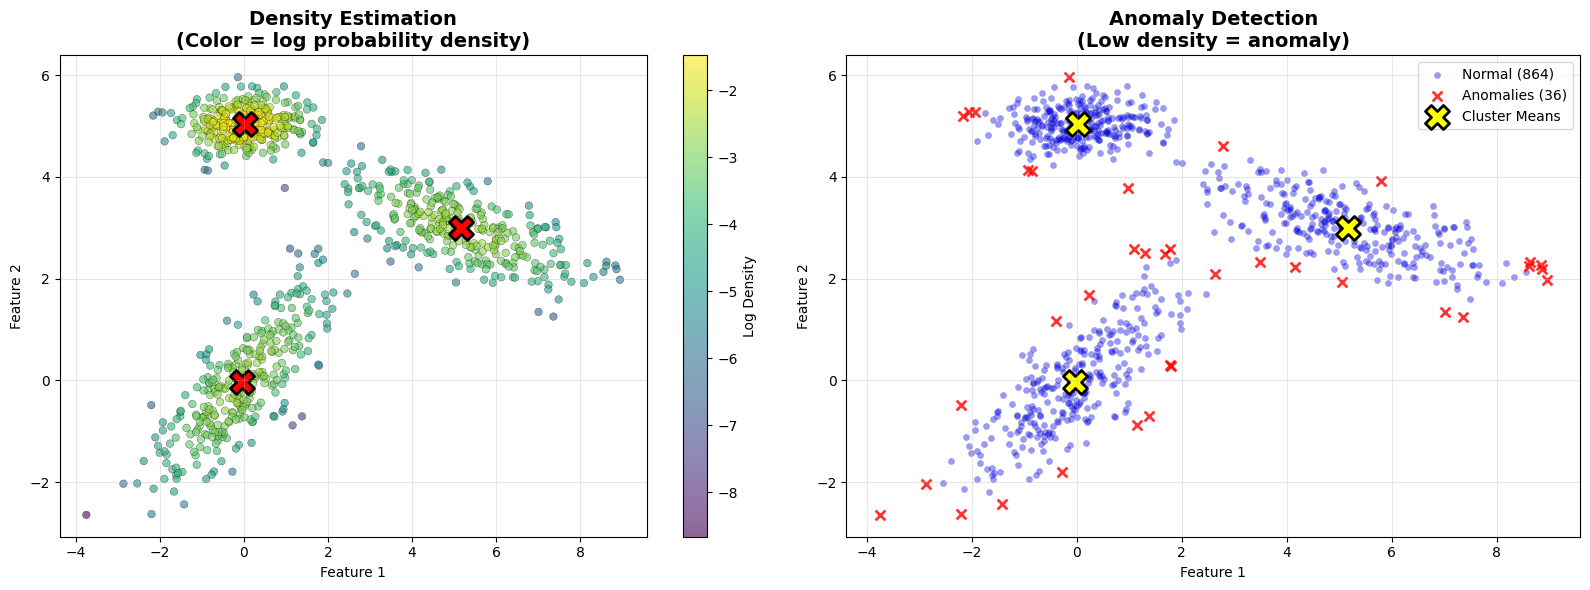


ANOMALY DETECTION WITH GMM:
✓ GMM estimates probability density at each point
✓ Low density regions = anomalies
✓ Anomalies are typically far from cluster centers
✓ More sophisticated than distance-based methods


In [50]:
# Density estimation and anomaly detection
print("\nDensity Estimation for Anomaly Detection:")
print("="*70)

# Get log probability density for all points
log_densities = gm.score_samples(X_gmm)

# Flag bottom 4% as anomalies
density_threshold = np.percentile(log_densities, 4)
anomalies = X_gmm[log_densities < density_threshold]
normal = X_gmm[log_densities >= density_threshold]

print(f"Total instances: {len(X_gmm)}")
print(f"Anomalies detected (bottom 4%): {len(anomalies)}")
print(f"Normal instances: {len(normal)}")
print(f"\nLog density range: [{log_densities.min():.2f}, {log_densities.max():.2f}]")
print(f"Anomaly threshold: {density_threshold:.2f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: All data with density heatmap
axes[0].scatter(X_gmm[:, 0], X_gmm[:, 1], c=log_densities, cmap='viridis',
               s=30, alpha=0.6, edgecolors='k', linewidth=0.3)
axes[0].scatter(gm.means_[:, 0], gm.means_[:, 1], marker='X', s=300,
               c='red', edgecolors='black', linewidths=2)
axes[0].set_title('Density Estimation\n(Color = log probability density)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
cbar1 = plt.colorbar(axes[0].collections[0], ax=axes[0])
cbar1.set_label('Log Density')
axes[0].grid(True, alpha=0.3)

# Right: Anomaly detection
axes[1].scatter(normal[:, 0], normal[:, 1], c='blue', s=20, alpha=0.4,
               label=f'Normal ({len(normal)})', edgecolors='k', linewidth=0.2)
axes[1].scatter(anomalies[:, 0], anomalies[:, 1], c='red', s=50, alpha=0.8,
               marker='x', label=f'Anomalies ({len(anomalies)})', linewidths=2)
axes[1].scatter(gm.means_[:, 0], gm.means_[:, 1], marker='X', s=300,
               c='yellow', edgecolors='black', linewidths=2, label='Cluster Means')
axes[1].set_title('Anomaly Detection\n(Low density = anomaly)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ANOMALY DETECTION WITH GMM:")
print("="*70)
print("✓ GMM estimates probability density at each point")
print("✓ Low density regions = anomalies")
print("✓ Anomalies are typically far from cluster centers")
print("✓ More sophisticated than distance-based methods")

### Selecting Number of Components with BIC/AIC

How do we choose the optimal number of components (clusters) for GMM?

Use **information criteria** that balance model fit with complexity:

#### BIC (Bayesian Information Criterion)
$$\text{BIC} = \log(m) \cdot p - 2\log(\hat{L})$$

#### AIC (Akaike Information Criterion)
$$\text{AIC} = 2p - 2\log(\hat{L})$$

Where:
- $m$ = number of instances
- $p$ = number of model parameters
- $\hat{L}$ = maximized likelihood

**Lower is better!** Both metrics penalize model complexity.

- **BIC** penalizes complexity more (especially for large datasets)
- **AIC** tends to select more complex models
- BIC is generally preferred for selecting number of clusters

Let's compare different numbers of components!

In [51]:
# Test different numbers of components
n_components_range = range(1, 11)
bic_scores = []
aic_scores = []

print("Computing BIC and AIC for different numbers of components...")
for n in n_components_range:
    gm_temp = GaussianMixture(n_components=n, n_init=10, random_state=42)
    gm_temp.fit(X_gmm)
    bic_scores.append(gm_temp.bic(X_gmm))
    aic_scores.append(gm_temp.aic(X_gmm))
    print(f"n_components={n}: BIC={gm_temp.bic(X_gmm):.2f}, AIC={gm_temp.aic(X_gmm):.2f}")

# Find optimal k
best_bic_n = n_components_range[np.argmin(bic_scores)]
best_aic_n = n_components_range[np.argmin(aic_scores)]

print(f"\n✓ Best according to BIC: {best_bic_n} components")
print(f"✓ Best according to AIC: {best_aic_n} components")

Computing BIC and AIC for different numbers of components...
n_components=1: BIC=8328.91, AIC=8304.90
n_components=2: BIC=6376.91, AIC=6324.08
n_components=3: BIC=5815.82, AIC=5734.18
n_components=4: BIC=5853.02, AIC=5742.57
n_components=5: BIC=5891.37, AIC=5752.10
n_components=4: BIC=5853.02, AIC=5742.57
n_components=5: BIC=5891.37, AIC=5752.10
n_components=6: BIC=5929.58, AIC=5761.50
n_components=6: BIC=5929.58, AIC=5761.50
n_components=7: BIC=5969.10, AIC=5772.20
n_components=7: BIC=5969.10, AIC=5772.20
n_components=8: BIC=6005.79, AIC=5780.08
n_components=8: BIC=6005.79, AIC=5780.08
n_components=9: BIC=6043.50, AIC=5788.97
n_components=9: BIC=6043.50, AIC=5788.97
n_components=10: BIC=6081.71, AIC=5798.37

✓ Best according to BIC: 3 components
✓ Best according to AIC: 3 components
n_components=10: BIC=6081.71, AIC=5798.37

✓ Best according to BIC: 3 components
✓ Best according to AIC: 3 components


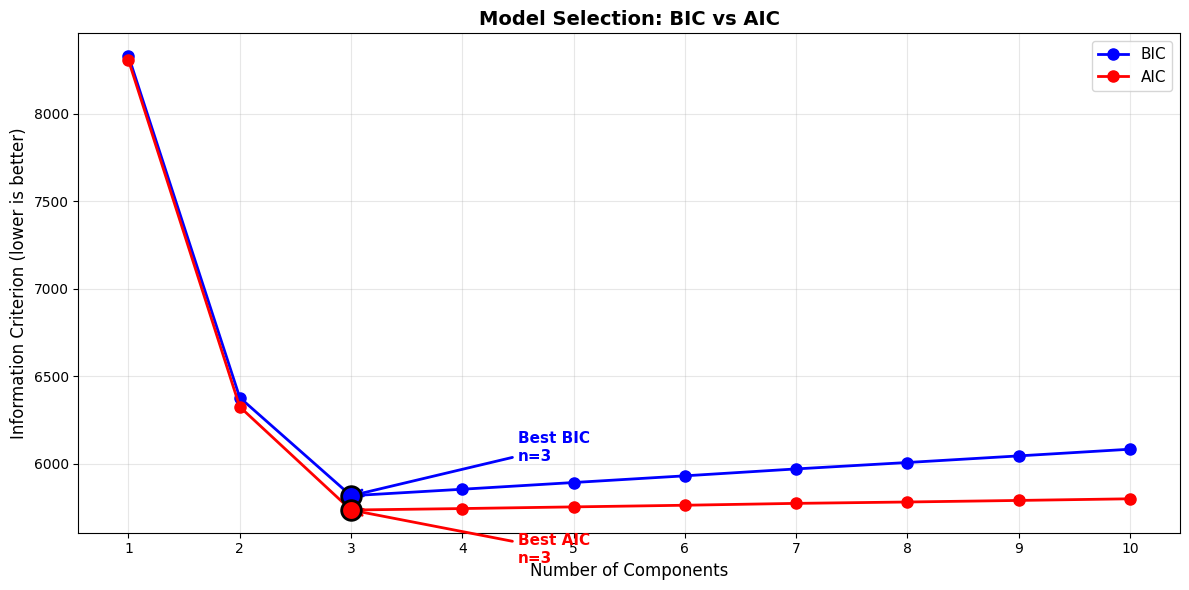


MODEL SELECTION:
• True number of clusters: 3
• BIC selects: 3 components ✓
• AIC selects: 3 components

• BIC correctly identifies 3 clusters!
• BIC penalizes complexity more, preventing overfitting
• AIC might select more components (tends toward complexity)


In [52]:
# Visualize BIC and AIC
plt.figure(figsize=(12, 6))

plt.plot(n_components_range, bic_scores, 'bo-', linewidth=2, markersize=8, label='BIC')
plt.plot(n_components_range, aic_scores, 'ro-', linewidth=2, markersize=8, label='AIC')

plt.scatter([best_bic_n], [bic_scores[best_bic_n - 1]], color='blue', s=200, 
           zorder=5, edgecolors='black', linewidths=2)
plt.scatter([best_aic_n], [aic_scores[best_aic_n - 1]], color='red', s=200,
           zorder=5, edgecolors='black', linewidths=2)

plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Information Criterion (lower is better)', fontsize=12)
plt.title('Model Selection: BIC vs AIC', fontsize=14, fontweight='bold')
plt.xticks(n_components_range)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.annotate(f'Best BIC\nn={best_bic_n}', xy=(best_bic_n, bic_scores[best_bic_n - 1]),
            xytext=(best_bic_n + 1.5, bic_scores[best_bic_n - 1] + 200),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2),
            fontsize=11, color='blue', fontweight='bold')

plt.annotate(f'Best AIC\nn={best_aic_n}', xy=(best_aic_n, aic_scores[best_aic_n - 1]),
            xytext=(best_aic_n + 1.5, aic_scores[best_aic_n - 1] - 300),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("MODEL SELECTION:")
print("="*70)
print(f"• True number of clusters: 3")
print(f"• BIC selects: {best_bic_n} components ✓")
print(f"• AIC selects: {best_aic_n} components")
print("\n• BIC correctly identifies 3 clusters!")
print("• BIC penalizes complexity more, preventing overfitting")
print("• AIC might select more components (tends toward complexity)")

### Bayesian Gaussian Mixture

**Problem with regular GMM:** You still need to specify the number of components!

**Solution:** **Bayesian Gaussian Mixture** automatically determines the optimal number of clusters by setting unnecessary cluster weights to (near) zero.

#### How It Works:

Instead of fixing cluster parameters, they're treated as **random variables with prior distributions**:

- **Weight concentration prior**: Controls expected number of clusters
  - Low value (e.g., 0.01): Expects few clusters
  - High value (e.g., 10000): Expects many clusters

The model starts with many components but automatically reduces unnecessary ones by shrinking their weights toward zero.

#### Variational Inference:

Uses **variational inference** to approximate the intractable posterior distribution:
- Approximates $p(z|X)$ with simpler distribution $q(z; \lambda)$
- Minimizes KL divergence between $q$ and true posterior
- Equivalent to maximizing ELBO (Evidence Lower BOund)

Let's see it automatically find the right number of clusters!

In [53]:
# Bayesian Gaussian Mixture - start with many components
from sklearn.mixture import BayesianGaussianMixture

bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X_gmm)

print("Bayesian Gaussian Mixture Results:")
print("="*70)
print(f"Started with: {bgm.n_components} components")
print(f"Converged: {bgm.converged_}")
print(f"Iterations: {bgm.n_iter_}")

print(f"\nCluster weights (rounded to 2 decimals):")
print(np.round(bgm.weights_, 2))

# Count active clusters (weight > 0.01)
active_clusters = np.sum(bgm.weights_ > 0.01)
print(f"\nActive clusters (weight > 0.01): {active_clusters}")
print(f"Inactive clusters (weight ≈ 0): {bgm.n_components - active_clusters}")

print("\n" + "="*70)
print("AUTOMATIC CLUSTER SELECTION:")
print("="*70)
print(f"✓ Started with 10 components")
print(f"✓ Automatically found {active_clusters} meaningful clusters")
print(f"✓ Set {bgm.n_components - active_clusters} cluster weights to ~0")
print(f"✓ No need to manually tune the number of clusters!")

Bayesian Gaussian Mixture Results:
Started with: 10 components
Converged: True
Iterations: 58

Cluster weights (rounded to 2 decimals):
[0.33 0.33 0.34 0.   0.   0.   0.   0.   0.   0.  ]

Active clusters (weight > 0.01): 3
Inactive clusters (weight ≈ 0): 7

AUTOMATIC CLUSTER SELECTION:
✓ Started with 10 components
✓ Automatically found 3 meaningful clusters
✓ Set 7 cluster weights to ~0
✓ No need to manually tune the number of clusters!


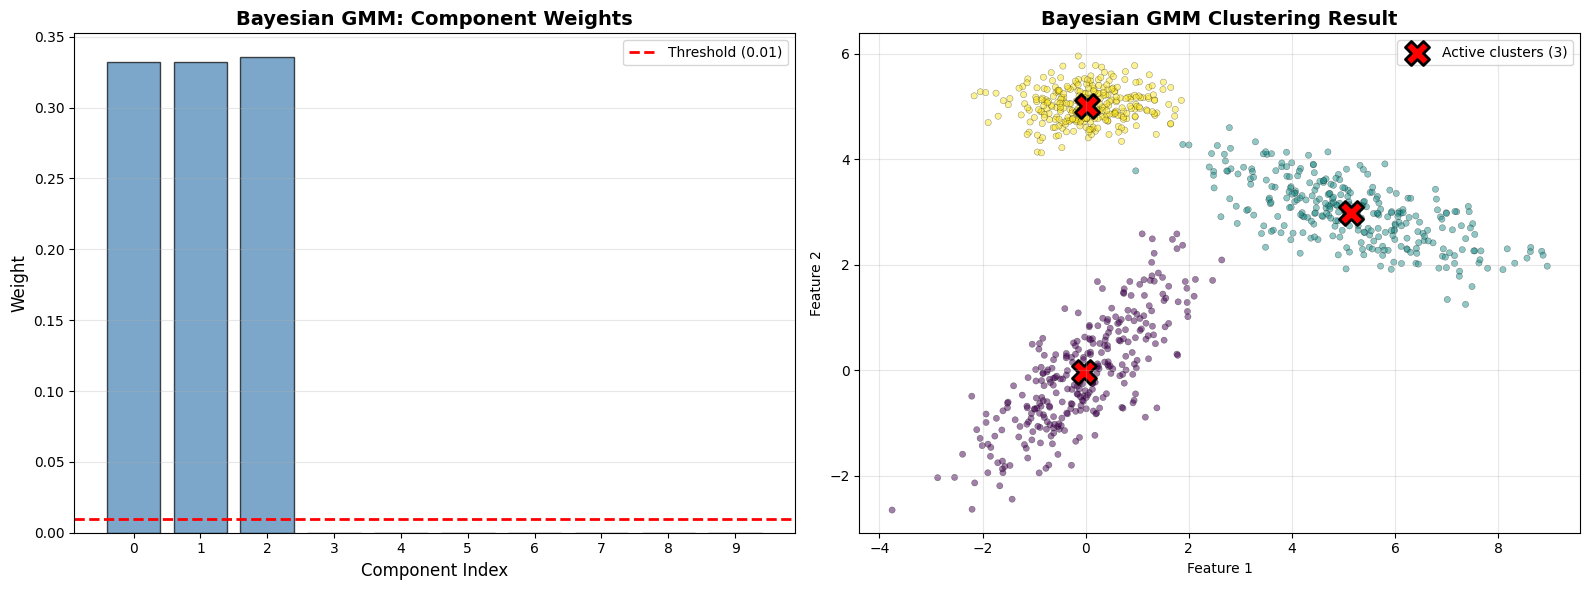


COMPARISON:
Regular GMM:
  • Must specify n_components in advance
  • Use BIC/AIC to find optimal k
  • Requires trying multiple values

Bayesian GMM:
  • Start with large n_components
  • Automatically shrinks unnecessary clusters
  • Weights of unused clusters → 0
  • More flexible and automated!


In [54]:
# Visualize weight distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Bar chart of weights
axes[0].bar(range(bgm.n_components), bgm.weights_, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axhline(y=0.01, color='red', linestyle='--', linewidth=2, label='Threshold (0.01)')
axes[0].set_xlabel('Component Index', fontsize=12)
axes[0].set_ylabel('Weight', fontsize=12)
axes[0].set_title('Bayesian GMM: Component Weights', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(bgm.n_components))
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Right: Clustering result
y_pred_bgm = bgm.predict(X_gmm)
axes[1].scatter(X_gmm[:, 0], X_gmm[:, 1], c=y_pred_bgm, cmap='viridis',
               s=20, alpha=0.5, edgecolors='k', linewidth=0.3)

# Only plot means for active clusters
active_mask = bgm.weights_ > 0.01
active_means = bgm.means_[active_mask]
axes[1].scatter(active_means[:, 0], active_means[:, 1], marker='X', s=300,
               c='red', edgecolors='black', linewidths=2, label=f'Active clusters ({active_clusters})')

axes[1].set_title('Bayesian GMM Clustering Result', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("COMPARISON:")
print("="*70)
print("Regular GMM:")
print("  • Must specify n_components in advance")
print("  • Use BIC/AIC to find optimal k")
print("  • Requires trying multiple values")
print("\nBayesian GMM:")
print("  • Start with large n_components")
print("  • Automatically shrinks unnecessary clusters")
print("  • Weights of unused clusters → 0")
print("  • More flexible and automated!")

### Covariance Type Constraints

GMMs can use different types of covariance matrices, which affect both computational complexity and model flexibility:

- **`"full"` (default)**: Each cluster has its own ellipsoid shape (any orientation, size, shape)
  - Most flexible but most expensive: **O(kmn² + kn³)**
  
- **`"tied"`: All clusters share the same shape
  - Ellipsoids have same shape/orientation but different centers
  - Complexity: **O(kmn² + n³)** (faster than full)
  
- **`"diag"`: Axes aligned to coordinate axes
  - Ellipsoid axes must be parallel to coordinate axes
  - Complexity: **O(kmn)** (much faster!)
  
- **`"spherical"`: Circular clusters
  - All clusters are circular with same radius
  - Complexity: **O(kmn)** (fastest!)

Where:
- **k** = number of clusters
- **m** = number of iterations
- **n** = number of features

**Trade-off**: More constraints = faster computation but less flexibility in modeling cluster shapes.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23772\2893213749.py:43: RuntimeWarning: divide by zero encountered in double_scalars
  angle = np.arctan(u[1] / u[0])


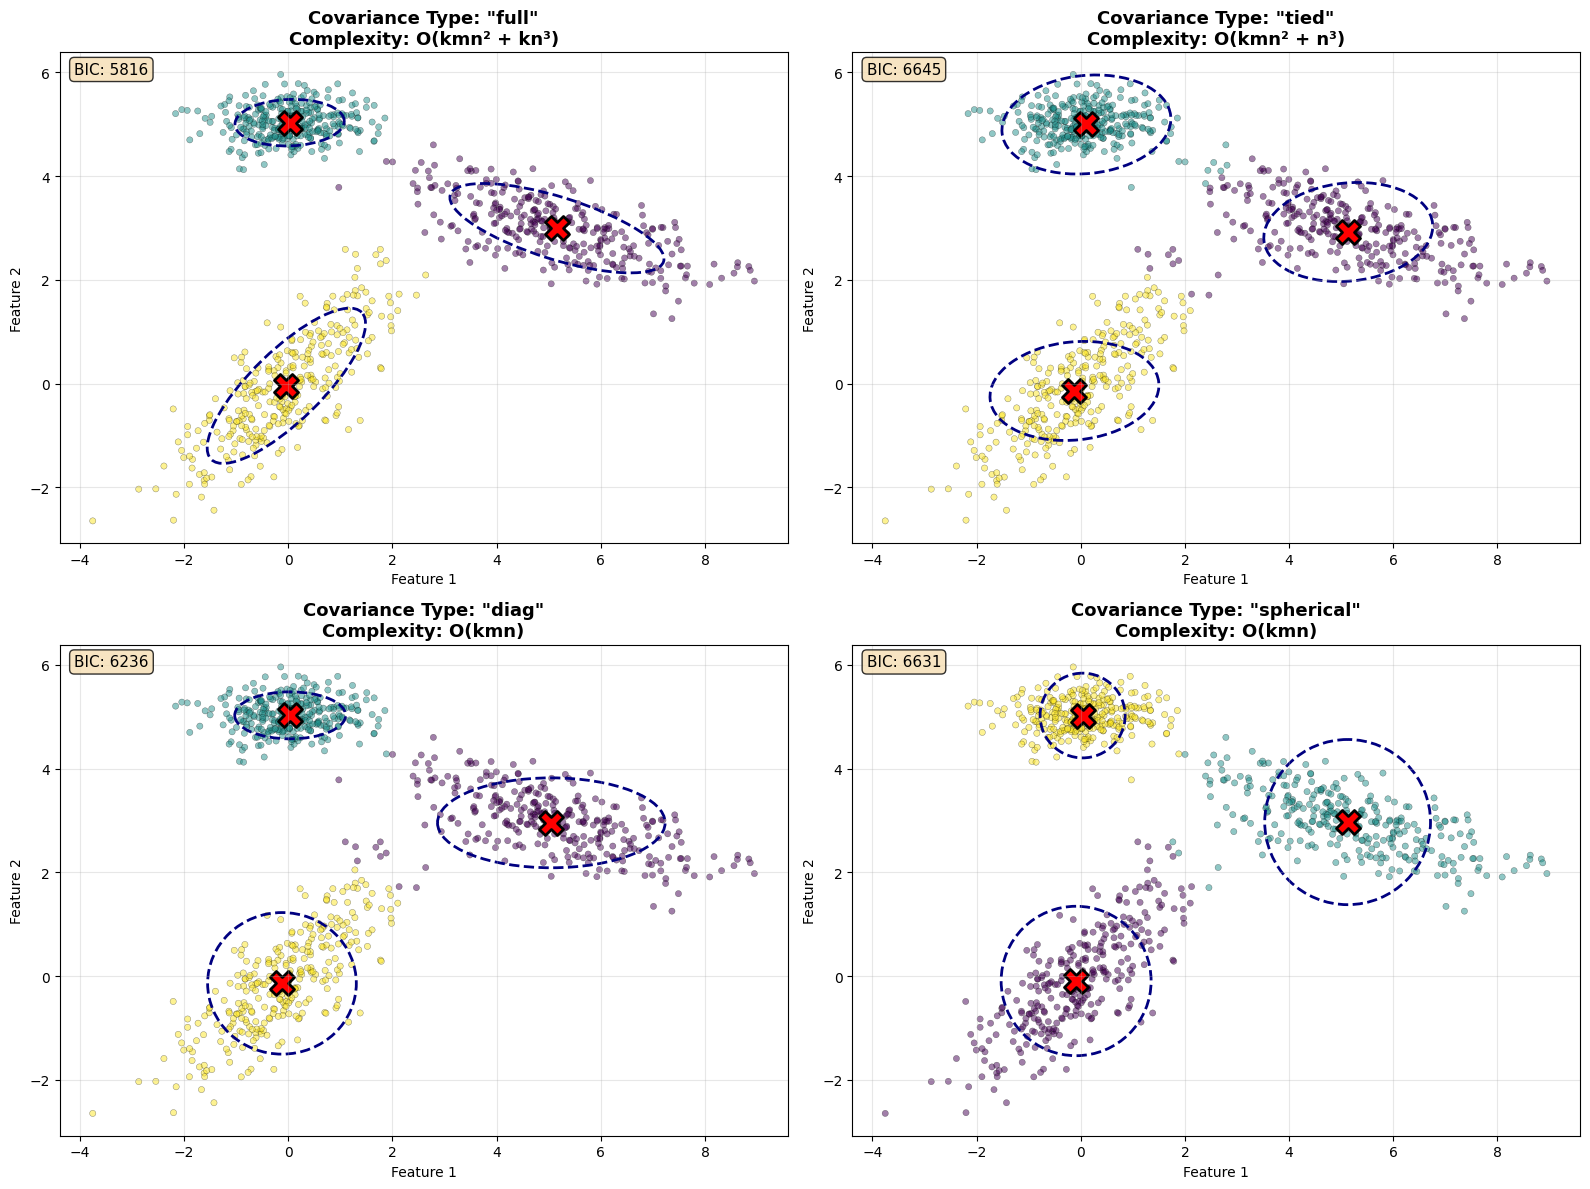


COVARIANCE TYPE COMPARISON:
Type         Flexibility          Speed           Best For
----------------------------------------------------------------------
full         Highest              Slowest         Complex shapes
tied         High                 Moderate        Similar shapes
diag         Moderate             Fast            Axis-aligned
spherical    Lowest               Fastest         Round clusters


In [55]:
# Demonstrate different covariance types
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
covariance_types = ['full', 'tied', 'diag', 'spherical']

for idx, cov_type in enumerate(covariance_types):
    ax = axes[idx // 2, idx % 2]
    
    # Fit GMM with specified covariance type
    gm_cov = GaussianMixture(n_components=3, covariance_type=cov_type, n_init=10, random_state=42)
    gm_cov.fit(X_gmm)
    y_pred_cov = gm_cov.predict(X_gmm)
    
    # Plot data points
    ax.scatter(X_gmm[:, 0], X_gmm[:, 1], c=y_pred_cov, cmap='viridis',
              s=20, alpha=0.5, edgecolors='k', linewidth=0.3)
    
    # Plot cluster centers
    ax.scatter(gm_cov.means_[:, 0], gm_cov.means_[:, 1], marker='X', s=300,
              c='red', edgecolors='black', linewidths=2)
    
    # Draw ellipses for each cluster
    from matplotlib.patches import Ellipse
    
    for i in range(gm_cov.n_components):
        if cov_type == 'tied':
            # All clusters share the same covariance
            covariances = gm_cov.covariances_
        elif cov_type == 'diag':
            # Diagonal covariance matrix
            covariances = np.diag(gm_cov.covariances_[i])
        elif cov_type == 'spherical':
            # Spherical covariance (scalar times identity)
            covariances = np.eye(2) * gm_cov.covariances_[i]
        else:  # full
            covariances = gm_cov.covariances_[i]
        
        # Compute eigenvalues and eigenvectors
        v, w = np.linalg.eigh(covariances)
        v = 2.0 * np.sqrt(2.0) * np.sqrt(v)  # 2 standard deviations
        u = w[0] / np.linalg.norm(w[0])
        
        # Compute angle
        angle = np.arctan(u[1] / u[0])
        angle = 180.0 * angle / np.pi
        
        # Draw ellipse
        ell = Ellipse(gm_cov.means_[i], v[0], v[1], angle=180.0 + angle,
                     edgecolor='navy', facecolor='none', linewidth=2, linestyle='--')
        ax.add_patch(ell)
    
    # Calculate complexity notation
    if cov_type == 'full':
        complexity = "O(kmn² + kn³)"
    elif cov_type == 'tied':
        complexity = "O(kmn² + n³)"
    else:  # diag or spherical
        complexity = "O(kmn)"
    
    ax.set_title(f'Covariance Type: "{cov_type}"\nComplexity: {complexity}',
                fontsize=13, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.3)
    
    # Add BIC score
    bic_score = gm_cov.bic(X_gmm)
    ax.text(0.02, 0.98, f'BIC: {bic_score:.0f}',
           transform=ax.transAxes, fontsize=11, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("COVARIANCE TYPE COMPARISON:")
print("="*70)
print(f"{'Type':<12} {'Flexibility':<20} {'Speed':<15} {'Best For'}")
print("-"*70)
print(f"{'full':<12} {'Highest':<20} {'Slowest':<15} Complex shapes")
print(f"{'tied':<12} {'High':<20} {'Moderate':<15} Similar shapes")
print(f"{'diag':<12} {'Moderate':<20} {'Fast':<15} Axis-aligned")
print(f"{'spherical':<12} {'Lowest':<20} {'Fastest':<15} Round clusters")

### How Bayesian GMM Works: Variational Inference

Bayesian GMM uses **Variational Bayesian Inference** to find the cluster parameters. Here's the intuition:

**Goal**: Find the posterior distribution p(θ|X) that tells us the probability of cluster parameters θ given data X.

**Challenge**: Using Bayes' theorem directly is intractable:
```
p(θ|X) = p(X|θ) × p(θ) / p(X)
```
The problem is computing p(X) = ∫ p(X|θ) × p(θ) dθ, which involves integration over all possible parameters.

**Solution - Variational Inference**:
1. Instead of computing p(θ|X) exactly, approximate it with a simpler distribution q(θ)
2. Find q(θ) that is closest to the true posterior p(θ|X)
3. "Closest" means minimizing the **KL divergence**: KL(q||p)

**In Practice**:
- Maximize the **Evidence Lower Bound (ELBO)**
- This is equivalent to minimizing KL divergence
- The algorithm iteratively updates cluster parameters and weights
- Unnecessary clusters automatically get weight → 0

**Key Parameters**:
- `weight_concentration_prior`: Controls how likely the model is to use fewer clusters
  - Higher values → more clusters will be active
  - Lower values → stronger preference for fewer clusters
  - Default is `1.0 / n_components`

### Limitations of GMM

Just like K-Means, Gaussian Mixture Models also struggle with certain data shapes, particularly **non-ellipsoidal clusters**.

**Key Limitations**:
1. **Assumes ellipsoidal shapes**: GMM models clusters as multivariate Gaussian distributions (ellipsoids)
2. **Struggles with irregular shapes**: Cannot model crescent shapes, spirals, or arbitrary complex boundaries
3. **Sensitive to initialization**: Can converge to local optima (though less prone than K-Means)
4. **Computational cost**: More expensive than K-Means, especially with "full" covariance type

Let's see GMM fail on the **moons dataset** (like K-Means did):

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23772\56980436.py:56: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


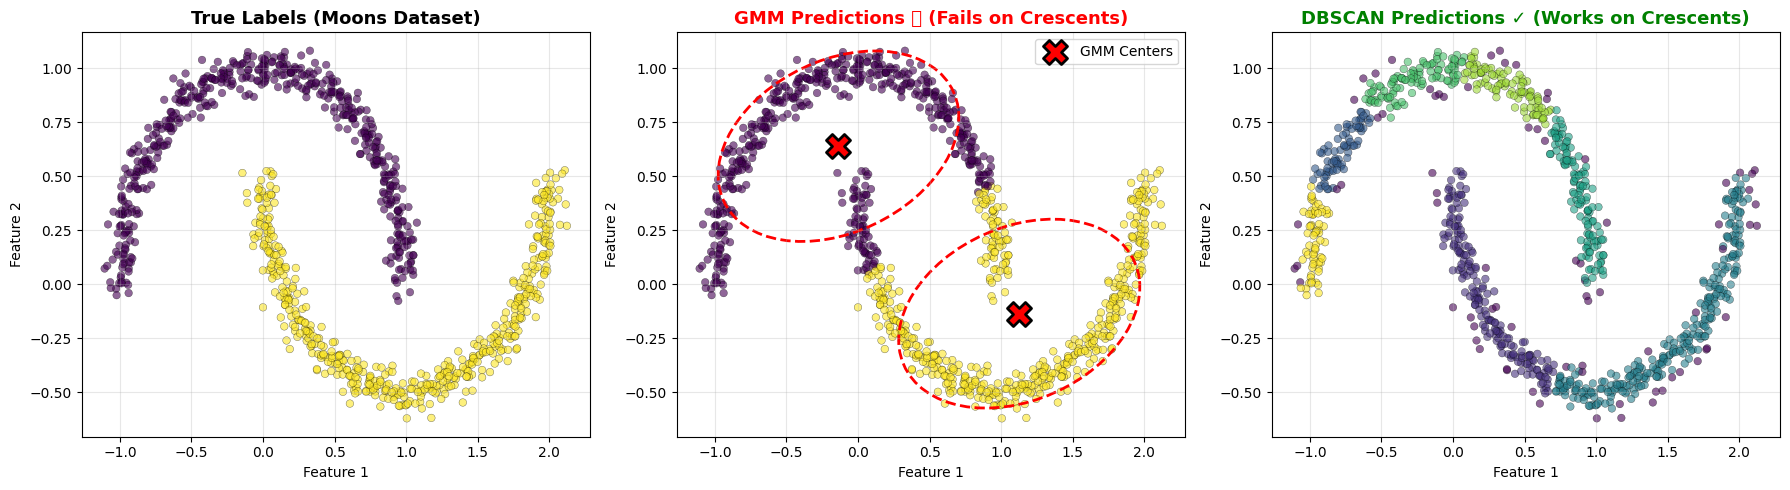


WHY GMM FAILS:
• GMM assumes clusters are ellipsoidal (Gaussian distributions)
• Crescent/moon shapes cannot be represented as ellipsoids
• GMM tries to fit ellipses, resulting in poor boundaries

✓ Use DBSCAN for irregular, non-ellipsoidal cluster shapes!
✓ Use GMM/K-Means for convex, ellipsoidal clusters


In [56]:
# GMM on moons dataset (will fail like K-Means)
X_moons_gmm, y_moons_gmm = make_moons(n_samples=1000, noise=0.05, random_state=42)

# Try GMM with 2 components
gm_moons = GaussianMixture(n_components=2, n_init=10, random_state=42)
y_pred_gmm_moons = gm_moons.fit_predict(X_moons_gmm)

# Compare with DBSCAN (from earlier)
dbscan_moons = DBSCAN(eps=0.05, min_samples=5)
y_pred_dbscan_moons = dbscan_moons.fit_predict(X_moons_gmm)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# True labels
axes[0].scatter(X_moons_gmm[:, 0], X_moons_gmm[:, 1], c=y_moons_gmm, 
               cmap='viridis', s=30, alpha=0.6, edgecolors='k', linewidth=0.3)
axes[0].set_title('True Labels (Moons Dataset)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].grid(True, alpha=0.3)

# GMM predictions (fails)
axes[1].scatter(X_moons_gmm[:, 0], X_moons_gmm[:, 1], c=y_pred_gmm_moons,
               cmap='viridis', s=30, alpha=0.6, edgecolors='k', linewidth=0.3)
axes[1].scatter(gm_moons.means_[:, 0], gm_moons.means_[:, 1], marker='X',
               s=300, c='red', edgecolors='black', linewidths=2, label='GMM Centers')

# Draw GMM ellipses
for i in range(gm_moons.n_components):
    covariances = gm_moons.covariances_[i]
    v, w = np.linalg.eigh(covariances)
    v = 2.0 * np.sqrt(2.0) * np.sqrt(v)
    u = w[0] / np.linalg.norm(w[0])
    angle = np.arctan(u[1] / u[0])
    angle = 180.0 * angle / np.pi
    
    ell = Ellipse(gm_moons.means_[i], v[0], v[1], angle=180.0 + angle,
                 edgecolor='red', facecolor='none', linewidth=2, linestyle='--')
    axes[1].add_patch(ell)

axes[1].set_title('GMM Predictions ❌ (Fails on Crescents)', fontsize=13, fontweight='bold', color='red')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# DBSCAN predictions (succeeds)
axes[2].scatter(X_moons_gmm[:, 0], X_moons_gmm[:, 1], c=y_pred_dbscan_moons,
               cmap='viridis', s=30, alpha=0.6, edgecolors='k', linewidth=0.3)
axes[2].set_title('DBSCAN Predictions ✓ (Works on Crescents)', fontsize=13, fontweight='bold', color='green')
axes[2].set_xlabel('Feature 1')
axes[2].set_ylabel('Feature 2')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("WHY GMM FAILS:")
print("="*70)
print("• GMM assumes clusters are ellipsoidal (Gaussian distributions)")
print("• Crescent/moon shapes cannot be represented as ellipsoids")
print("• GMM tries to fit ellipses, resulting in poor boundaries")
print("\n✓ Use DBSCAN for irregular, non-ellipsoidal cluster shapes!")
print("✓ Use GMM/K-Means for convex, ellipsoidal clusters")

---

## Other Clustering Algorithms

While we've covered the main clustering algorithms in detail, scikit-learn provides many other algorithms for various tasks:

### Dimensionality Reduction
- **PCA (Principal Component Analysis)**: Projects data onto lower dimensions while preserving variance
- **t-SNE**: Nonlinear dimensionality reduction for visualization
- **UMAP**: Faster alternative to t-SNE with better global structure preservation

### Anomaly Detection
- **Fast-MCD (Fast Minimum Covariance Determinant)**: Robust covariance estimation for outlier detection
- **Isolation Forest**: Tree-based anomaly detection by isolating outliers
- **LOF (Local Outlier Factor)**: Identifies anomalies based on local density deviation
- **One-Class SVM**: Learns decision boundary around normal data

### Hierarchical Clustering
- **Agglomerative Clustering**: Bottom-up approach, starts with individual points and merges
- **Divisive Clustering**: Top-down approach, starts with all points and splits

### Other Methods
- **Mean Shift**: Finds clusters by shifting points toward mode of density
- **Spectral Clustering**: Uses graph theory and eigenvalues for complex shapes
- **Affinity Propagation**: Automatically determines number of clusters via message passing

Each algorithm has its strengths and is suited for different types of data and problem requirements!

---

# 📚 Chapter 9 Summary: Unsupervised Learning

## Algorithms Covered in Detail

### 1. **K-Means Clustering**
- **Type**: Hard clustering (assigns each point to exactly one cluster)
- **Method**: Iteratively updates centroids by minimizing inertia (within-cluster sum of squares)
- **Best for**: Large datasets, spherical/convex clusters, when k is known
- **Limitations**: Requires specifying k, struggles with irregular shapes, sensitive to initialization
- **Key Techniques**:
  - K-Means++ initialization for better convergence
  - Elbow method & Silhouette score for finding optimal k
  - Mini-Batch K-Means for large datasets (3-4x faster)

### 2. **DBSCAN (Density-Based Spatial Clustering)**
- **Type**: Density-based clustering
- **Method**: Groups points in high-density regions, identifies outliers as noise
- **Best for**: Irregular/non-convex clusters, automatic outlier detection, unknown number of clusters
- **Limitations**: Sensitive to eps and min_samples parameters, struggles with varying densities
- **Key Concepts**:
  - Core instances, border instances, anomalies
  - No need to specify number of clusters
  - Can identify noise points (label = -1)

### 3. **Gaussian Mixture Models (GMM)**
- **Type**: Soft clustering (assigns probabilities to each cluster)
- **Method**: Models clusters as multivariate Gaussian distributions
- **Best for**: Ellipsoidal clusters, when cluster probabilities are needed, density estimation, anomaly detection
- **Limitations**: Assumes ellipsoidal shapes, computationally expensive, requires specifying k
- **Key Features**:
  - `predict_proba()` for soft clustering
  - `sample()` for generating synthetic data
  - `score_samples()` for density estimation and anomaly detection
  - BIC/AIC for model selection

### 4. **Bayesian Gaussian Mixture**
- **Type**: Probabilistic soft clustering with automatic component selection
- **Method**: Uses variational inference to automatically eliminate unnecessary clusters
- **Best for**: When number of clusters is uncertain, automatic model selection
- **Key Advantage**: Start with large n_components, unused clusters get weight → 0
- **Parameters**: `weight_concentration_prior` controls preference for fewer clusters

## Key Takeaways

### When to Use Each Algorithm:

| **Algorithm** | **Best Use Case** |
|--------------|-------------------|
| **K-Means** | Fast, large datasets, spherical clusters, k known |
| **Mini-Batch K-Means** | Very large datasets where speed is critical |
| **DBSCAN** | Irregular shapes, unknown k, automatic outlier detection |
| **GMM** | Need probabilities, ellipsoidal clusters, density estimation |
| **Bayesian GMM** | Automatic component selection, uncertain k |

### Important Concepts:

1. **Hard vs Soft Clustering**:
   - Hard: Each point belongs to exactly one cluster (K-Means, DBSCAN)
   - Soft: Each point has probability for each cluster (GMM)

2. **Cluster Validation**:
   - Inertia (lower is better, but watch for overfitting)
   - Silhouette Score (higher is better, range -1 to 1)
   - Elbow method for visual inspection
   - BIC/AIC for GMM model selection

3. **Initialization Matters**:
   - K-Means++: Smart initialization for K-Means
   - Multiple runs with `n_init` parameter
   - Different random seeds can give different results

4. **Feature Scaling is Critical**:
   - All distance-based algorithms require scaling
   - Use StandardScaler or MinMaxScaler before clustering

5. **Applications**:
   - Data exploration and visualization
   - Customer segmentation
   - Image segmentation and compression
   - Semi-supervised learning (labeling)
   - Anomaly detection
   - Dimensionality reduction preprocessing
   - Feature engineering

### Advanced Topics:

- **Semi-supervised Learning**: Using small labeled set + large unlabeled set
- **Active Learning**: Iteratively labeling most uncertain instances
- **Covariance Types**: Trade-off between flexibility and computational cost
- **Variational Inference**: Bayesian approach to parameter estimation

## 🎯 Final Recommendations:

1. **Always scale your features** before clustering
2. **Try multiple algorithms** - different algorithms work better for different data shapes
3. **Validate your clusters** using multiple metrics
4. **Visualize** when possible (2D/3D projections using PCA or t-SNE)
5. **Consider the domain** - sometimes domain knowledge is better than metrics for choosing k
6. **Don't over-rely on unsupervised metrics** - they don't always align with business goals

---

**Congratulations!** You've completed Chapter 9 on Unsupervised Learning. You now understand the main clustering algorithms, their strengths and limitations, and how to apply them to real-world problems! 🎉

## Quick Reference: Code Examples

Here's a quick reference of all the main algorithms covered with basic usage patterns:

In [57]:
# ============================================================================
# QUICK REFERENCE: UNSUPERVISED LEARNING ALGORITHMS
# ============================================================================

from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler

# Always scale your features first!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("="*80)
print("1. K-MEANS CLUSTERING")
print("="*80)
# Basic usage
kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_scaled)
print(f"K-Means labels: {labels[:10]}...")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"Centroids shape: {kmeans.cluster_centers_.shape}")

print("\n" + "="*80)
print("2. MINI-BATCH K-MEANS (for large datasets)")
print("="*80)
mb_kmeans = MiniBatchKMeans(n_clusters=5, batch_size=100, random_state=42)
labels_mb = mb_kmeans.fit_predict(X_scaled)
print(f"Mini-Batch K-Means labels: {labels_mb[:10]}...")
print(f"Inertia: {mb_kmeans.inertia_:.2f}")

print("\n" + "="*80)
print("3. DBSCAN")
print("="*80)
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)
print(f"DBSCAN labels: {labels_dbscan[:10]}...")
print(f"Number of clusters: {len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)}")
print(f"Number of noise points: {list(labels_dbscan).count(-1)}")
print(f"Core samples: {len(dbscan.core_sample_indices_)}")

print("\n" + "="*80)
print("4. GAUSSIAN MIXTURE MODEL")
print("="*80)
gm = GaussianMixture(n_components=5, n_init=10, random_state=42)
gm.fit(X_scaled)
labels_gm = gm.predict(X_scaled)
probas = gm.predict_proba(X_scaled)
print(f"GMM labels: {labels_gm[:10]}...")
print(f"Cluster probabilities (first sample): {probas[0]}")
print(f"BIC: {gm.bic(X_scaled):.2f}")
print(f"AIC: {gm.aic(X_scaled):.2f}")

# Anomaly detection
densities = gm.score_samples(X_scaled)
threshold = np.percentile(densities, 4)
anomalies = X_scaled[densities < threshold]
print(f"Number of anomalies detected: {len(anomalies)}")

print("\n" + "="*80)
print("5. BAYESIAN GAUSSIAN MIXTURE")
print("="*80)
bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X_scaled)
labels_bgm = bgm.predict(X_scaled)
active_components = np.sum(bgm.weights_ > 0.01)
print(f"Bayesian GMM labels: {labels_bgm[:10]}...")
print(f"Started with 10 components, using: {active_components}")
print(f"Component weights: {bgm.weights_.round(3)}")

print("\n" + "="*80)
print("KEY METRICS SUMMARY")
print("="*80)
print(f"{'Algorithm':<25} {'Metric':<20} {'Value'}")
print("-"*80)
print(f"{'K-Means':<25} {'Inertia':<20} {kmeans.inertia_:.2f}")
print(f"{'Mini-Batch K-Means':<25} {'Inertia':<20} {mb_kmeans.inertia_:.2f}")
print(f"{'DBSCAN':<25} {'Clusters':<20} {len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)}")
print(f"{'GMM':<25} {'BIC':<20} {gm.bic(X_scaled):.2f}")
print(f"{'Bayesian GMM':<25} {'Active Components':<20} {active_components}")

print("\n" + "="*80)
print("✅ All algorithms demonstrated successfully!")
print("="*80)

1. K-MEANS CLUSTERING
K-Means labels: [2 2 0 2 4 0 3 4 2 4]...
Inertia: 24.39
Centroids shape: (5, 2)

2. MINI-BATCH K-MEANS (for large datasets)
Mini-Batch K-Means labels: [0 0 2 0 4 2 1 4 0 4]...
Inertia: 24.48

3. DBSCAN
DBSCAN labels: [0 0 1 0 0 1 2 0 0 0]...
Number of clusters: 3
Number of noise points: 0
Core samples: 1000

4. GAUSSIAN MIXTURE MODEL
GMM labels: [2 2 0 2 4 0 3 4 2 4]...
Cluster probabilities (first sample): [1.38807812e-152 8.04447968e-064 9.99999985e-001 7.62360905e-151
 1.51823714e-008]
BIC: 267.43
AIC: 125.11
Number of anomalies detected: 40

5. BAYESIAN GAUSSIAN MIXTURE
GMM labels: [2 2 0 2 4 0 3 4 2 4]...
Cluster probabilities (first sample): [1.38807812e-152 8.04447968e-064 9.99999985e-001 7.62360905e-151
 1.51823714e-008]
BIC: 267.43
AIC: 125.11
Number of anomalies detected: 40

5. BAYESIAN GAUSSIAN MIXTURE
Bayesian GMM labels: [2 2 1 2 4 1 3 4 2 4]...
Started with 10 components, using: 5
Component weights: [0.201 0.201 0.202 0.2   0.197 0.    0.    0.    0